# M11.6 — Controlled training-domain comparison

M11.1–M11.5 progressively investigated the synthetic-to-real domain gap while keeping the M10 predictor frozen.

The main conclusions were:

- extending the physical GW into the processing context is required for the M11 signal model;
- absolute geocentric GPS time affects detector-level geometry and must be consistent with real strain;
- optimal SNR remains the correct signal-strength control variable;
- replacing the analytical PSD by an empirical PSD changes the detector sensitivity substantially but produces only a moderate predictor-domain shift when the noise remains Gaussian;
- actual off-source detector strain produces a much larger latent and prediction shift than PSD-matched Gaussian noise;
- persistent narrow-band components explain much of the anomalous L1/V1 processed-noise power, but removing those components does not eliminate the learned G1-to-R domain gap.

The resulting hypothesis is that

$$
S_n(f)
$$

alone is not sufficient to specify the training-noise distribution required for robust real-data inference.

M11.6 tests this hypothesis directly by training otherwise identical predictors in three noise domains:

$$
G0 =
\text{Gaussian noise generated from the analytical M10 PSD},
$$

$$
G1 =
\text{Gaussian noise generated from empirical detector PSDs},
$$

and

$$
R =
\text{actual real off-source detector strain}.
$$

The goal is not yet to optimize the final M11 model.

The goal is to determine whether explicitly representing the real detector-noise distribution during training reduces the synthetic-to-real domain gap.

## Scientific hypotheses

### H1 — G0 versus G1

At matched source population and optimal SNR, replacing the analytical PSD by empirical PSDs may alter in-domain performance modestly, but should not by itself reproduce the behavior of actual detector strain.

### H2 — Synthetic-to-real generalization

Predictors trained only in Gaussian domains,

$$
G0 \quad\text{or}\quad G1,
$$

are expected to degrade when evaluated on

$$
R.
$$

If G1 substantially outperforms G0 on R, empirical PSD variation explains an important fraction of the domain gap.

If G0 and G1 perform similarly poorly on R, the dominant mismatch lies beyond the PSD.

### H3 — Real-noise training

A predictor trained on

$$
h_{\rm sim}+n_{\rm real}
$$

should substantially improve performance on held-out real-noise epochs if the M11.5 domain gap is primarily caused by the training-noise distribution.

### H4 — Cost of robustness

Any improvement on R must be evaluated together with performance on G0 and G1.

A real-noise-trained model that performs well on R but catastrophically forgets Gaussian domains would represent domain specialization rather than general robustness.

## Experimental matrix

Three models will be trained with exactly the same architecture and optimization protocol.

| model | training domain |
|---|---|
| M11-G0 | analytical-PSD Gaussian noise |
| M11-G1 | empirical-PSD Gaussian noise |
| M11-R | real off-source detector strain |

Each trained model will then be evaluated on all three held-out test domains.

This produces the cross-domain matrix

$$
\begin{array}{c|ccc}
 & G0_{\rm test} & G1_{\rm test} & R_{\rm test}\\
\hline
G0_{\rm train} & \checkmark & \checkmark & \checkmark\\
G1_{\rm train} & \checkmark & \checkmark & \checkmark\\
R_{\rm train}  & \checkmark & \checkmark & \checkmark
\end{array}
$$

The diagonal measures in-domain performance.

The off-diagonal elements quantify generalization across noise domains.

## Controlled variables

The following quantities are held fixed across G0, G1 and R:

- BBH source population;
- waveform approximant;
- sampling frequency;
- final 4 s model input;
- H1/L1/V1 detector network;
- M11.1 full-projection signal context;
- label definitions;
- optimal-SNR target distribution;
- CNN architecture;
- loss function;
- optimizer and learning-rate policy;
- batch size;
- train/validation/calibration/test sizes;
- label standardization;
- M10 input-normalization policy for this experiment;
- model initialization seed whenever possible.

The intended causal variable is

$$
\boxed{\text{training noise domain}.}
$$

No architecture or normalization search is performed in M11.6.

## Paired astrophysical population

The astrophysical source population is generated once.

For source index $i$, the same intrinsic and extrinsic source parameters

$$
\theta_i
$$

are reused in G0, G1 and R.

Therefore

$$
\theta_i^{G0}
=
\theta_i^{G1}
=
\theta_i^{R}.
$$

The same split assignment is also preserved:

$$
s_i
\in
\{
\mathrm{train},
\mathrm{validation},
\mathrm{calibration},
\mathrm{test}
\}.
$$

This prevents source-population fluctuations from being confused with noise-domain effects.

## Epoch matching across domains

Each source is assigned a physical GPS epoch from the real-noise bank.

That epoch is used for detector projection in all three domains:

$$
t_{{\rm geo},i}^{G0}
=
t_{{\rm geo},i}^{G1}
=
t_{{\rm geo},i}^{R}.
$$

Only the noise realization/domain changes.

This controls detector antenna responses and inter-detector delays across the three datasets.

## Optimal-SNR matching

A target network optimal SNR is sampled once per source,

$$
\rho_i^\star
\sim
U(10,25).
$$

The same target is used in all domains:

$$
\rho_{i,G0}^{\rm opt}
\simeq
\rho_{i,G1}^{\rm opt}
\simeq
\rho_{i,R}^{\rm opt}
\simeq
\rho_i^\star.
$$

The luminosity distance may therefore differ between domains because each noise model has a different PSD.

This is intentional.

M11.6 controls observable signal strength rather than requiring the three examples to correspond to the same physical luminosity distance.

# M11.6-B — Multi-epoch real off-source noise bank

The real-noise training domain must contain detector strain from multiple, temporally distinct observing epochs.

GWOSC compact-binary events are used only as convenient anchors for locating long calibrated H1/L1/V1 strain files.

The astrophysical events themselves are **not** used as training noise.

A valid real-noise block must satisfy:

- simultaneous H1/L1/V1 strain availability;
- finite strain in all required detectors;
- no catalogued GW event inside or close to the block;
- no overlap between blocks assigned to different dataset splits;
- sufficient temporal extent for PSD estimation and extraction of multiple processing-context noise crops.

The construction order is deliberately leakage safe:

$$
\text{GWOSC strain files}
\rightarrow
\text{candidate real-noise blocks}
\rightarrow
\text{GW exclusion}
\rightarrow
\text{block-level split}
\rightarrow
\text{noise crops}
\rightarrow
\text{synthetic GW injection}.
$$

The split is therefore defined at the level of the underlying real detector-noise environment, not after individual injections have been generated.

In [1]:
REAL_BLOCK_SPLIT_FRACTIONS = {
    "train": 0.70,
    "val": 0.10,
    "cal": 0.10,
    "test": 0.10,
}

In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp, wasserstein_distance

from pycbc.types import TimeSeries, FrequencySeries

PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

/afs/ciemat.es/user/v/vserrano/miniconda3/envs/gw-env/lib/python3.10/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd

from src.real_data.catalog import (
    fetch_gwosc_catalog_events,
    gwosc_events_to_parameter_df,
    has_required_detectors,
    build_gwosc_urls_for_events,
)

from src.real_data.gwosc_utils import (
    download_if_needed,
    read_gwosc_hdf5_as_pycbc_timeseries,
    get_timeseries_bounds,
    time_slice_is_finite,
)

In [4]:
M116_CATALOG = "GWTC-3-confident"

M116_DETECTORS = (
    "H1",
    "L1",
    "V1",
)

M116_SAMPLE_RATE = 4096

# Underlying real-noise environment.
M116_BLOCK_DURATION_S = 256.0

# Conservative exclusion around every catalogued GW.
# Much larger than the 4.8 s processing context.
M116_GW_EXCLUSION_HALF_WIDTH_S = 32.0

# Prevent candidate blocks from touching the edge of a 4096 s file.
M116_FILE_EDGE_MARGIN_S = 32.0

# Initial target only. We do not force this number if QC leaves fewer.
M116_TARGET_UNIQUE_BLOCKS = 24

print(
    "Block duration:",
    M116_BLOCK_DURATION_S,
    "s"
)

print(
    "GW exclusion:",
    "+/-",
    M116_GW_EXCLUSION_HALF_WIDTH_S,
    "s"
)

Block duration: 256.0 s
GW exclusion: +/- 32.0 s


## 1. GWOSC event catalogue

We first load the event catalogue before selecting noise anchors.

The complete event-time list is needed for two different purposes:

1. identify epochs for which H1/L1/V1 long strain files can be resolved;
2. construct a global exclusion list of catalogued GW times.

The second point is essential.

A candidate noise block is rejected if **any** catalogue event lies within the block plus a conservative exclusion margin, even if that event is not the event used to locate the corresponding GWOSC strain file.

In [5]:
events_raw_M116 = (
    fetch_gwosc_catalog_events(
        catalog=M116_CATALOG,
        include_default_parameters=True,
    )
)

events_df_M116 = (
    gwosc_events_to_parameter_df(
        events_raw_M116,
        catalog_name=M116_CATALOG,
    )
)

print(
    "Catalogue events:",
    len(events_df_M116)
)

display(
    events_df_M116[
        [
            "event",
            "gps_time",
            "detectors",
        ]
    ]
    .sort_values("gps_time")
    .head(10)
)

Catalogue events: 35


,event,gps_time,detectors
34,GW191103_012549,1.256780e+09,"H1,L1,V1"
33,GW191105_143521,1.257000e+09,"H1,L1,V1"
32,GW191109_010717,1.257297e+09,"H1,L1,V1"
31,GW191113_071753,1.257665e+09,"H1,L1,V1"
30,GW191126_115259,1.258804e+09,"H1,L1"
29,GW191127_050227,1.258866e+09,"H1,L1,V1"
28,GW191129_134029,1.259070e+09,"H1,L1,V1"
27,GW191204_110529,1.259493e+09,"H1,L1,V1"
26,GW191204_171526,1.259515e+09,"H1,L1"
25,GW191215_223052,1.260484e+09,"H1,L1,V1"


In [6]:
assert len(events_df_M116) > 0

assert events_df_M116[
    "gps_time"
].notna().all()

assert events_df_M116[
    "event"
].notna().all()

catalog_gps_M116 = np.sort(
    events_df_M116[
        "gps_time"
    ]
    .astype(float)
    .to_numpy()
)

print(
    "GPS range:",
    catalog_gps_M116.min(),
    "->",
    catalog_gps_M116.max(),
)

GPS range: 1256779567.5 -> 1268903511.3


In [7]:
anchors_df_M116 = (
    events_df_M116[
        events_df_M116[
            "detectors"
        ].apply(
            lambda x:
                has_required_detectors(
                    x,
                    required=M116_DETECTORS,
                )
        )
    ]
    .copy()
    .sort_values("gps_time")
    .reset_index(drop=True)
)

print(
    "HLV candidate anchors:",
    len(anchors_df_M116)
)

display(
    anchors_df_M116[
        [
            "event",
            "gps_time",
            "detectors",
        ]
    ]
)

HLV candidate anchors: 30


,event,gps_time,detectors
0,GW191103_012549,1.256780e+09,"H1,L1,V1"
1,GW191105_143521,1.257000e+09,"H1,L1,V1"
2,GW191109_010717,1.257297e+09,"H1,L1,V1"
3,GW191113_071753,1.257665e+09,"H1,L1,V1"
4,GW191127_050227,1.258866e+09,"H1,L1,V1"
5,GW191129_134029,1.259070e+09,"H1,L1,V1"
6,GW191204_110529,1.259493e+09,"H1,L1,V1"
7,GW191215_223052,1.260484e+09,"H1,L1,V1"
8,GW191219_163120,1.260808e+09,"H1,L1,V1"
9,GW191222_033537,1.261021e+09,"H1,L1,V1"


In [8]:
urls_by_anchor_M116, failed_urls_M116 = (
    build_gwosc_urls_for_events(
        anchors_df_M116,
        catalog=M116_CATALOG,
        sample_rate=M116_SAMPLE_RATE,
    )
)

print(
    "Anchors with resolved strain:",
    len(urls_by_anchor_M116)
)

print(
    "Failed URL resolutions:",
    len(failed_urls_M116)
)

if len(failed_urls_M116) > 0:
    display(
        failed_urls_M116
    )

Anchors with resolved strain: 30
Failed URL resolutions: 0


In [9]:
rows = []

for event_name, urls in (
    urls_by_anchor_M116.items()
):

    rows.append({
        "event":
            event_name,

        "has_H1":
            "H1" in urls,

        "has_L1":
            "L1" in urls,

        "has_V1":
            "V1" in urls,

        "n_urls":
            len(urls),
    })

df_anchor_url_contract_M116 = (
    pd.DataFrame(rows)
)

display(
    df_anchor_url_contract_M116
)

assert (
    df_anchor_url_contract_M116[
        [
            "has_H1",
            "has_L1",
            "has_V1",
        ]
    ]
    .all()
    .all()
)

,event,has_H1,has_L1,has_V1,n_urls
0,GW191103_012549,True,True,True,3
1,GW191105_143521,True,True,True,3
2,GW191109_010717,True,True,True,3
3,GW191113_071753,True,True,True,3
4,GW191127_050227,True,True,True,3
5,GW191129_134029,True,True,True,3
6,GW191204_110529,True,True,True,3
7,GW191215_223052,True,True,True,3
8,GW191219_163120,True,True,True,3
9,GW191222_033537,True,True,True,3


## 2. Deduplicate physical strain files

Different catalogue events can in principle resolve to the same long GWOSC strain file.

Such events do not represent independent detector-noise environments.

We therefore define a physical strain-file group by the tuple

$$
(
{\rm H1\ URL},
{\rm L1\ URL},
{\rm V1\ URL}
)
$$

and retain only one representative anchor for each unique group.

In [10]:
anchor_time_lookup_M116 = (
    anchors_df_M116
    .set_index("event")[
        "gps_time"
    ]
    .astype(float)
    .to_dict()
)

rows = []

for event_name, urls in (
    urls_by_anchor_M116.items()
):

    rows.append({
        "anchor_event":
            event_name,

        "anchor_gps":
            anchor_time_lookup_M116[
                event_name
            ],

        "H1_url":
            urls["H1"],

        "L1_url":
            urls["L1"],

        "V1_url":
            urls["V1"],
    })

df_anchor_files_M116 = (
    pd.DataFrame(rows)
    .sort_values("anchor_gps")
    .reset_index(drop=True)
)

df_anchor_files_M116[
    "file_group_key"
] = list(
    zip(
        df_anchor_files_M116[
            "H1_url"
        ],
        df_anchor_files_M116[
            "L1_url"
        ],
        df_anchor_files_M116[
            "V1_url"
        ],
    )
)

print(
    "Anchor events:",
    len(df_anchor_files_M116)
)

print(
    "Unique HLV file groups:",
    df_anchor_files_M116[
        "file_group_key"
    ].nunique()
)

Anchor events: 30
Unique HLV file groups: 30


In [11]:
df_unique_file_groups_M116 = (
    df_anchor_files_M116
    .drop_duplicates(
        subset="file_group_key",
        keep="first",
    )
    .reset_index(drop=True)
)

df_unique_file_groups_M116[
    "file_group_id"
] = np.arange(
    len(df_unique_file_groups_M116)
)

display(
    df_unique_file_groups_M116[
        [
            "file_group_id",
            "anchor_event",
            "anchor_gps",
        ]
    ]
)

,file_group_id,anchor_event,anchor_gps
0,0,GW191103_012549,1.256780e+09
1,1,GW191105_143521,1.257000e+09
2,2,GW191109_010717,1.257297e+09
3,3,GW191113_071753,1.257665e+09
4,4,GW191127_050227,1.258866e+09
5,5,GW191129_134029,1.259070e+09
6,6,GW191204_110529,1.259493e+09
7,7,GW191215_223052,1.260484e+09
8,8,GW191219_163120,1.260808e+09
9,9,GW191222_033537,1.261021e+09


In [12]:
#Excluimos intervalos con una GW proxima dado un margin_s

def catalog_events_near_interval(
    start,
    end,
    catalog_times,
    margin_s,
):
    start = float(start)
    end = float(end)
    margin_s = float(margin_s)

    times = np.asarray(
        catalog_times,
        dtype=float,
    )

    mask = (
        (times >= start - margin_s)
        & (times <= end + margin_s)
    )

    return times[mask]

In [13]:
example_event_gps = float(
    anchors_df_M116.iloc[0][
        "gps_time"
    ]
)

test_near = (
    catalog_events_near_interval(
        example_event_gps - 10,
        example_event_gps + 10,
        catalog_gps_M116,
        M116_GW_EXCLUSION_HALF_WIDTH_S,
    )
)

print(test_near)

assert len(test_near) >= 1

[1.25677957e+09]


Descargamos inicialmente un subconjunto

In [14]:
N_FILE_GROUPS_PILOT_M116 = min(
    8,
    len(df_unique_file_groups_M116),
)

pilot_file_groups_M116 = (
    df_unique_file_groups_M116
    .iloc[:N_FILE_GROUPS_PILOT_M116]
    .copy()
)

In [15]:
n_available = len(
    df_unique_file_groups_M116
)

N_FILE_GROUPS_PILOT_M116 = min(
    4,
    n_available,
)

pilot_indices = np.unique(
    np.round(
        np.linspace(
            0,
            n_available - 1,
            N_FILE_GROUPS_PILOT_M116,
        )
    ).astype(int)
)

pilot_file_groups_M116 = (
    df_unique_file_groups_M116
    .iloc[pilot_indices]
    .copy()
    .reset_index(drop=True)
)

display(
    pilot_file_groups_M116[
        [
            "file_group_id",
            "anchor_event",
            "anchor_gps",
        ]
    ]
)

,file_group_id,anchor_event,anchor_gps
0,0,GW191103_012549,1.256780e+09
1,10,GW191230_180458,1.261764e+09
2,19,GW200216_220804,1.265926e+09
3,29,GW200322_091133,1.268904e+09


In [16]:
import os
from pathlib import Path

DATA_ROOT_M116 = Path(
    os.environ.get(
        "CBC_PE_DATA_ROOT",
        "/data/vserrano/cbc_pe_data",
    )
).resolve()

GWOSC_CACHE_M116 = (
    DATA_ROOT_M116
    / "gwosc_cache"
    / "m11"
)

GWOSC_CACHE_M116.mkdir(
    parents=True,
    exist_ok=True,
)

print("DATA_ROOT:", DATA_ROOT_M116)
print("GWOSC cache:", GWOSC_CACHE_M116)

DATA_ROOT: /data/vserrano/cbc_pe_data
GWOSC cache: /data/vserrano/cbc_pe_data/gwosc_cache/m11


In [17]:
pilot_strains_M116 = {}

for _, row in (
    pilot_file_groups_M116
    .iterrows()
):

    group_id = int(
        row["file_group_id"]
    )

    print(
        "\nFile group:",
        group_id,
        "| anchor:",
        row["anchor_event"],
    )

    strains = {}

    for ifo in M116_DETECTORS:

        url = row[
            f"{ifo}_url"
        ]

        local_path = (
            download_if_needed(
                url=url,
                cache_dir=GWOSC_CACHE_M116,
            )
        )

        ts = (
            read_gwosc_hdf5_as_pycbc_timeseries(
                local_path
            )
        )

        strains[ifo] = ts

        print(
            ifo,
            "start=",
            float(ts.start_time),
            "end=",
            float(ts.end_time),
            "duration=",
            float(ts.end_time)
            - float(ts.start_time),
            "len=",
            len(ts),
        )

    pilot_strains_M116[
        group_id
    ] = strains


File group: 0 | anchor: GW191103_012549
Using cached file: H-H1_GWOSC_4KHZ_R1-1256777520-4096.hdf5
H1 start= 1256777520.0 end= 1256781616.0 duration= 4096.0 len= 16777216
Using cached file: L-L1_GWOSC_4KHZ_R1-1256777520-4096.hdf5
L1 start= 1256777520.0 end= 1256781616.0 duration= 4096.0 len= 16777216
Using cached file: V-V1_GWOSC_O3b_4KHZ_R1-1256775680-4096.hdf5
V1 start= 1256775680.0 end= 1256779776.0 duration= 4096.0 len= 16777216

File group: 10 | anchor: GW191230_180458
Using cached file: H-H1_GWOSC_4KHZ_R1-1261762269-4096.hdf5
H1 start= 1261762269.0 end= 1261766365.0 duration= 4096.0 len= 16777216
Using cached file: L-L1_GWOSC_4KHZ_R1-1261762269-4096.hdf5
L1 start= 1261762269.0 end= 1261766365.0 duration= 4096.0 len= 16777216
Using cached file: V-V1_GWOSC_4KHZ_R1-1261762269-4096.hdf5
V1 start= 1261762269.0 end= 1261766365.0 duration= 4096.0 len= 16777216

File group: 19 | anchor: GW200216_220804
Using cached file: H-H1_GWOSC_4KHZ_R1-1265924055-4096.hdf5
H1 start= 1265924055.0 end

In [18]:
def common_timeseries_interval(
    strains,
):
    start = max(
        float(
            strains[ifo].start_time
        )
        for ifo in M116_DETECTORS
    )

    end = min(
        float(
            strains[ifo].end_time
        )
        for ifo in M116_DETECTORS
    )

    if end <= start:
        raise ValueError(
            "No common H1/L1/V1 interval."
        )

    return start, end

In [19]:
rows = []

for group_id, strains in (
    pilot_strains_M116.items()
):

    common_start, common_end = (
        common_timeseries_interval(
            strains
        )
    )

    rows.append({
        "file_group_id":
            group_id,

        "common_start":
            common_start,

        "common_end":
            common_end,

        "common_duration":
            common_end
            - common_start,
    })

df_common_intervals_M116 = (
    pd.DataFrame(rows)
)

display(
    df_common_intervals_M116
)

,file_group_id,common_start,common_end,common_duration
0,0,1.256778e+09,1.256780e+09,2256.0
1,10,1.261762e+09,1.261766e+09,4096.0
2,19,1.265924e+09,1.265928e+09,4096.0
3,29,1.268901e+09,1.268906e+09,4096.0


In [20]:
def build_candidate_blocks_for_interval(
    *,
    file_group_id,
    start,
    end,
    block_duration_s,
    edge_margin_s,
    catalog_times,
    gw_exclusion_margin_s,
):
    usable_start = (
        float(start)
        + edge_margin_s
    )

    usable_end = (
        float(end)
        - edge_margin_s
    )

    rows = []

    block_index = 0
    t0 = usable_start

    while (
        t0 + block_duration_s
        <= usable_end
    ):
        t1 = (
            t0
            + block_duration_s
        )

        nearby_events = (
            catalog_events_near_interval(
                start=t0,
                end=t1,
                catalog_times=(
                    catalog_times
                ),
                margin_s=(
                    gw_exclusion_margin_s
                ),
            )
        )

        rows.append({
            "file_group_id":
                int(file_group_id),

            "block_index":
                block_index,

            "block_start":
                t0,

            "block_end":
                t1,

            "block_duration_s":
                block_duration_s,

            "n_nearby_catalog_events":
                len(
                    nearby_events
                ),

            "passes_gw_veto":
                (
                    len(
                        nearby_events
                    )
                    == 0
                ),
        })

        block_index += 1

        # Non-overlapping underlying blocks.
        t0 += block_duration_s

    return rows

In [21]:
candidate_rows_M116 = []

for _, row in (
    df_common_intervals_M116
    .iterrows()
):

    candidate_rows_M116.extend(
        build_candidate_blocks_for_interval(
            file_group_id=(
                row["file_group_id"]
            ),
            start=(
                row["common_start"]
            ),
            end=(
                row["common_end"]
            ),
            block_duration_s=(
                M116_BLOCK_DURATION_S
            ),
            edge_margin_s=(
                M116_FILE_EDGE_MARGIN_S
            ),
            catalog_times=(
                catalog_gps_M116
            ),
            gw_exclusion_margin_s=(
                M116_GW_EXCLUSION_HALF_WIDTH_S
            ),
        )
    )

df_candidate_blocks_M116 = (
    pd.DataFrame(
        candidate_rows_M116
    )
)

print(
    "Candidate blocks:",
    len(df_candidate_blocks_M116)
)

print(
    "Pass GW veto:",
    df_candidate_blocks_M116[
        "passes_gw_veto"
    ].sum()
)

print(
    "Rejected by GW veto:",
    (
        ~df_candidate_blocks_M116[
            "passes_gw_veto"
        ]
    ).sum()
)

Candidate blocks: 53
Pass GW veto: 49
Rejected by GW veto: 4


In [22]:
display(
    df_candidate_blocks_M116[
        ~df_candidate_blocks_M116[
            "passes_gw_veto"
        ]
    ]
    .sort_values(
        [
            "file_group_id",
            "block_start",
        ]
    )
)

,file_group_id,block_index,block_start,block_end,block_duration_s,n_nearby_catalog_events,passes_gw_veto
7,0,7,1.256779e+09,1.256780e+09,256.0,1,False
15,10,7,1.261764e+09,1.261764e+09,256.0,1,False
30,19,7,1.265926e+09,1.265926e+09,256.0,1,False
45,29,7,1.268903e+09,1.268904e+09,256.0,1,False


In [23]:
def block_is_finite_all_detectors(
    row,
    strains_by_group,
):
    group_id = int(
        row["file_group_id"]
    )

    strains = strains_by_group[
        group_id
    ]

    start = float(
        row["block_start"]
    )

    end = float(
        row["block_end"]
    )

    return all(
        time_slice_is_finite(
            strains[ifo],
            start,
            end,
        )
        for ifo in M116_DETECTORS
    )

In [24]:
df_candidate_blocks_M116[
    "passes_finite_qc"
] = False

mask_gw_ok = (
    df_candidate_blocks_M116[
        "passes_gw_veto"
    ]
)

df_candidate_blocks_M116.loc[
    mask_gw_ok,
    "passes_finite_qc",
] = (
    df_candidate_blocks_M116[
        mask_gw_ok
    ]
    .apply(
        lambda row:
            block_is_finite_all_detectors(
                row,
                pilot_strains_M116,
            ),
        axis=1,
    )
)

In [25]:
df_candidate_blocks_M116[
    "passes_basic_qc"
] = (
    df_candidate_blocks_M116[
        "passes_gw_veto"
    ]
    &
    df_candidate_blocks_M116[
        "passes_finite_qc"
    ]
)

display(
    df_candidate_blocks_M116
    .groupby(
        "file_group_id"
    )
    .agg(
        n_candidates=(
            "block_index",
            "count",
        ),
        n_gw_safe=(
            "passes_gw_veto",
            "sum",
        ),
        n_finite=(
            "passes_finite_qc",
            "sum",
        ),
        n_basic_qc=(
            "passes_basic_qc",
            "sum",
        ),
    )
    .reset_index()
)

,file_group_id,n_candidates,n_gw_safe,n_finite,n_basic_qc
0,0,8,7,6,6
1,10,15,14,14,14
2,19,15,14,14,14
3,29,15,14,14,14


In [26]:
df_real_blocks_pilot_M116 = (
    df_candidate_blocks_M116[
        df_candidate_blocks_M116[
            "passes_basic_qc"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

df_real_blocks_pilot_M116[
    "block_id"
] = [
    f"M116_RB_{i:04d}"
    for i in range(
        len(
            df_real_blocks_pilot_M116
        )
    )
]

display(
    df_real_blocks_pilot_M116[
        [
            "block_id",
            "file_group_id",
            "block_start",
            "block_end",
        ]
    ]
)

,block_id,file_group_id,block_start,block_end
0,M116_RB_0000,0,1.256778e+09,1.256778e+09
1,M116_RB_0001,0,1.256778e+09,1.256778e+09
2,M116_RB_0002,0,1.256778e+09,1.256778e+09
3,M116_RB_0003,0,1.256778e+09,1.256779e+09
4,M116_RB_0004,0,1.256779e+09,1.256779e+09
5,M116_RB_0005,0,1.256779e+09,1.256779e+09
6,M116_RB_0006,10,1.261762e+09,1.261763e+09
7,M116_RB_0007,10,1.261763e+09,1.261763e+09
8,M116_RB_0008,10,1.261763e+09,1.261763e+09
9,M116_RB_0009,10,1.261763e+09,1.261763e+09


In [27]:
assert (
    df_real_blocks_pilot_M116[
        "passes_gw_veto"
    ].all()
)

assert (
    df_real_blocks_pilot_M116[
        "passes_finite_qc"
    ].all()
)

assert not (
    df_real_blocks_pilot_M116[
        "block_id"
    ].duplicated()
    .any()
)

print(
    "Valid pilot real-noise blocks:",
    len(
        df_real_blocks_pilot_M116
    )
)

Valid pilot real-noise blocks: 48


In [28]:
def distance_to_nearest_catalog_event(
    block_start,
    block_end,
    catalog_times,
):
    times = np.asarray(
        catalog_times,
        dtype=float,
    )

    center = (
        0.5
        * (
            block_start
            + block_end
        )
    )

    return float(
        np.min(
            np.abs(
                times - center
            )
        )
    )

In [29]:
def minimum_distance_interval_to_events(
    block_start,
    block_end,
    catalog_times,
):
    times = np.asarray(
        catalog_times,
        dtype=float,
    )

    distance = np.where(
        times < block_start,
        block_start - times,
        np.where(
            times > block_end,
            times - block_end,
            0.0,
        ),
    )

    return float(
        np.min(distance)
    )

In [30]:
df_real_blocks_pilot_M116[
    "nearest_catalog_event_distance_s"
] = (
    df_real_blocks_pilot_M116
    .apply(
        lambda row:
            minimum_distance_interval_to_events(
                row["block_start"],
                row["block_end"],
                catalog_gps_M116,
            ),
        axis=1,
    )
)

display(
    df_real_blocks_pilot_M116[
        [
            "block_id",
            "file_group_id",
            "block_start",
            "block_end",
            "nearest_catalog_event_distance_s",
        ]
    ]
)

,block_id,file_group_id,block_start,block_end,nearest_catalog_event_distance_s
0,M116_RB_0000,0,1.256778e+09,1.256778e+09,1759.5
1,M116_RB_0001,0,1.256778e+09,1.256778e+09,1503.5
2,M116_RB_0002,0,1.256778e+09,1.256778e+09,1247.5
3,M116_RB_0003,0,1.256778e+09,1.256779e+09,991.5
4,M116_RB_0004,0,1.256779e+09,1.256779e+09,735.5
5,M116_RB_0005,0,1.256779e+09,1.256779e+09,479.5
6,M116_RB_0006,10,1.261762e+09,1.261763e+09,1759.4
7,M116_RB_0007,10,1.261763e+09,1.261763e+09,1503.4
8,M116_RB_0008,10,1.261763e+09,1.261763e+09,1247.4
9,M116_RB_0009,10,1.261763e+09,1.261763e+09,991.4


In [31]:
print(
    "Minimum distance from any accepted "
    "block to a catalogued GW:",
    df_real_blocks_pilot_M116[
        "nearest_catalog_event_distance_s"
    ].min(),
    "s",
)

assert (
    df_real_blocks_pilot_M116[
        "nearest_catalog_event_distance_s"
    ].min()
    >= M116_GW_EXCLUSION_HALF_WIDTH_S
)

Minimum distance from any accepted block to a catalogued GW: 32.200000047683716 s


# M11.6-B2 — Final leakage-safe and balanced real-noise bank

M11.6-B1 demonstrated that long GWOSC H1/L1/V1 files provide enough valid off-source strain to construct the real-noise training domain.

B2 now constructs the definitive noise-bank manifest used by the controlled G0/G1/R experiment.

The design adopts the following principles:

1. **Multiple detector environments**

   Real noise is collected from all available unique H1/L1/V1 file groups rather than from a single event neighbourhood.

2. **Catalogue-event exclusion**

   Known catalogued GW events are excluded with a conservative temporal margin.

3. **No interpolation**

   Segments containing unavailable or non-finite required strain are rejected.

4. **Environment-disjoint splits**

   A complete H1/L1/V1 file group belongs to exactly one of

   $$
   \{\mathrm{train},\mathrm{val},\mathrm{cal},\mathrm{test}\}.
   $$

   Blocks from the same long detector environment are never distributed across multiple splits.

5. **Balanced rather than naïve group splitting**

   File groups are characterized using detector-noise statistics before assigning splits.

   The split optimizer attempts to make train/validation/calibration/test representative of the global noise-environment distribution while preserving complete environment independence.

6. **Disjoint PSD and injection-noise regions**

   Every accepted 256 s block is divided into a PSD-reference region and a separate region from which short real-noise processing crops are drawn.

The output of B2 is metadata, not a training dataset.

Signal generation and matched G0/G1/R construction are deferred to M11.6-C.

In [32]:
# ============================================================
# M11.6-B2 configuration
# ============================================================

M116_GW_EXCLUSION_HALF_WIDTH_S_FINAL = 64.0

M116_BLOCK_DURATION_S_FINAL = 256.0
M116_FILE_EDGE_MARGIN_S_FINAL = 32.0

# Within every accepted 256 s block:
#
# [ PSD reference: 128 s ][ guard: 8 s ][ noise-crop region: 120 s ]
#
M116_PSD_REFERENCE_DURATION_S = 128.0
M116_PSD_TO_NOISE_GUARD_S = 8.0

M116_PROCESSING_DURATION_S = (
    4.0
    + 1664 / 4096
    + 1664 / 4096
)

# Conservative non-overlapping-ish grid of physical noise crops.
M116_CROP_SPACING_S = 8.0

# Final file-group split sizes.
M116_SPLIT_GROUP_COUNTS = {
    "train": 20,
    "val": 3,
    "cal": 3,
    "test": 3,
}

M116_SPLIT_SEED = 123
M116_SPLIT_SEARCH_TRIALS = 20_000

print(
    "Processing duration:",
    M116_PROCESSING_DURATION_S,
)

print(
    "Split groups:",
    M116_SPLIT_GROUP_COUNTS,
)

assert np.isclose(
    M116_PROCESSING_DURATION_S,
    4.8125,
)


Processing duration: 4.8125
Split groups: {'train': 20, 'val': 3, 'cal': 3, 'test': 3}


## 1. Block-internal temporal policy

Each accepted 256 s noise block is later divided according to

$$
[0,128)\ {\rm s}
$$

for empirical PSD estimation,

followed by an 8 s guard interval, and then

$$
[136,256)\ {\rm s}
$$

as the real-noise injection region.

Thus the strain used to estimate the empirical PSD is temporally disjoint from the short strain realization used as CNN input.

For G1, the PSD estimated from the same block will define the Gaussian control noise.

For R, the short noise realization will be extracted directly from the real detector strain.

This preserves the conceptual relation

$$
S_n^{G1}=S_n^R
$$

while changing the underlying stochastic noise process.

In [33]:
import requests

from src.real_data.catalog import (
    GWOSC_API_BASE,
)

In [34]:
catalogs_url_M116 = (
    f"{GWOSC_API_BASE}/catalogs"
)

response_M116 = requests.get(
    catalogs_url_M116,
    params={"format": "json"},
    timeout=60,
)

response_M116.raise_for_status()

catalog_payload_M116 = (
    response_M116.json()
)

type(catalog_payload_M116)

dict

In [35]:
def extract_catalog_names(
    payload,
):
    names = []

    if isinstance(payload, list):
        records = payload

    elif isinstance(payload, dict):

        if isinstance(
            payload.get("results"),
            list,
        ):
            records = payload["results"]

        else:
            records = []

    else:
        records = []

    for item in records:

        if not isinstance(
            item,
            dict,
        ):
            continue

        for key in (
            "name",
            "shortName",
            "short_name",
            "id",
        ):
            value = item.get(key)

            if (
                isinstance(value, str)
                and value
            ):
                names.append(value)
                break

    return sorted(
        set(names)
    )

In [36]:
available_catalogs_M116 = (
    extract_catalog_names(
        catalog_payload_M116
    )
)

print(
    "Available GWOSC catalogues:",
    len(available_catalogs_M116),
)

available_catalogs_M116

Available GWOSC catalogues: 18


['GWTC',
 'GWTC-1-confident',
 'GWTC-1-marginal',
 'GWTC-2',
 'GWTC-2.1-auxiliary',
 'GWTC-2.1-confident',
 'GWTC-2.1-marginal',
 'GWTC-3-confident',
 'GWTC-3-marginal',
 'GWTC-4.0',
 'GWTC-4.1',
 'GWTC-5.0',
 'IAS-O3a',
 'Initial_LIGO_Virgo',
 'O1_O2-Preliminary',
 'O3_Discovery_Papers',
 'O3_IMBH_marginal',
 'O4_Discovery_Papers']

In [37]:
[
    name
    for name
    in available_catalogs_M116
    if (
        "GWTC" in name.upper()
        or "O3" in name.upper()
    )
]

['GWTC',
 'GWTC-1-confident',
 'GWTC-1-marginal',
 'GWTC-2',
 'GWTC-2.1-auxiliary',
 'GWTC-2.1-confident',
 'GWTC-2.1-marginal',
 'GWTC-3-confident',
 'GWTC-3-marginal',
 'GWTC-4.0',
 'GWTC-4.1',
 'GWTC-5.0',
 'IAS-O3a',
 'O3_Discovery_Papers',
 'O3_IMBH_marginal']

In [38]:
M116_EXCLUSION_CATALOGS = [
    name
    for name in available_catalogs_M116
    if (
        "GWTC" in name.upper()
        and (
            "CONFIDENT" in name.upper()
            or "MARGINAL" in name.upper()
        )
    )
]

M116_EXCLUSION_CATALOGS

['GWTC-1-confident',
 'GWTC-1-marginal',
 'GWTC-2.1-confident',
 'GWTC-2.1-marginal',
 'GWTC-3-confident',
 'GWTC-3-marginal']

In [39]:
exclusion_catalog_rows_M116 = []
failed_exclusion_catalogs_M116 = []

for catalog_name in (
    M116_EXCLUSION_CATALOGS
):

    try:

        events = (
            fetch_gwosc_catalog_events(
                catalog=catalog_name,
                include_default_parameters=False,
            )
        )

        df_tmp = (
            gwosc_events_to_parameter_df(
                events,
                catalog_name=catalog_name,
            )
        )

        exclusion_catalog_rows_M116.append(
            df_tmp[
                [
                    "event",
                    "gps_time",
                    "catalog",
                ]
            ]
        )

        print(
            catalog_name,
            len(df_tmp),
        )

    except Exception as exc:

        failed_exclusion_catalogs_M116.append(
            {
                "catalog":
                    catalog_name,
                "error":
                    repr(exc),
            }
        )

        print(
            "FAILED:",
            catalog_name,
            repr(exc),
        )

GWTC-1-confident 11
GWTC-1-marginal 14
GWTC-2.1-confident 54
GWTC-2.1-marginal 2
GWTC-3-confident 35
GWTC-3-marginal 7


In [40]:
if exclusion_catalog_rows_M116:

    exclusion_events_df_M116 = (
        pd.concat(
            exclusion_catalog_rows_M116,
            ignore_index=True,
        )
    )

else:

    raise RuntimeError(
        "No exclusion catalogue "
        "could be loaded."
    )

In [41]:
exclusion_events_df_M116 = (
    exclusion_events_df_M116
    .dropna(
        subset=["gps_time"]
    )
    .copy()
)

exclusion_events_df_M116[
    "gps_time"
] = (
    exclusion_events_df_M116[
        "gps_time"
    ].astype(float)
)

exclusion_events_df_M116 = (
    exclusion_events_df_M116
    .sort_values(
        "gps_time"
    )
    .reset_index(drop=True)
)

In [42]:
M116_EVENT_DEDUP_TOL_S = 0.1

unique_rows = []

for _, row in (
    exclusion_events_df_M116
    .iterrows()
):

    gps = float(
        row["gps_time"]
    )

    if not unique_rows:

        unique_rows.append(
            row.to_dict()
        )
        continue

    previous_gps = float(
        unique_rows[-1][
            "gps_time"
        ]
    )

    if (
        abs(gps - previous_gps)
        > M116_EVENT_DEDUP_TOL_S
    ):
        unique_rows.append(
            row.to_dict()
        )

df_gw_exclusion_events_M116 = (
    pd.DataFrame(
        unique_rows
    )
)

catalog_gps_exclusion_M116 = (
    df_gw_exclusion_events_M116[
        "gps_time"
    ]
    .astype(float)
    .to_numpy()
)

print(
    "Raw exclusion rows:",
    len(
        exclusion_events_df_M116
    ),
)

print(
    "Unique exclusion GPS events:",
    len(
        df_gw_exclusion_events_M116
    ),
)

display(
    df_gw_exclusion_events_M116.head()
)

Raw exclusion rows: 123
Unique exclusion GPS events: 113


,event,gps_time,catalog
0,GW150914,1.126259e+09,GWTC-1-confident
1,151008,1.128349e+09,GWTC-1-marginal
2,151012.2,1.128667e+09,GWTC-1-marginal
3,GW151012,1.128679e+09,GWTC-2.1-confident
4,151116,1.131749e+09,GWTC-1-marginal


In [43]:
pd.DataFrame(
    failed_exclusion_catalogs_M116
)

""


## 2. Streaming construction of the final real-noise bank

Loading all H1/L1/V1 4096 s strain files simultaneously requires several tens of gigabytes of working memory and is unnecessary for the M11.6 analysis.

The final bank is therefore constructed in streaming mode.

For each unique HLV file group:

1. the three detector strain files are loaded;
2. the common H1/L1/V1 interval is determined;
3. non-overlapping 256 s candidate blocks are constructed;
4. the catalogue-event veto and finite-strain QC are applied;
5. accepted blocks are characterized immediately;
6. only metadata and diagnostic features are retained;
7. the full strain arrays are released before processing the next file group.

Thus memory usage scales approximately with one HLV detector environment rather than with the complete noise bank.

This changes only the implementation strategy. The scientific definition of the real-noise domain remains unchanged.

In [44]:
import gc

import numpy as np
import pandas as pd

from scipy.signal import (
    welch,
    butter,
    sosfiltfilt,
)

from scipy.stats import kurtosis


M116_CHARACTERIZATION_FMIN = 30.0
M116_CHARACTERIZATION_FMAX = 512.0

M116_WELCH_SEGMENT_S = 8.0

M116_CHARACTERIZATION_BANDS = [
    (30.0, 60.0),
    (60.0, 120.0),
    (120.0, 256.0),
    (256.0, 512.0),
]

In [45]:
def bandpass_for_characterization_M116(
    x,
    fs,
    fmin=M116_CHARACTERIZATION_FMIN,
    fmax=M116_CHARACTERIZATION_FMAX,
):
    x = np.asarray(
        x,
        dtype=np.float64,
    )

    sos = butter(
        N=4,
        Wn=[
            fmin,
            fmax,
        ],
        btype="bandpass",
        fs=fs,
        output="sos",
    )

    return sosfiltfilt(
        sos,
        x,
    )

In [46]:
def normalized_spectral_entropy_M116(
    power,
):
    p = np.asarray(
        power,
        dtype=np.float64,
    )

    p = p[
        np.isfinite(p)
        & (p >= 0)
    ]

    if len(p) <= 1:
        return np.nan

    total = np.sum(p)

    if (
        not np.isfinite(total)
        or total <= 0
    ):
        return np.nan

    q = p / total
    q = q[q > 0]

    if len(q) <= 1:
        return np.nan

    return float(
        -np.sum(
            q * np.log(q)
        )
        / np.log(len(p))
    )

In [47]:
def top_power_fraction_M116(
    power,
    fraction=0.01,
):
    p = np.asarray(
        power,
        dtype=np.float64,
    )

    p = p[
        np.isfinite(p)
        & (p >= 0)
    ]

    if len(p) == 0:
        return np.nan

    total = np.sum(p)

    if (
        not np.isfinite(total)
        or total <= 0
    ):
        return np.nan

    n_top = max(
        1,
        int(
            np.ceil(
                fraction
                * len(p)
            )
        ),
    )

    p_sorted = np.sort(p)

    return float(
        np.sum(
            p_sorted[-n_top:]
        )
        / total
    )

In [48]:
def characterize_noise_segment_M116(
    x,
    fs,
):
    x = np.asarray(
        x,
        dtype=np.float64,
    )

    if x.ndim != 1:
        raise ValueError(
            "Expected a 1D strain segment."
        )

    if len(x) == 0:
        raise ValueError(
            "Cannot characterize an empty segment."
        )

    if not np.all(
        np.isfinite(x)
    ):
        raise ValueError(
            "Cannot characterize non-finite strain."
        )

    nperseg = int(
        round(
            M116_WELCH_SEGMENT_S
            * fs
        )
    )

    nperseg = min(
        nperseg,
        len(x),
    )

    if nperseg < 2:
        raise ValueError(
            "Segment too short for Welch PSD."
        )

    noverlap = nperseg // 2

    f, pxx = welch(
        x,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        detrend="constant",
        scaling="density",
    )

    spectral_mask = (
        (f >= M116_CHARACTERIZATION_FMIN)
        &
        (f <= M116_CHARACTERIZATION_FMAX)
        &
        np.isfinite(pxx)
        &
        (pxx >= 0)
    )

    f_band = f[
        spectral_mask
    ]

    p_band = pxx[
        spectral_mask
    ]

    if len(p_band) == 0:
        raise ValueError(
            "No finite PSD bins inside "
            "the characterization band."
        )

    x_band = (
        bandpass_for_characterization_M116(
            x,
            fs=fs,
        )
    )

    band_std = float(
        np.std(
            x_band,
            ddof=0,
        )
    )

    if (
        np.isfinite(band_std)
        and band_std > 0
    ):
        z_band = (
            x_band
            - np.mean(x_band)
        ) / band_std

        excess_kurtosis = float(
            kurtosis(
                z_band,
                fisher=True,
                bias=False,
            )
        )

    else:
        excess_kurtosis = np.nan

    out = {
        "raw_std":
            float(
                np.std(
                    x,
                    ddof=0,
                )
            ),

        "band_std":
            band_std,

        "spectral_entropy":
            normalized_spectral_entropy_M116(
                p_band
            ),

        "top1pct_power":
            top_power_fraction_M116(
                p_band,
                fraction=0.01,
            ),

        "excess_kurtosis":
            excess_kurtosis,
    }

    for fmin, fmax in (
        M116_CHARACTERIZATION_BANDS
    ):
        band_mask = (
            (f_band >= fmin)
            &
            (f_band < fmax)
        )

        if np.count_nonzero(
            band_mask
        ) >= 2:

            band_power = np.trapezoid(
                p_band[band_mask],
                f_band[band_mask],
            )

        else:
            band_power = np.nan

        out[
            f"power_{int(fmin)}_{int(fmax)}"
        ] = float(
            band_power
        )

    return out

In [49]:
def load_file_group_strains_M116(
    file_group_row,
):
    group_id = int(
        file_group_row[
            "file_group_id"
        ]
    )

    strains = {}

    for ifo in M116_DETECTORS:

        url = file_group_row[
            f"{ifo}_url"
        ]

        local_path = (
            download_if_needed(
                url=url,
                cache_dir=GWOSC_CACHE_M116,
            )
        )

        ts = (
            read_gwosc_hdf5_as_pycbc_timeseries(
                local_path
            )
        )

        strains[ifo] = ts

    if set(
        strains.keys()
    ) != set(
        M116_DETECTORS
    ):
        raise RuntimeError(
            f"Incomplete detector set for "
            f"file_group_id={group_id}: "
            f"{list(strains)}"
        )

    return strains

In [50]:
_test_row_M116 = (
    df_unique_file_groups_M116
    .iloc[0]
)

_test_strains_M116 = (
    load_file_group_strains_M116(
        _test_row_M116
    )
)

_test_common_start_M116, _test_common_end_M116 = (
    common_timeseries_interval(
        _test_strains_M116
    )
)

print(
    "Test common interval:",
    _test_common_start_M116,
    _test_common_end_M116,
    _test_common_end_M116
    - _test_common_start_M116,
)

Using cached file: H-H1_GWOSC_4KHZ_R1-1256777520-4096.hdf5
Using cached file: L-L1_GWOSC_4KHZ_R1-1256777520-4096.hdf5
Using cached file: V-V1_GWOSC_O3b_4KHZ_R1-1256775680-4096.hdf5
Test common interval: 1256777520.0 1256779776.0 2256.0


In [51]:
_test_start_M116 = (
    _test_common_start_M116
    + M116_FILE_EDGE_MARGIN_S_FINAL
)

_test_end_M116 = (
    _test_start_M116
    + M116_BLOCK_DURATION_S_FINAL
)

for ifo in M116_DETECTORS:

    assert time_slice_is_finite(
        _test_strains_M116[ifo],
        _test_start_M116,
        _test_end_M116,
    )

    _segment_M116 = (
        _test_strains_M116[ifo]
        .time_slice(
            _test_start_M116,
            _test_end_M116,
        )
        .numpy()
    )

    _features_M116 = (
        characterize_noise_segment_M116(
            _segment_M116,
            fs=M116_SAMPLE_RATE,
        )
    )

    print(
        "\n",
        ifo,
    )

    print(
        _features_M116
    )


 H1
{'raw_std': 9.005730197675452e-20, 'band_std': 7.157599407747072e-22, 'spectral_entropy': 0.24353242398911026, 'top1pct_power': 0.9641472237692693, 'excess_kurtosis': -0.17245614488160133, 'power_30_60': 7.710648290227494e-45, 'power_60_120': 2.242060720623283e-45, 'power_120_256': 3.5366361656896086e-45, 'power_256_512': 5.5831796095760055e-43}

 L1
{'raw_std': 1.7269931480362235e-18, 'band_std': 2.6506343684474507e-20, 'spectral_entropy': 0.10519517119590345, 'top1pct_power': 0.9999920267538273, 'excess_kurtosis': 492.87703033794503, 'power_30_60': 3.470737051832835e-45, 'power_60_120': 2.1293049497232864e-45, 'power_120_256': 3.396566524422043e-45, 'power_256_512': 2.3233173039493932e-39}

 V1
{'raw_std': 2.4024954091454384e-19, 'band_std': 7.901678059941433e-20, 'spectral_entropy': 0.1369508566213019, 'top1pct_power': 0.9992934199292983, 'excess_kurtosis': -1.357879058212625, 'power_30_60': 4.807114316350539e-44, 'power_60_120': 1.3501353315568137e-44, 'power_120_256': 3.50274

In [52]:
del _segment_M116
del _features_M116
del _test_strains_M116

gc.collect()

print(
    "Streaming helper sanity check passed."
)

Streaming helper sanity check passed.


In [53]:
common_interval_rows_M116 = []
candidate_block_rows_M116 = []
block_feature_rows_M116 = []

n_groups_total_M116 = len(
    df_unique_file_groups_M116
)

for group_counter, (_, file_group_row) in enumerate(
    df_unique_file_groups_M116.iterrows(),
    start=1,
):

    group_id = int(
        file_group_row[
            "file_group_id"
        ]
    )

    anchor_event = (
        file_group_row[
            "anchor_event"
        ]
    )

    print(
        "\n"
        "=================================================="
    )

    print(
        f"[{group_counter}/{n_groups_total_M116}] "
        f"file_group_id={group_id} "
        f"| anchor={anchor_event}"
    )

    # --------------------------------------------------------
    # 1. Load only this H1/L1/V1 environment
    # --------------------------------------------------------

    strains = (
        load_file_group_strains_M116(
            file_group_row
        )
    )

    try:

        # ----------------------------------------------------
        # 2. Common HLV interval
        # ----------------------------------------------------

        common_start, common_end = (
            common_timeseries_interval(
                strains
            )
        )

        common_duration = (
            common_end
            - common_start
        )

        common_interval_rows_M116.append({
            "file_group_id":
                group_id,

            "common_start":
                float(common_start),

            "common_end":
                float(common_end),

            "common_duration_s":
                float(common_duration),
        })

        print(
            "common HLV duration:",
            common_duration,
            "s",
        )

        # ----------------------------------------------------
        # 3. Candidate non-overlapping 256 s blocks
        # ----------------------------------------------------

        candidate_rows = (
            build_candidate_blocks_for_interval(
                file_group_id=group_id,
                start=common_start,
                end=common_end,
                block_duration_s=(
                    M116_BLOCK_DURATION_S_FINAL
                ),
                edge_margin_s=(
                    M116_FILE_EDGE_MARGIN_S_FINAL
                ),
                catalog_times=(
                    catalog_gps_exclusion_M116
                ),
                gw_exclusion_margin_s=(
                    M116_GW_EXCLUSION_HALF_WIDTH_S_FINAL
                ),
            )
        )

        n_candidates_group = len(
            candidate_rows
        )

        n_gw_safe_group = 0
        n_finite_group = 0
        n_accepted_group = 0

        # ----------------------------------------------------
        # 4. QC and immediate characterization
        # ----------------------------------------------------

        for candidate in candidate_rows:

            block_start = float(
                candidate[
                    "block_start"
                ]
            )

            block_end = float(
                candidate[
                    "block_end"
                ]
            )

            passes_gw = bool(
                candidate[
                    "passes_gw_veto"
                ]
            )

            if passes_gw:

                n_gw_safe_group += 1

                finite_ok = all(
                    time_slice_is_finite(
                        strains[ifo],
                        block_start,
                        block_end,
                    )
                    for ifo
                    in M116_DETECTORS
                )

            else:
                finite_ok = False

            if finite_ok:
                n_finite_group += 1

            passes_basic_qc = (
                passes_gw
                and finite_ok
            )

            if passes_basic_qc:
                n_accepted_group += 1

            candidate = dict(
                candidate
            )

            candidate[
                "passes_finite_qc"
            ] = bool(
                finite_ok
            )

            candidate[
                "passes_basic_qc"
            ] = bool(
                passes_basic_qc
            )

            candidate_block_rows_M116.append(
                candidate
            )

            # ------------------------------------------------
            # Only accepted blocks are characterized.
            # ------------------------------------------------

            if not passes_basic_qc:
                continue

            for ifo in M116_DETECTORS:

                segment = (
                    strains[ifo]
                    .time_slice(
                        block_start,
                        block_end,
                    )
                    .numpy()
                )

                features = (
                    characterize_noise_segment_M116(
                        segment,
                        fs=M116_SAMPLE_RATE,
                    )
                )

                feature_row = {
                    "file_group_id":
                        group_id,

                    "block_index":
                        int(
                            candidate[
                                "block_index"
                            ]
                        ),

                    "ifo":
                        ifo,
                }

                feature_row.update(
                    features
                )

                block_feature_rows_M116.append(
                    feature_row
                )

                # Explicitly release the temporary 256 s copy.
                del segment
                del features

        print(
            "candidate blocks:",
            n_candidates_group,
            "| GW-safe:",
            n_gw_safe_group,
            "| finite:",
            n_finite_group,
            "| accepted:",
            n_accepted_group,
        )

    finally:

        # ----------------------------------------------------
        # 5. Release complete HLV environment before next group
        # ----------------------------------------------------

        for ifo in list(
            strains.keys()
        ):
            del strains[ifo]

        del strains

        gc.collect()

    print(
        "released file_group_id:",
        group_id
    )


[1/30] file_group_id=0 | anchor=GW191103_012549
Using cached file: H-H1_GWOSC_4KHZ_R1-1256777520-4096.hdf5
Using cached file: L-L1_GWOSC_4KHZ_R1-1256777520-4096.hdf5
Using cached file: V-V1_GWOSC_O3b_4KHZ_R1-1256775680-4096.hdf5
common HLV duration: 2256.0 s
candidate blocks: 8 | GW-safe: 7 | finite: 6 | accepted: 6
released file_group_id: 0

[2/30] file_group_id=1 | anchor=GW191105_143521
Using cached file: H-H1_GWOSC_4KHZ_R1-1256997692-4096.hdf5
Using cached file: L-L1_GWOSC_4KHZ_R1-1256997692-4096.hdf5
Using cached file: V-V1_GWOSC_4KHZ_R1-1256997692-4096.hdf5
common HLV duration: 4096.0 s
candidate blocks: 15 | GW-safe: 13 | finite: 11 | accepted: 11
released file_group_id: 1

[3/30] file_group_id=2 | anchor=GW191109_010717
Using cached file: H-H1_GWOSC_4KHZ_R1-1257294808-4096.hdf5
Using cached file: L-L1_GWOSC_4KHZ_R1-1257294808-4096.hdf5
Using cached file: V-V1_GWOSC_O3b_4KHZ_R1-1257295872-4096.hdf5
common HLV duration: 3032.0 s
candidate blocks: 11 | GW-safe: 10 | finite: 5 | a

In [54]:
df_common_intervals_final_M116 = (
    pd.DataFrame(
        common_interval_rows_M116
    )
    .sort_values(
        "file_group_id"
    )
    .reset_index(drop=True)
)


df_candidate_blocks_final_M116 = (
    pd.DataFrame(
        candidate_block_rows_M116
    )
)


df_block_features_M116 = (
    pd.DataFrame(
        block_feature_rows_M116
    )
)

In [55]:
print(
    "Common intervals:",
    len(
        df_common_intervals_final_M116
    )
)

print(
    "Candidate blocks:",
    len(
        df_candidate_blocks_final_M116
    )
)

print(
    "Accepted blocks:",
    df_candidate_blocks_final_M116[
        "passes_basic_qc"
    ].sum()
)

print(
    "Block-feature rows:",
    len(
        df_block_features_M116
    )
)

Common intervals: 30
Candidate blocks: 414
Accepted blocks: 292
Block-feature rows: 876


In [56]:
n_accepted_M116 = int(
    df_candidate_blocks_final_M116[
        "passes_basic_qc"
    ].sum()
)

assert (
    len(
        df_block_features_M116
    )
    ==
    n_accepted_M116
    * len(
        M116_DETECTORS
    )
)

assert (
    len(
        df_common_intervals_final_M116
    )
    ==
    len(
        df_unique_file_groups_M116
    )
)

print(
    "Streaming construction contracts passed."
)

Streaming construction contracts passed.


In [57]:
df_qc_by_group_M116 = (
    df_candidate_blocks_final_M116
    .groupby(
        "file_group_id"
    )
    .agg(
        n_candidates=(
            "block_index",
            "count",
        ),

        n_gw_safe=(
            "passes_gw_veto",
            "sum",
        ),

        n_finite=(
            "passes_finite_qc",
            "sum",
        ),

        n_accepted=(
            "passes_basic_qc",
            "sum",
        ),
    )
    .reset_index()
)

df_qc_by_group_M116[
    "accepted_fraction"
] = (
    df_qc_by_group_M116[
        "n_accepted"
    ]
    /
    df_qc_by_group_M116[
        "n_candidates"
    ]
)

display(
    df_qc_by_group_M116
)

print(
    "Total accepted blocks:",
    df_qc_by_group_M116[
        "n_accepted"
    ].sum(),
)

,file_group_id,n_candidates,n_gw_safe,n_finite,n_accepted,accepted_fraction
0,0,8,7,6,6,0.750000
1,1,15,13,11,11,0.733333
2,2,11,10,5,5,0.454545
3,3,15,13,8,8,0.533333
4,4,15,13,13,13,0.866667
5,5,10,8,0,0,0.000000
6,6,13,12,1,1,0.076923
7,7,15,13,13,13,0.866667
8,8,15,13,13,13,0.866667
9,9,14,12,6,6,0.428571


Total accepted blocks: 292


In [58]:
df_usable_file_groups_M116 = (
    df_qc_by_group_M116[
        df_qc_by_group_M116[
            "n_accepted"
        ] > 0
    ][
        ["file_group_id"]
    ]
    .merge(
        df_unique_file_groups_M116,
        on="file_group_id",
        how="left",
        validate="one_to_one",
    )
    .sort_values(
        "file_group_id"
    )
    .reset_index(drop=True)
)

print(
    "Discovered file groups:",
    len(df_unique_file_groups_M116)
)

print(
    "Usable file groups:",
    len(df_usable_file_groups_M116)
)

print(
    "Rejected file groups:",
    sorted(
        set(
            df_unique_file_groups_M116[
                "file_group_id"
            ]
        )
        -
        set(
            df_usable_file_groups_M116[
                "file_group_id"
            ]
        )
    )
)

Discovered file groups: 30
Usable file groups: 29
Rejected file groups: [5]


In [59]:
display(
    df_qc_by_group_M116[
        df_qc_by_group_M116[
            "n_accepted"
        ] == 0
    ]
)

,file_group_id,n_candidates,n_gw_safe,n_finite,n_accepted,accepted_fraction
5,5,10,8,0,0,0.0


In [60]:
failed_group_ids_M116 = (
    df_qc_by_group_M116[
        df_qc_by_group_M116[
            "n_accepted"
        ] == 0
    ][
        "file_group_id"
    ]
    .astype(int)
    .tolist()
)

failed_group_ids_M116

[5]

In [61]:
failed_group_diagnostic_rows_M116 = []

for group_id in failed_group_ids_M116:

    file_group_row = (
        df_unique_file_groups_M116[
            df_unique_file_groups_M116[
                "file_group_id"
            ] == group_id
        ]
        .iloc[0]
    )

    strains = load_file_group_strains_M116(
        file_group_row
    )

    try:

        group_candidates = (
            df_candidate_blocks_final_M116[
                df_candidate_blocks_final_M116[
                    "file_group_id"
                ] == group_id
            ]
        )

        for _, row in group_candidates.iterrows():

            if not bool(
                row[
                    "passes_gw_veto"
                ]
            ):
                continue

            result = {
                "file_group_id":
                    group_id,

                "block_index":
                    int(
                        row[
                            "block_index"
                        ]
                    ),
            }

            for ifo in M116_DETECTORS:

                result[
                    f"{ifo}_finite"
                ] = (
                    time_slice_is_finite(
                        strains[ifo],
                        float(
                            row[
                                "block_start"
                            ]
                        ),
                        float(
                            row[
                                "block_end"
                            ]
                        ),
                    )
                )

            failed_group_diagnostic_rows_M116.append(
                result
            )

    finally:

        del strains
        gc.collect()

df_failed_group_diagnostics_M116 = (
    pd.DataFrame(
        failed_group_diagnostic_rows_M116
    )
)

display(
    df_failed_group_diagnostics_M116
)

Using cached file: H-H1_GWOSC_4KHZ_R1-1259068000-4096.hdf5
Using cached file: L-L1_GWOSC_4KHZ_R1-1259068000-4096.hdf5
Using cached file: V-V1_GWOSC_O3b_4KHZ_R1-1259069440-4096.hdf5


,file_group_id,block_index,H1_finite,L1_finite,V1_finite
0,5,0,True,True,False
1,5,3,True,True,False
2,5,4,True,True,False
3,5,5,True,True,False
4,5,6,True,True,False
5,5,7,True,True,False
6,5,8,True,True,False
7,5,9,False,True,False


In [62]:
df_real_blocks_M116 = (
    df_candidate_blocks_final_M116[
        df_candidate_blocks_final_M116[
            "passes_basic_qc"
        ]
    ]
    .copy()
    .sort_values(
        [
            "file_group_id",
            "block_index",
        ]
    )
    .reset_index(drop=True)
)

df_real_blocks_M116[
    "block_id"
] = [
    f"M116_RB_{i:05d}"
    for i in range(
        len(
            df_real_blocks_M116
        )
    )
]

In [63]:
assert not (
    df_real_blocks_M116[
        [
            "file_group_id",
            "block_index",
        ]
    ]
    .duplicated()
    .any()
)

## 3. Noise-environment characterization

The split must remain file-group-disjoint, but this does not imply that the held-out groups should be selected blindly.

Each accepted 256 s block is therefore characterized using simple detector-noise diagnostics.

These diagnostics are used **only for split balancing**.

They do not define the CNN preprocessing and are not used as model inputs.

For each detector and block we measure, in the 30–512 Hz band:

- raw strain standard deviation;
- spectral entropy;
- fraction of spectral power contained in the strongest 1% of frequency bins;
- broad-band powers;
- excess kurtosis of a band-limited time-domain copy.

The block-level quantities are subsequently summarized at the `file_group_id` level.

The purpose is to avoid pathological assignments such as all spectrally quiet environments in train and all strongly line-dominated environments in test, while still preserving complete file-group independence.

In [64]:
df_block_features_M116 = (
    df_block_features_M116
    .merge(
        df_real_blocks_M116[
            [
                "file_group_id",
                "block_index",
                "block_id",
            ]
        ],
        on=[
            "file_group_id",
            "block_index",
        ],
        how="left",
        validate="many_to_one",
    )
)

In [65]:
assert (
    df_block_features_M116[
        "block_id"
    ]
    .notna()
    .all()
)

assert (
    df_block_features_M116[
        "block_id"
    ]
    .nunique()
    ==
    len(
        df_real_blocks_M116
    )
)

assert (
    df_block_features_M116
    .groupby(
        "block_id"
    )[
        "ifo"
    ]
    .nunique()
    .eq(
        len(
            M116_DETECTORS
        )
    )
    .all()
)

print(
    "block_id ↔ feature contract passed."
)

block_id ↔ feature contract passed.


In [66]:
df_real_blocks_M116[
    "nearest_catalog_event_distance_s"
] = (
    df_real_blocks_M116
    .apply(
        lambda row:
            minimum_distance_interval_to_events(
                row[
                    "block_start"
                ],
                row[
                    "block_end"
                ],
                catalog_gps_exclusion_M116,
            ),
        axis=1,
    )
)

In [67]:
print(
    "Accepted real-noise blocks:",
    len(
        df_real_blocks_M116
    )
)

print(
    "Minimum distance to an excluded "
    "catalogued GW:",
    df_real_blocks_M116[
        "nearest_catalog_event_distance_s"
    ].min(),
    "s",
)

Accepted real-noise blocks: 292
Minimum distance to an excluded catalogued GW: 107.5 s


In [68]:
assert (
    df_real_blocks_M116[
        "nearest_catalog_event_distance_s"
    ].min()
    >=
    M116_GW_EXCLUSION_HALF_WIDTH_S_FINAL
)

print(
    "Final GW-veto contract passed."
)

Final GW-veto contract passed.


In [69]:
feature_columns_M116 = [
    "raw_std",
    "band_std",
    "spectral_entropy",
    "top1pct_power",
    "excess_kurtosis",
    "power_30_60",
    "power_60_120",
    "power_120_256",
    "power_256_512",
]

In [70]:
group_feature_parts_M116 = []

for ifo in M116_DETECTORS:

    tmp = (
        df_block_features_M116[
            df_block_features_M116[
                "ifo"
            ] == ifo
        ]
        .groupby(
            "file_group_id"
        )[
            feature_columns_M116
        ]
        .median()
    )

    tmp = tmp.rename(
        columns={
            col:
                f"{ifo}_{col}"
            for col
            in feature_columns_M116
        }
    )

    group_feature_parts_M116.append(
        tmp
    )

In [71]:
df_group_features_M116 = (
    pd.concat(
        group_feature_parts_M116,
        axis=1,
    )
    .reset_index()
)

In [72]:
df_group_features_M116 = (
    df_group_features_M116
    .merge(
        df_unique_file_groups_M116[
            [
                "file_group_id",
                "anchor_event",
                "anchor_gps",
            ]
        ],
        on="file_group_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        df_qc_by_group_M116[
            [
                "file_group_id",
                "n_candidates",
                "n_accepted",
                "accepted_fraction",
            ]
        ],
        on="file_group_id",
        how="left",
        validate="one_to_one",
    )
)

In [73]:
assert len(
    df_group_features_M116
) == len(
    df_usable_file_groups_M116
)

assert set(
    df_group_features_M116[
        "file_group_id"
    ]
) == set(
    df_usable_file_groups_M116[
        "file_group_id"
    ]
)

print(
    "Group-level usable-environment contract passed."
)

Group-level usable-environment contract passed.


In [74]:
n_groups_M116 = len(
    df_group_features_M116
)

assert (
    n_groups_M116
    ==
    len(
        df_usable_file_groups_M116
    )
)

print(
    "Usable environments:",
    n_groups_M116
)

Usable environments: 29


In [75]:
df_group_features_M116 = (
    df_group_features_M116
    .sort_values(
        "anchor_gps"
    )
    .reset_index(drop=True)
)

display(
    df_group_features_M116
)

,file_group_id,H1_raw_std,H1_band_std,H1_spectral_entropy,H1_top1pct_power,H1_excess_kurtosis,H1_power_30_60,H1_power_60_120,H1_power_120_256,H1_power_256_512,...,V1_excess_kurtosis,V1_power_30_60,V1_power_60_120,V1_power_120_256,V1_power_256_512,anchor_event,anchor_gps,n_candidates,n_accepted,accepted_fraction
0,0,8.305280e-20,7.151141e-22,0.244202,0.963743,-0.321119,8.421864e-45,2.324851e-45,3.476637e-45,5.546534e-43,...,-1.360540,4.596556e-44,1.385459e-44,3.275110e-42,1.031374e-38,GW191103_012549,1.256780e+09,8,6,0.750000
1,1,8.652429e-20,4.974707e-22,0.285589,0.941598,0.507279,7.565420e-45,2.321343e-45,3.565921e-45,3.518847e-43,...,-1.020965,6.249614e-44,1.549186e-44,8.444313e-42,2.919958e-39,GW191105_143521,1.257000e+09,15,11,0.733333
2,2,1.346717e-19,1.036446e-20,0.105199,0.999943,-1.495445,1.028904e-44,2.186347e-45,3.278400e-45,3.769511e-40,...,-0.173058,4.700584e-44,1.440986e-44,5.678324e-42,2.358229e-39,GW191109_010717,1.257297e+09,11,5,0.454545
3,3,8.584069e-20,3.681339e-22,0.490369,0.758905,3.900377,1.348056e-44,2.403503e-45,3.335265e-45,7.426002e-44,...,-0.261937,4.600147e-44,1.541326e-44,2.844502e-42,2.999032e-39,GW191113_071753,1.257665e+09,15,8,0.533333
4,4,8.910703e-20,8.588984e-22,0.136535,0.988547,-1.249761,1.523376e-44,2.583853e-45,3.439962e-45,2.485222e-42,...,-1.494077,3.808013e-44,1.494309e-44,1.186592e-42,1.141867e-36,GW191127_050227,1.258866e+09,15,13,0.866667
5,6,8.475960e-20,2.630754e-22,0.320752,0.875516,-0.352227,7.510595e-45,2.246648e-45,3.382470e-45,1.486082e-43,...,-0.299806,4.899974e-44,1.618047e-44,7.863876e-43,2.092962e-39,GW191204_110529,1.259493e+09,13,1,0.076923
6,7,8.677556e-20,2.587894e-22,0.383282,0.840084,0.159842,8.293344e-45,2.306341e-45,3.401734e-45,1.124374e-43,...,-0.200971,3.493461e-44,1.385088e-44,7.324399e-42,6.979632e-41,GW191215_223052,1.260484e+09,15,13,0.866667
7,8,8.546159e-20,2.174736e-22,0.488308,0.728109,0.996309,7.969816e-45,2.362625e-45,3.447859e-45,6.093404e-44,...,-0.328563,3.870089e-44,1.453576e-44,6.251809e-42,9.027311e-40,GW191219_163120,1.260808e+09,15,13,0.866667
8,9,8.379404e-20,4.843613e-22,0.551282,0.681244,4672.897572,1.391119e-44,6.378872e-45,1.105479e-44,1.028144e-43,...,-0.345578,1.318679e-43,3.471103e-44,2.512243e-41,2.004296e-39,GW191222_033537,1.261021e+09,14,6,0.428571
9,10,8.705947e-20,4.470407e-22,0.217568,0.964038,-0.530309,7.876527e-45,2.442374e-45,3.664549e-45,5.806196e-43,...,-0.329765,4.708268e-44,1.442343e-44,3.953231e-42,3.034125e-40,GW191230_180458,1.261764e+09,15,13,0.866667


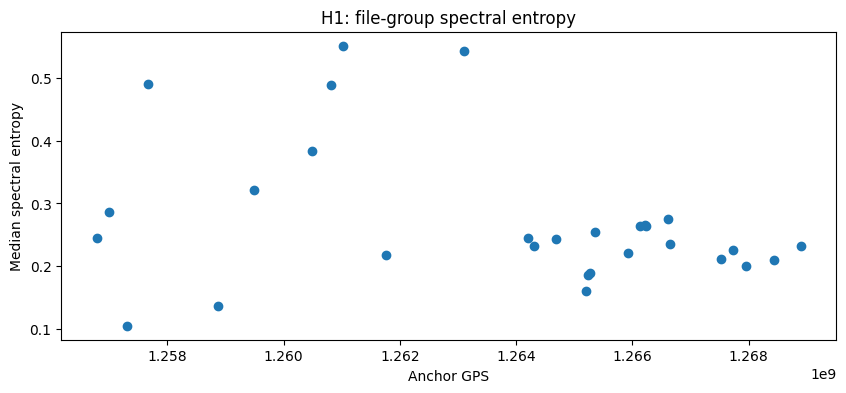

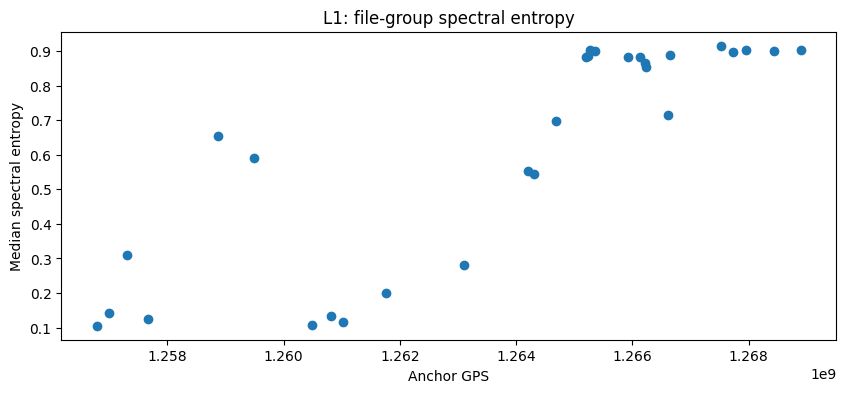

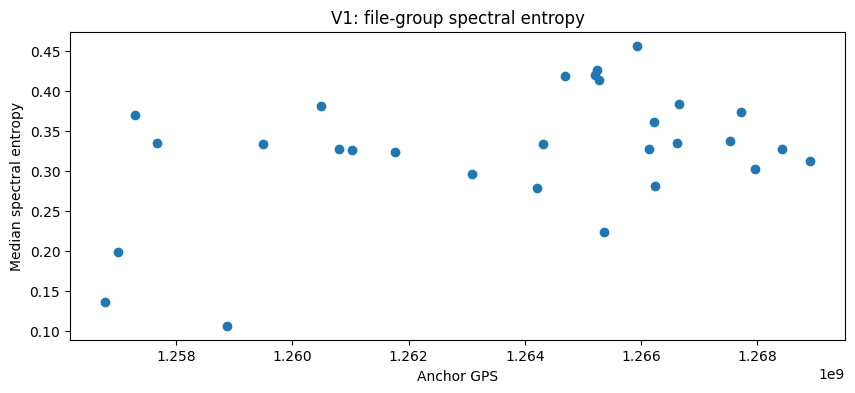

In [76]:
for ifo in M116_DETECTORS:

    fig, ax = plt.subplots(
        figsize=(10, 4)
    )

    ax.scatter(
        df_group_features_M116[
            "anchor_gps"
        ],
        df_group_features_M116[
            f"{ifo}_spectral_entropy"
        ],
    )

    ax.set_xlabel(
        "Anchor GPS"
    )

    ax.set_ylabel(
        "Median spectral entropy"
    )

    ax.set_title(
        f"{ifo}: file-group spectral entropy"
    )

    plt.show()

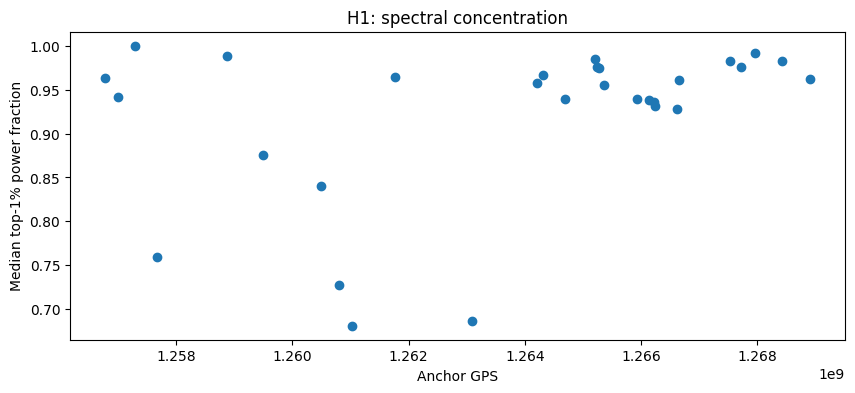

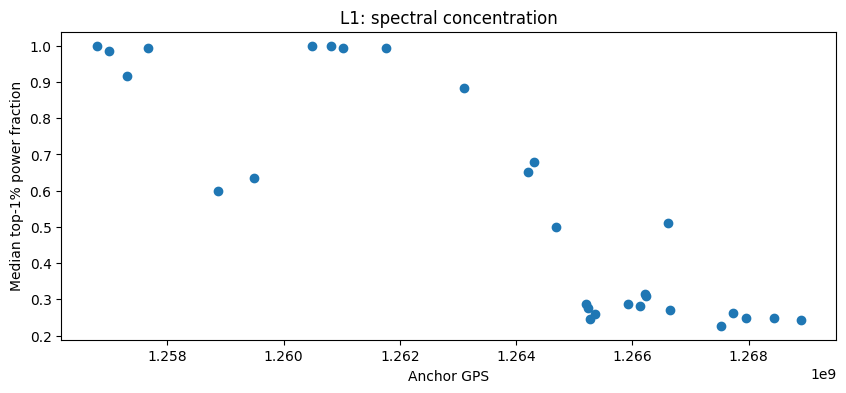

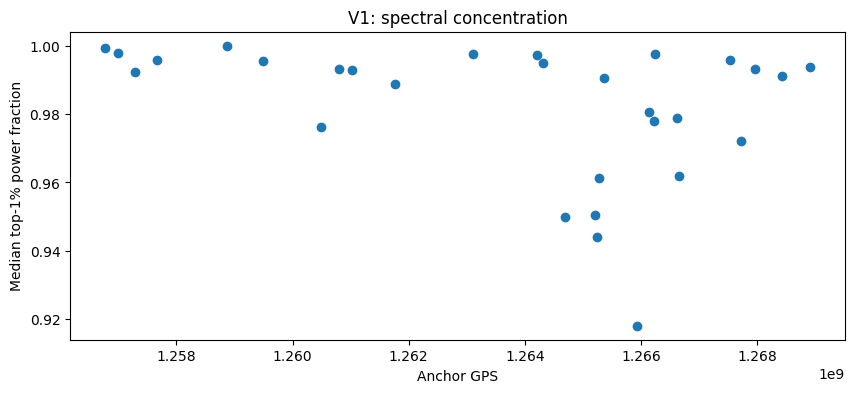

In [77]:
for ifo in M116_DETECTORS:

    fig, ax = plt.subplots(
        figsize=(10, 4)
    )

    ax.scatter(
        df_group_features_M116[
            "anchor_gps"
        ],
        df_group_features_M116[
            f"{ifo}_top1pct_power"
        ],
    )

    ax.set_xlabel(
        "Anchor GPS"
    )

    ax.set_ylabel(
        "Median top-1% power fraction"
    )

    ax.set_title(
        f"{ifo}: spectral concentration"
    )

    plt.show()

In [78]:
split_feature_columns_M116 = []

for ifo in M116_DETECTORS:

    split_feature_columns_M116.extend([
        f"{ifo}_band_std",
        f"{ifo}_spectral_entropy",
        f"{ifo}_top1pct_power",
        f"{ifo}_excess_kurtosis",
        f"{ifo}_power_30_60",
        f"{ifo}_power_60_120",
        f"{ifo}_power_120_256",
        f"{ifo}_power_256_512",
    ])

In [79]:
X_split_raw_M116 = (
    df_group_features_M116[
        split_feature_columns_M116
    ]
    .to_numpy(
        dtype=float
    )
    .copy()
)

In [80]:
positive_suffixes_M116 = (
    "_band_std",
    "_power_30_60",
    "_power_60_120",
    "_power_120_256",
    "_power_256_512",
)

for j, column in enumerate(
    split_feature_columns_M116
):

    if column.endswith(
        positive_suffixes_M116
    ):

        X_split_raw_M116[
            :,
            j,
        ] = np.log10(
            np.maximum(
                X_split_raw_M116[
                    :,
                    j,
                ],
                1e-300,
            )
        )

In [81]:
X_split_mean_M116 = (
    X_split_raw_M116.mean(
        axis=0
    )
)

X_split_std_M116 = (
    X_split_raw_M116.std(
        axis=0,
        ddof=1,
    )
)

X_split_std_M116[
    X_split_std_M116 == 0
] = 1.0

In [82]:
X_split_M116 = (
    X_split_raw_M116
    - X_split_mean_M116
) / X_split_std_M116

In [83]:
gps_M116 = (
    df_group_features_M116[
        "anchor_gps"
    ]
    .to_numpy(
        dtype=float
    )
)

gps_z_M116 = (
    gps_M116
    - gps_M116.mean()
) / gps_M116.std(
    ddof=1
)

In [84]:
temporal_order_M116 = np.argsort(
    gps_M116
)

temporal_stratum_M116 = np.empty(
    n_groups_M116,
    dtype=int,
)

for stratum, indices in enumerate(
    np.array_split(
        temporal_order_M116,
        3,
    )
):
    temporal_stratum_M116[
        indices
    ] = stratum

In [85]:
df_group_features_M116[
    "temporal_stratum"
] = temporal_stratum_M116

display(
    df_group_features_M116[
        [
            "file_group_id",
            "anchor_event",
            "anchor_gps",
            "temporal_stratum",
        ]
    ]
)

,file_group_id,anchor_event,anchor_gps,temporal_stratum
0,0,GW191103_012549,1.256780e+09,0
1,1,GW191105_143521,1.257000e+09,0
2,2,GW191109_010717,1.257297e+09,0
3,3,GW191113_071753,1.257665e+09,0
4,4,GW191127_050227,1.258866e+09,0
5,6,GW191204_110529,1.259493e+09,0
6,7,GW191215_223052,1.260484e+09,0
7,8,GW191219_163120,1.260808e+09,0
8,9,GW191222_033537,1.261021e+09,0
9,10,GW191230_180458,1.261764e+09,0


## 4. Balanced environment-disjoint split

Thirty unique H1/L1/V1 file groups were discovered.

One environment (`file_group_id=5`) contains no accepted finite off-source block after the GW veto and finite-strain QC, and is therefore excluded from dataset construction.

The usable real-noise bank consequently contains

$$
29
$$

independent detector environments.

The target group-level split is

$$
20/3/3/3
$$

for train/validation/calibration/test.

The groups are ordered chronologically and divided into three approximately equal temporal strata.

Within every stratum, one group is assigned to validation, calibration and test, while the remaining environments are assigned to training.

Among random assignments satisfying this temporal constraint, the selected split minimizes mismatch in the diagnostic noise-feature space.

Thus the split preserves

$$
\text{environment independence}
+
\text{noise-distribution balance}
+
\text{temporal coverage}.
$$

In [86]:
def split_centroid_score_M116(
    assignment,
    X,
    gps_z,
):
    global_mu = X.mean(
        axis=0
    )

    score = 0.0

    # Holdouts get stronger balance weight.
    split_weights = {
        "train": 0.25,
        "val": 1.0,
        "cal": 1.0,
        "test": 1.0,
    }

    for split_name, weight in (
        split_weights.items()
    ):

        idx = np.where(
            assignment
            == split_name
        )[0]

        mu = X[idx].mean(
            axis=0
        )

        feature_dist = np.mean(
            (
                mu - global_mu
            )**2
        )

        # Encourage temporal centering but
        # do not dominate noise statistics.
        gps_dist = (
            np.mean(
                gps_z[idx]
            )**2
        )

        score += (
            weight
            * (
                feature_dist
                + 0.10 * gps_dist
            )
        )

    return float(score)

In [87]:
rng_split_M116 = np.random.default_rng(
    M116_SPLIT_SEED
)

best_score_M116 = np.inf
best_assignment_M116 = None

indices_by_stratum_M116 = {
    stratum:
        np.where(
            temporal_stratum_M116
            == stratum
        )[0]
    for stratum in range(3)
}

In [88]:
for trial in range(
    M116_SPLIT_SEARCH_TRIALS
):

    assignment = np.full(
        n_groups_M116,
        "train",
        dtype=object,
    )

    for stratum in range(3):

        idx = (
            indices_by_stratum_M116[
                stratum
            ].copy()
        )

        rng_split_M116.shuffle(
            idx
        )

        assignment[
            idx[0]
        ] = "val"

        assignment[
            idx[1]
        ] = "cal"

        assignment[
            idx[2]
        ] = "test"

        # Remaining seven stay train.

    score = (
        split_centroid_score_M116(
            assignment,
            X_split_M116,
            gps_z_M116,
        )
    )

    if score < best_score_M116:

        best_score_M116 = score

        best_assignment_M116 = (
            assignment.copy()
        )

In [89]:
print(
    "Best split score:",
    best_score_M116,
)

pd.Series(
    best_assignment_M116
).value_counts()

Best split score: 0.22665938143344658


train    20
test      3
val       3
cal       3
Name: count, dtype: int64

In [90]:
df_group_features_M116[
    "split"
] = best_assignment_M116

In [91]:
df_group_split_M116 = (
    df_group_features_M116[
        [
            "file_group_id",
            "anchor_event",
            "anchor_gps",
            "temporal_stratum",
            "split",
            "n_candidates",
            "n_accepted",
            "accepted_fraction",
        ]
    ]
    .sort_values(
        [
            "split",
            "anchor_gps",
        ]
    )
    .reset_index(drop=True)
)

display(
    df_group_split_M116
)

,file_group_id,anchor_event,anchor_gps,temporal_stratum,split,n_candidates,n_accepted,accepted_fraction
0,8,GW191219_163120,1.260808e+09,0,cal,15,13,0.866667
1,13,GW200129_065458,1.264316e+09,1,cal,15,13,0.866667
2,26,GW200308_173609,1.267724e+09,2,cal,15,13,0.866667
3,1,GW191105_143521,1.257000e+09,0,test,15,11,0.733333
4,17,GW200209_085452,1.265274e+09,1,test,15,13,0.866667
5,25,GW200306_093714,1.267523e+09,2,test,11,1,0.090909
6,0,GW191103_012549,1.256780e+09,0,train,8,6,0.750000
7,2,GW191109_010717,1.257297e+09,0,train,11,5,0.454545
8,3,GW191113_071753,1.257665e+09,0,train,15,8,0.533333
9,4,GW191127_050227,1.258866e+09,0,train,15,13,0.866667


In [92]:


assert (
    df_group_split_M116[
        "split"
    ]
    .value_counts()
    .to_dict()
    ==
    M116_SPLIT_GROUP_COUNTS
)

assert not (
    df_group_split_M116[
        "file_group_id"
    ].duplicated()
    .any()
)

print(
    "Group-disjoint split contract passed."
)

Group-disjoint split contract passed.


In [93]:
df_temporal_split_summary_M116 = (
    df_group_features_M116
    .groupby(
        "split"
    )
    .agg(
        n_groups=(
            "file_group_id",
            "count",
        ),

        gps_min=(
            "anchor_gps",
            "min",
        ),

        gps_median=(
            "anchor_gps",
            "median",
        ),

        gps_max=(
            "anchor_gps",
            "max",
        ),
    )
    .reset_index()
)

display(
    df_temporal_split_summary_M116
)

,split,n_groups,gps_min,gps_median,gps_max
0,cal,3,1.260808e+09,1.264316e+09,1.267724e+09
1,test,3,1.257000e+09,1.265274e+09,1.267523e+09
2,train,20,1.256780e+09,1.265219e+09,1.268904e+09
3,val,3,1.260484e+09,1.264213e+09,1.267963e+09


In [94]:
pd.crosstab(
    df_group_features_M116[
        "split"
    ],
    df_group_features_M116[
        "temporal_stratum"
    ],
)

temporal_stratum,0,1,2
split,,,
cal,1,1,1
test,1,1,1
train,7,7,6
val,1,1,1


In [95]:
balance_columns_M116 = []

for ifo in M116_DETECTORS:

    balance_columns_M116.extend([
        f"{ifo}_spectral_entropy",
        f"{ifo}_top1pct_power",
        f"{ifo}_excess_kurtosis",
    ])

In [96]:
df_split_noise_balance_M116 = (
    df_group_features_M116
    .groupby(
        "split"
    )[
        balance_columns_M116
    ]
    .median()
)

display(
    df_split_noise_balance_M116
)

,H1_spectral_entropy,H1_top1pct_power,H1_excess_kurtosis,L1_spectral_entropy,L1_top1pct_power,L1_excess_kurtosis,V1_spectral_entropy,V1_top1pct_power,V1_excess_kurtosis
split,,,,,,,,,
cal,0.232518,0.966806,0.936337,0.544110,0.678563,1837.224184,0.333491,0.993081,-0.291560
test,0.211548,0.974542,0.507279,0.903851,0.245486,5842.448075,0.337638,0.995824,-0.256897
train,0.243968,0.947394,-0.162780,0.785402,0.407713,2456.656632,0.330896,0.990754,-0.314785
val,0.245201,0.957877,0.075000,0.553593,0.650722,3685.302464,0.302406,0.993172,-0.455988


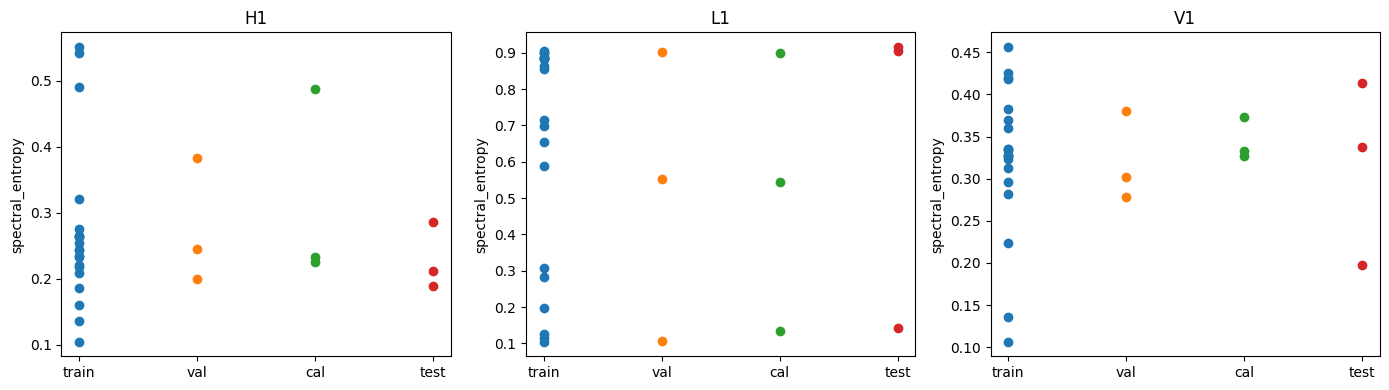

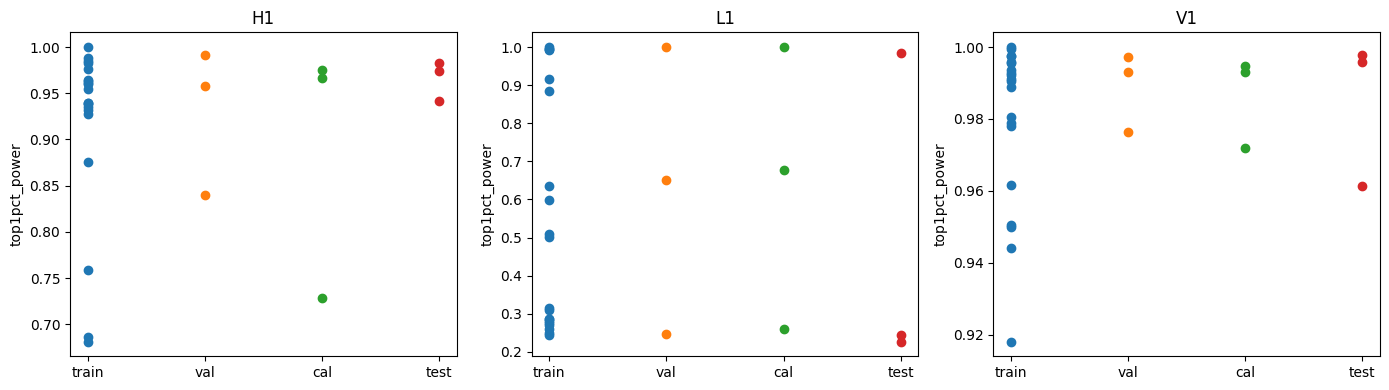

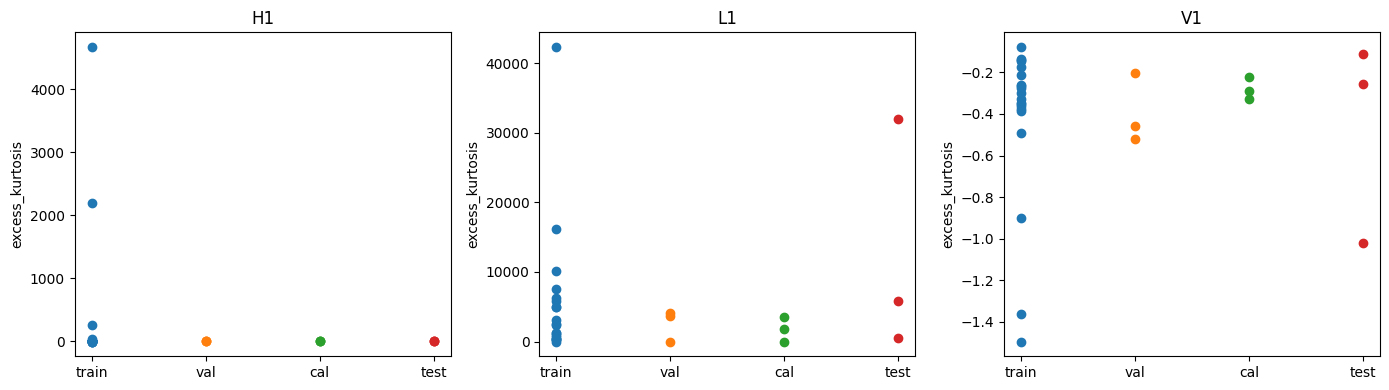

In [97]:
for metric in (
    "spectral_entropy",
    "top1pct_power",
    "excess_kurtosis",
):

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(14, 4),
        sharey=False,
    )

    for ax, ifo in zip(
        axes,
        M116_DETECTORS,
    ):

        column = (
            f"{ifo}_{metric}"
        )

        for split_name in (
            "train",
            "val",
            "cal",
            "test",
        ):

            d = (
                df_group_features_M116[
                    df_group_features_M116[
                        "split"
                    ]
                    == split_name
                ]
            )

            ax.scatter(
                [split_name]
                * len(d),
                d[column],
                label=split_name,
            )

        ax.set_title(
            ifo
        )

        ax.set_ylabel(
            metric
        )

    plt.tight_layout()
    plt.show()

In [98]:
group_to_split_M116 = (
    df_group_split_M116
    .set_index(
        "file_group_id"
    )[
        "split"
    ]
    .to_dict()
)

In [99]:
df_real_blocks_M116[
    "split"
] = (
    df_real_blocks_M116[
        "file_group_id"
    ]
    .map(
        group_to_split_M116
    )
)

In [100]:
split_counts_per_group_M116 = (
    df_real_blocks_M116
    .groupby(
        "file_group_id"
    )[
        "split"
    ]
    .nunique()
)

assert (
    split_counts_per_group_M116
    == 1
).all()

print(
    "No file group crosses splits."
)

No file group crosses splits.


In [101]:
display(
    df_real_blocks_M116
    .groupby(
        "split"
    )
    .agg(
        n_file_groups=(
            "file_group_id",
            "nunique",
        ),

        n_blocks=(
            "block_id",
            "count",
        ),

        total_noise_seconds=(
            "block_duration_s",
            "sum",
        ),
    )
    .reset_index()
)

,split,n_file_groups,n_blocks,total_noise_seconds
0,cal,3,39,9984.0
1,test,3,25,6400.0
2,train,20,200,51200.0
3,val,3,28,7168.0


In [102]:
df_real_blocks_M116[
    "psd_start"
] = (
    df_real_blocks_M116[
        "block_start"
    ]
)

df_real_blocks_M116[
    "psd_end"
] = (
    df_real_blocks_M116[
        "psd_start"
    ]
    +
    M116_PSD_REFERENCE_DURATION_S
)

df_real_blocks_M116[
    "noise_region_start"
] = (
    df_real_blocks_M116[
        "psd_end"
    ]
    +
    M116_PSD_TO_NOISE_GUARD_S
)

df_real_blocks_M116[
    "noise_region_end"
] = (
    df_real_blocks_M116[
        "block_end"
    ]
)

In [103]:
assert (
    df_real_blocks_M116[
        "psd_end"
    ]
    <=
    df_real_blocks_M116[
        "noise_region_start"
    ]
).all()

assert (
    df_real_blocks_M116[
        "noise_region_end"
    ]
    >
    df_real_blocks_M116[
        "noise_region_start"
    ]
).all()

print(
    "Noise-region duration:",
    (
        df_real_blocks_M116[
            "noise_region_end"
        ]
        -
        df_real_blocks_M116[
            "noise_region_start"
        ]
    ).unique(),
)

Noise-region duration: [120.]


In [104]:
def build_crop_centers_for_block_M116(
    row,
):
    half_processing = (
        M116_PROCESSING_DURATION_S
        / 2.0
    )

    first_center = (
        float(
            row[
                "noise_region_start"
            ]
        )
        +
        half_processing
    )

    last_center = (
        float(
            row[
                "noise_region_end"
            ]
        )
        -
        half_processing
    )

    if (
        last_center
        < first_center
    ):
        return []

    centers = np.arange(
        first_center,
        last_center
        + 1e-9,
        M116_CROP_SPACING_S,
    )

    return centers.tolist()

In [105]:
crop_rows_M116 = []

for _, row in (
    df_real_blocks_M116
    .iterrows()
):

    centers = (
        build_crop_centers_for_block_M116(
            row
        )
    )

    for crop_index, center in enumerate(
        centers
    ):

        crop_rows_M116.append({
            "block_id":
                row["block_id"],

            "file_group_id":
                int(
                    row[
                        "file_group_id"
                    ]
                ),

            "split":
                row["split"],

            "crop_index":
                int(
                    crop_index
                ),

            "center_gps":
                float(
                    center
                ),

            "processing_start":
                float(
                    center
                    -
                    M116_PROCESSING_DURATION_S
                    / 2.0
                ),

            "processing_end":
                float(
                    center
                    +
                    M116_PROCESSING_DURATION_S
                    / 2.0
                ),

            "psd_start":
                float(
                    row[
                        "psd_start"
                    ]
                ),

            "psd_end":
                float(
                    row[
                        "psd_end"
                    ]
                ),

            "noise_region_start":
                float(
                    row[
                        "noise_region_start"
                    ]
                ),

            "noise_region_end":
                float(
                    row[
                        "noise_region_end"
                    ]
                ),
        })

In [106]:
df_noise_crops_M116 = (
    pd.DataFrame(
        crop_rows_M116
    )
)

df_noise_crops_M116[
    "noise_crop_id"
] = [
    f"M116_RC_{i:06d}"
    for i in range(
        len(
            df_noise_crops_M116
        )
    )
]

In [107]:
assert len(
    df_noise_crops_M116
) > 0

assert not (
    df_noise_crops_M116[
        "noise_crop_id"
    ]
    .duplicated()
    .any()
)

assert np.allclose(
    (
        df_noise_crops_M116[
            "processing_end"
        ]
        -
        df_noise_crops_M116[
            "processing_start"
        ]
    ),
    M116_PROCESSING_DURATION_S,
)

In [108]:
assert (
    df_noise_crops_M116[
        "processing_start"
    ]
    >=
    df_noise_crops_M116[
        "noise_region_start"
    ]
).all()

assert (
    df_noise_crops_M116[
        "processing_end"
    ]
    <=
    df_noise_crops_M116[
        "noise_region_end"
    ]
).all()

In [109]:
assert (
    df_noise_crops_M116[
        "processing_start"
    ]
    >=
    df_noise_crops_M116[
        "psd_end"
    ]
).all()

print(
    "Crop temporal contracts passed."
)

Crop temporal contracts passed.


In [110]:
split_groups_M116 = {
    split_name:
        set(
            df_noise_crops_M116[
                df_noise_crops_M116[
                    "split"
                ] == split_name
            ][
                "file_group_id"
            ]
            .astype(int)
        )

    for split_name in (
        "train",
        "val",
        "cal",
        "test",
    )
}

In [111]:
split_names_M116 = list(
    split_groups_M116
)

for i, split_a in enumerate(
    split_names_M116
):

    for split_b in (
        split_names_M116[
            i + 1:
        ]
    ):

        overlap = (
            split_groups_M116[
                split_a
            ]
            &
            split_groups_M116[
                split_b
            ]
        )

        print(
            split_a,
            "vs",
            split_b,
            "overlap:",
            overlap,
        )

        assert len(
            overlap
        ) == 0

print(
    "Crop-level group leakage check passed."
)

train vs val overlap: set()
train vs cal overlap: set()
train vs test overlap: set()
val vs cal overlap: set()
val vs test overlap: set()
cal vs test overlap: set()
Crop-level group leakage check passed.


In [112]:
df_noise_bank_summary_M116 = (
    df_noise_crops_M116
    .groupby(
        "split"
    )
    .agg(
        n_file_groups=(
            "file_group_id",
            "nunique",
        ),

        n_blocks=(
            "block_id",
            "nunique",
        ),

        n_unique_noise_crops=(
            "noise_crop_id",
            "count",
        ),

        gps_min=(
            "center_gps",
            "min",
        ),

        gps_max=(
            "center_gps",
            "max",
        ),
    )
    .reset_index()
)

display(
    df_noise_bank_summary_M116
)

,split,n_file_groups,n_blocks,n_unique_noise_crops,gps_min,gps_max
0,cal,3,39,585,1.260806e+09,1.267726e+09
1,test,3,25,375,1.256998e+09,1.267523e+09
2,train,20,200,3000,1.256778e+09,1.268905e+09
3,val,3,28,420,1.260482e+09,1.267964e+09


In [113]:
print(
    "Total unique real-noise crops:",
    len(
        df_noise_crops_M116
    )
)

print()

print(
    df_noise_crops_M116[
        "split"
    ]
    .value_counts()
)

Total unique real-noise crops: 4380

split
train    3000
cal       585
val       420
test      375
Name: count, dtype: int64


In [114]:
M116_MANIFEST_DIR = (
    DATA_ROOT_M116
    / "processed"
    / "m11_6_manifests"
)

M116_MANIFEST_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

In [115]:
path_groups_M116 = (
    M116_MANIFEST_DIR
    / "m11_6_file_groups.csv"
)

path_blocks_M116 = (
    M116_MANIFEST_DIR
    / "m11_6_real_noise_blocks.csv"
)

path_crops_M116 = (
    M116_MANIFEST_DIR
    / "m11_6_real_noise_crops.csv"
)

path_block_features_M116 = (
    M116_MANIFEST_DIR
    / "m11_6_block_noise_features.csv"
)

In [116]:
df_group_features_M116.to_csv(
    path_groups_M116,
    index=False,
)

df_real_blocks_M116.to_csv(
    path_blocks_M116,
    index=False,
)

df_noise_crops_M116.to_csv(
    path_crops_M116,
    index=False,
)

df_block_features_M116.to_csv(
    path_block_features_M116,
    index=False,
)

In [117]:
for path in (
    path_groups_M116,
    path_blocks_M116,
    path_crops_M116,
    path_block_features_M116,
):

    print(
        path.name,
        "| exists:",
        path.exists(),
        "| size:",
        path.stat().st_size,
        "bytes",
    )

m11_6_file_groups.csv | exists: True | size: 19071 bytes
m11_6_real_noise_blocks.csv | exists: True | size: 41933 bytes
m11_6_real_noise_crops.csv | exists: True | size: 602526 bytes
m11_6_block_noise_features.csv | exists: True | size: 187797 bytes


In [118]:
df_groups_reload_M116 = (
    pd.read_csv(
        path_groups_M116
    )
)

df_blocks_reload_M116 = (
    pd.read_csv(
        path_blocks_M116
    )
)

df_crops_reload_M116 = (
    pd.read_csv(
        path_crops_M116
    )
)

df_features_reload_M116 = (
    pd.read_csv(
        path_block_features_M116
    )
)

In [119]:
assert (
    len(
        df_groups_reload_M116
    )
    ==
    len(
        df_group_features_M116
    )
)

assert (
    len(
        df_blocks_reload_M116
    )
    ==
    len(
        df_real_blocks_M116
    )
)

assert (
    len(
        df_crops_reload_M116
    )
    ==
    len(
        df_noise_crops_M116
    )
)

assert (
    len(
        df_features_reload_M116
    )
    ==
    len(
        df_block_features_M116
    )
)

assert set(
    df_crops_reload_M116[
        "split"
    ]
) == {
    "train",
    "val",
    "cal",
    "test",
}

print(
    "Manifest reload contract passed."
)

Manifest reload contract passed.


In [120]:
print(
    "========== M11.6-B2 FINAL AUDIT =========="
)

print(
    "\nFile groups:",
    len(
        df_group_features_M116
    ),
)

print(
    "\nAccepted 256 s blocks:",
    len(
        df_real_blocks_M116
    ),
)

print(
    "\nUnique processing-context crops:",
    len(
        df_noise_crops_M116
    ),
)

print(
    "\nGroup split:"
)

print(
    df_group_features_M116[
        "split"
    ]
    .value_counts()
)

print(
    "\nCrop split:"
)

print(
    df_noise_crops_M116[
        "split"
    ]
    .value_counts()
)

print(
    "\nMinimum distance to excluded "
    "catalogued GW:",
    df_real_blocks_M116[
        "nearest_catalog_event_distance_s"
    ].min(),
    "s",
)

print(
    "\nManifest directory:",
    M116_MANIFEST_DIR,
)

print(
    "\nB2 COMPLETE"
)

========== M11.6-B2 FINAL AUDIT ==========

File groups: 29

Accepted 256 s blocks: 292

Unique processing-context crops: 4380

Group split:
split
train    20
test      3
val       3
cal       3
Name: count, dtype: int64

Crop split:
split
train    3000
cal       585
val       420
test      375
Name: count, dtype: int64

Minimum distance to excluded catalogued GW: 107.5 s

Manifest directory: /data/vserrano/cbc_pe_data/processed/m11_6_manifests

B2 COMPLETE


### Open methodological issue — finite-strain granularity

The current B2 pilot requires complete 256 s H1/L1/V1 blocks to be finite.

This criterion is intentionally conservative but may discard substantial amounts of otherwise usable detector strain when a short gap or non-finite interval occurs inside a long block.

Before freezing the M11.6 real-noise bank, the low-yield environments will therefore be re-evaluated using a finer 32 s QC granularity.

The purpose is not to change the environment-level split, but to determine whether the low block counts reflect genuinely poor detector availability or an unnecessarily coarse validity criterion.

PSD-reference validity and short noise-crop validity will remain separate requirements.

In [121]:
def approximate_rms_from_psd_M116(
    psd,
    *,
    fmin=0.0,
    fmax=None,
):
    f = (
        np.arange(len(psd))
        * float(psd.delta_f)
    )

    values = np.asarray(
        psd,
        dtype=float,
    )

    mask = (
        np.isfinite(values)
        &
        (values >= 0)
        &
        (f >= float(fmin))
    )

    if fmax is not None:
        mask &= (
            f < float(fmax)
        )

    variance = (
        np.sum(
            values[mask]
        )
        *
        float(psd.delta_f)
    )

    return float(
        np.sqrt(variance)
    )

# M11.6-B2.5 — Finite-strain granularity sensitivity audit

The initial M11.6-B2 real-noise bank required every 256 s H1/L1/V1 block to be completely finite.

This criterion is conservative, but it can reject a large amount of otherwise usable strain if a short corrupted interval occurs anywhere inside a long block.

This audit tests whether the low-yield detector environments are genuinely dominated by invalid strain or are instead being penalized by the coarse 256 s validity criterion.

Three granularities are compared:

$$
T_{\rm QC}
\in
\{
256\,{\rm s},
32\,{\rm s},
4.8125\,{\rm s}
\}.
$$

The last value corresponds to the actual processing-context duration used for one CNN example.

The experiment does **not** alter the file-group split.

Its only purpose is to determine the appropriate temporal granularity for selecting valid real-noise realizations before freezing the M11.6 noise bank.

The empirical PSD requirement remains conceptually separate and will continue to require a sufficiently long finite off-source reference interval.

In [122]:
M116_LOW_YIELD_MAX_BLOCKS = 2

df_low_yield_groups_M116 = (
    df_qc_by_group_M116[
        df_qc_by_group_M116[
            "n_accepted"
        ]
        <= M116_LOW_YIELD_MAX_BLOCKS
    ]
    .copy()
    .sort_values(
        "file_group_id"
    )
    .reset_index(drop=True)
)

display(
    df_low_yield_groups_M116
)

print(
    "Low-yield file groups:",
    df_low_yield_groups_M116[
        "file_group_id"
    ].astype(int).tolist()
)

,file_group_id,n_candidates,n_gw_safe,n_finite,n_accepted,accepted_fraction
0,5,10,8,0,0,0.000000
1,6,13,12,1,1,0.076923
2,22,10,9,1,1,0.100000
3,25,11,9,1,1,0.090909


Low-yield file groups: [5, 6, 22, 25]


In [123]:
df_high_yield_controls_M116 = (
    df_qc_by_group_M116
    .sort_values(
        "n_accepted",
        ascending=False,
    )
    .head(2)
    .copy()
)

display(
    df_high_yield_controls_M116
)

,file_group_id,n_candidates,n_gw_safe,n_finite,n_accepted,accepted_fraction
4,4,15,13,13,13,0.866667
7,7,15,13,13,13,0.866667


In [124]:
audit_group_ids_M116 = sorted(
    set(
        df_low_yield_groups_M116[
            "file_group_id"
        ]
        .astype(int)
        .tolist()
    )
    |
    set(
        df_high_yield_controls_M116[
            "file_group_id"
        ]
        .astype(int)
        .tolist()
    )
)

print(
    "Groups included in audit:",
    audit_group_ids_M116,
)

Groups included in audit: [4, 5, 6, 7, 22, 25]


In [125]:
#Config del audit

M116_AUDIT_CHUNK_DURATION_S = 32.0

# Same file-edge and GW exclusion policy as B2.
M116_AUDIT_EDGE_MARGIN_S = (
    M116_FILE_EDGE_MARGIN_S_FINAL
)

M116_AUDIT_GW_MARGIN_S = (
    M116_GW_EXCLUSION_HALF_WIDTH_S_FINAL
)

# Same grid spacing used for the candidate
# processing-context crops.
M116_AUDIT_CROP_SPACING_S = (
    M116_CROP_SPACING_S
)

print(
    "32 s QC chunk:",
    M116_AUDIT_CHUNK_DURATION_S,
)

print(
    "Processing window:",
    M116_PROCESSING_DURATION_S,
)

print(
    "Crop-grid spacing:",
    M116_AUDIT_CROP_SPACING_S,
)

32 s QC chunk: 32.0
Processing window: 4.8125
Crop-grid spacing: 8.0


In [126]:
#Helper GW veto (for any interval)
def interval_passes_gw_veto_M116(
    start,
    end,
    catalog_times,
    margin_s,
):
    nearby = (
        catalog_events_near_interval(
            start=float(start),
            end=float(end),
            catalog_times=catalog_times,
            margin_s=float(margin_s),
        )
    )

    return len(nearby) == 0

# Same for finite HLV
def interval_is_finite_all_detectors_M116(
    strains,
    start,
    end,
):
    return all(
        time_slice_is_finite(
            strains[ifo],
            float(start),
            float(end),
        )
        for ifo
        in M116_DETECTORS
    )

#Helper to make no overlapping chunks of any size
def build_fixed_chunks_M116(
    *,
    start,
    end,
    chunk_duration_s,
    edge_margin_s,
):
    usable_start = (
        float(start)
        + float(edge_margin_s)
    )

    usable_end = (
        float(end)
        - float(edge_margin_s)
    )

    rows = []

    chunk_index = 0
    t0 = usable_start

    while (
        t0 + chunk_duration_s
        <= usable_end
    ):
        t1 = (
            t0
            + chunk_duration_s
        )

        rows.append({
            "chunk_index":
                int(chunk_index),

            "chunk_start":
                float(t0),

            "chunk_end":
                float(t1),

            "chunk_duration_s":
                float(chunk_duration_s),
        })

        chunk_index += 1
        t0 = t1

    return rows

# See if can be used as a valid CNN-sample
def build_processing_window_grid_M116(
    *,
    start,
    end,
    edge_margin_s,
    processing_duration_s,
    spacing_s,
):
    usable_start = (
        float(start)
        + float(edge_margin_s)
    )

    usable_end = (
        float(end)
        - float(edge_margin_s)
    )

    half = (
        float(processing_duration_s)
        / 2.0
    )

    first_center = (
        usable_start
        + half
    )

    last_center = (
        usable_end
        - half
    )

    if (
        last_center
        < first_center
    ):
        return []

    centers = np.arange(
        first_center,
        last_center + 1e-9,
        float(spacing_s),
    )

    rows = []

    for i, center in enumerate(
        centers
    ):
        rows.append({
            "crop_grid_index":
                int(i),

            "center_gps":
                float(center),

            "processing_start":
                float(
                    center - half
                ),

            "processing_end":
                float(
                    center + half
                ),
        })

    return rows


In [127]:
#Audit (in streaming)
audit_chunk_rows_M116 = []
audit_crop_rows_M116 = []

for group_counter, group_id in enumerate(
    audit_group_ids_M116,
    start=1,
):

    print(
        "\n"
        "=================================================="
    )

    print(
        f"[{group_counter}/"
        f"{len(audit_group_ids_M116)}] "
        f"file_group_id={group_id}"
    )

    file_group_row = (
        df_unique_file_groups_M116[
            df_unique_file_groups_M116[
                "file_group_id"
            ]
            == group_id
        ]
        .iloc[0]
    )

    strains = (
        load_file_group_strains_M116(
            file_group_row
        )
    )

    try:

        common_start, common_end = (
            common_timeseries_interval(
                strains
            )
        )

        # ====================================================
        # A. 32 s chunk audit
        # ====================================================

        chunks_32 = (
            build_fixed_chunks_M116(
                start=common_start,
                end=common_end,
                chunk_duration_s=(
                    M116_AUDIT_CHUNK_DURATION_S
                ),
                edge_margin_s=(
                    M116_AUDIT_EDGE_MARGIN_S
                ),
            )
        )

        for chunk in chunks_32:

            start = (
                chunk[
                    "chunk_start"
                ]
            )

            end = (
                chunk[
                    "chunk_end"
                ]
            )

            passes_gw = (
                interval_passes_gw_veto_M116(
                    start=start,
                    end=end,
                    catalog_times=(
                        catalog_gps_exclusion_M116
                    ),
                    margin_s=(
                        M116_AUDIT_GW_MARGIN_S
                    ),
                )
            )

            if passes_gw:

                finite_ok = (
                    interval_is_finite_all_detectors_M116(
                        strains,
                        start,
                        end,
                    )
                )

            else:
                finite_ok = False

            audit_chunk_rows_M116.append({
                "file_group_id":
                    int(group_id),

                "chunk_index":
                    int(
                        chunk[
                            "chunk_index"
                        ]
                    ),

                "chunk_start":
                    float(start),

                "chunk_end":
                    float(end),

                "passes_gw_veto":
                    bool(
                        passes_gw
                    ),

                "passes_finite_qc":
                    bool(
                        finite_ok
                    ),

                "passes_basic_qc":
                    bool(
                        passes_gw
                        and finite_ok
                    ),
            })

        # ====================================================
        # B. Direct 4.8125 s processing-window audit
        # ====================================================

        crop_grid = (
            build_processing_window_grid_M116(
                start=common_start,
                end=common_end,
                edge_margin_s=(
                    M116_AUDIT_EDGE_MARGIN_S
                ),
                processing_duration_s=(
                    M116_PROCESSING_DURATION_S
                ),
                spacing_s=(
                    M116_AUDIT_CROP_SPACING_S
                ),
            )
        )

        for crop in crop_grid:

            start = (
                crop[
                    "processing_start"
                ]
            )

            end = (
                crop[
                    "processing_end"
                ]
            )

            passes_gw = (
                interval_passes_gw_veto_M116(
                    start=start,
                    end=end,
                    catalog_times=(
                        catalog_gps_exclusion_M116
                    ),
                    margin_s=(
                        M116_AUDIT_GW_MARGIN_S
                    ),
                )
            )

            if passes_gw:

                finite_ok = (
                    interval_is_finite_all_detectors_M116(
                        strains,
                        start,
                        end,
                    )
                )

            else:
                finite_ok = False

            audit_crop_rows_M116.append({
                "file_group_id":
                    int(group_id),

                "crop_grid_index":
                    int(
                        crop[
                            "crop_grid_index"
                        ]
                    ),

                "center_gps":
                    float(
                        crop[
                            "center_gps"
                        ]
                    ),

                "processing_start":
                    float(start),

                "processing_end":
                    float(end),

                "passes_gw_veto":
                    bool(
                        passes_gw
                    ),

                "passes_finite_qc":
                    bool(
                        finite_ok
                    ),

                "passes_basic_qc":
                    bool(
                        passes_gw
                        and finite_ok
                    ),
            })

        print(
            "32 s chunks:",
            len(chunks_32),
            "| direct crop windows:",
            len(crop_grid),
        )

    finally:

        del strains
        gc.collect()


[1/6] file_group_id=4
Using cached file: H-H1_GWOSC_4KHZ_R1-1258864118-4096.hdf5
Using cached file: L-L1_GWOSC_4KHZ_R1-1258864118-4096.hdf5
Using cached file: V-V1_GWOSC_4KHZ_R1-1258864118-4096.hdf5
32 s chunks: 126 | direct crop windows: 504

[2/6] file_group_id=5
Using cached file: H-H1_GWOSC_4KHZ_R1-1259068000-4096.hdf5
Using cached file: L-L1_GWOSC_4KHZ_R1-1259068000-4096.hdf5
Using cached file: V-V1_GWOSC_O3b_4KHZ_R1-1259069440-4096.hdf5
32 s chunks: 81 | direct crop windows: 324

[3/6] file_group_id=6
Using cached file: H-H1_GWOSC_4KHZ_R1-1259490700-4096.hdf5
Using cached file: L-L1_GWOSC_4KHZ_R1-1259490700-4096.hdf5
Using cached file: V-V1_GWOSC_O3b_4KHZ_R1-1259491328-4096.hdf5
32 s chunks: 106 | direct crop windows: 425

[4/6] file_group_id=7
Using cached file: H-H1_GWOSC_4KHZ_R1-1260482223-4096.hdf5
Using cached file: L-L1_GWOSC_4KHZ_R1-1260482223-4096.hdf5
Using cached file: V-V1_GWOSC_4KHZ_R1-1260482223-4096.hdf5
32 s chunks: 126 | direct crop windows: 504

[5/6] file_group

In [128]:
#DFs
df_audit_chunks32_M116 = (
    pd.DataFrame(
        audit_chunk_rows_M116
    )
)

df_audit_crops_direct_M116 = (
    pd.DataFrame(
        audit_crop_rows_M116
    )
)

print(
    "32 s audit rows:",
    len(
        df_audit_chunks32_M116
    )
)

print(
    "Direct crop audit rows:",
    len(
        df_audit_crops_direct_M116
    )
)

32 s audit rows: 614
Direct crop audit rows: 2458


In [129]:
#Summary 32s
df_audit_32_summary_M116 = (
    df_audit_chunks32_M116
    .groupby(
        "file_group_id"
    )
    .agg(
        n_chunks_32=(
            "chunk_index",
            "count",
        ),

        n_gw_safe_32=(
            "passes_gw_veto",
            "sum",
        ),

        n_finite_32=(
            "passes_finite_qc",
            "sum",
        ),

        n_accepted_32=(
            "passes_basic_qc",
            "sum",
        ),
    )
    .reset_index()
)

df_audit_32_summary_M116[
    "accepted_fraction_32"
] = (
    df_audit_32_summary_M116[
        "n_accepted_32"
    ]
    /
    df_audit_32_summary_M116[
        "n_chunks_32"
    ]
)

df_audit_32_summary_M116[
    "usable_seconds_32"
] = (
    df_audit_32_summary_M116[
        "n_accepted_32"
    ]
    *
    M116_AUDIT_CHUNK_DURATION_S
)

display(
    df_audit_32_summary_M116
)

,file_group_id,n_chunks_32,n_gw_safe_32,n_finite_32,n_accepted_32,accepted_fraction_32,usable_seconds_32
0,4,126,121,121,121,0.960317,3872.0
1,5,81,76,1,1,0.012346,32.0
2,6,106,101,12,12,0.113208,384.0
3,7,126,121,121,121,0.960317,3872.0
4,22,84,79,19,19,0.226190,608.0
5,25,91,86,22,22,0.241758,704.0


In [130]:
#Processing-window level summary
df_audit_crop_summary_M116 = (
    df_audit_crops_direct_M116
    .groupby(
        "file_group_id"
    )
    .agg(
        n_crop_candidates=(
            "crop_grid_index",
            "count",
        ),

        n_crop_gw_safe=(
            "passes_gw_veto",
            "sum",
        ),

        n_crop_finite=(
            "passes_finite_qc",
            "sum",
        ),

        n_crop_accepted=(
            "passes_basic_qc",
            "sum",
        ),
    )
    .reset_index()
)

df_audit_crop_summary_M116[
    "accepted_crop_fraction"
] = (
    df_audit_crop_summary_M116[
        "n_crop_accepted"
    ]
    /
    df_audit_crop_summary_M116[
        "n_crop_candidates"
    ]
)

display(
    df_audit_crop_summary_M116
)

,file_group_id,n_crop_candidates,n_crop_gw_safe,n_crop_finite,n_crop_accepted,accepted_crop_fraction
0,4,504,488,488,488,0.968254
1,5,324,308,4,4,0.012346
2,6,425,408,52,52,0.122353
3,7,504,488,488,488,0.968254
4,22,337,320,77,77,0.228487
5,25,364,348,95,95,0.260989


In [131]:
#Merge the original 256s results
df_finite_granularity_audit_M116 = (
    df_qc_by_group_M116[
        [
            "file_group_id",
            "n_candidates",
            "n_gw_safe",
            "n_finite",
            "n_accepted",
            "accepted_fraction",
        ]
    ]
    .rename(
        columns={
            "n_candidates":
                "n_blocks_256",

            "n_gw_safe":
                "n_gw_safe_256",

            "n_finite":
                "n_finite_256",

            "n_accepted":
                "n_accepted_256",

            "accepted_fraction":
                "accepted_fraction_256",
        }
    )
    .merge(
        df_audit_32_summary_M116,
        on="file_group_id",
        how="inner",
        validate="one_to_one",
    )
    .merge(
        df_audit_crop_summary_M116,
        on="file_group_id",
        how="inner",
        validate="one_to_one",
    )
)

In [132]:
df_finite_granularity_audit_M116[
    "usable_seconds_256"
] = (
    df_finite_granularity_audit_M116[
        "n_accepted_256"
    ]
    *
    M116_BLOCK_DURATION_S_FINAL
)

In [133]:
df_finite_granularity_audit_M116[
    "recovered_seconds_32_vs_256"
] = (
    df_finite_granularity_audit_M116[
        "usable_seconds_32"
    ]
    -
    df_finite_granularity_audit_M116[
        "usable_seconds_256"
    ]
)

In [134]:
display(
    df_finite_granularity_audit_M116[
        [
            "file_group_id",

            "n_blocks_256",
            "n_accepted_256",
            "accepted_fraction_256",
            "usable_seconds_256",

            "n_chunks_32",
            "n_accepted_32",
            "accepted_fraction_32",
            "usable_seconds_32",

            "n_crop_candidates",
            "n_crop_accepted",
            "accepted_crop_fraction",

            "recovered_seconds_32_vs_256",
        ]
    ]
)

,file_group_id,n_blocks_256,n_accepted_256,accepted_fraction_256,usable_seconds_256,n_chunks_32,n_accepted_32,accepted_fraction_32,usable_seconds_32,n_crop_candidates,n_crop_accepted,accepted_crop_fraction,recovered_seconds_32_vs_256
0,4,15,13,0.866667,3328.0,126,121,0.960317,3872.0,504,488,0.968254,544.0
1,5,10,0,0.000000,0.0,81,1,0.012346,32.0,324,4,0.012346,32.0
2,6,13,1,0.076923,256.0,106,12,0.113208,384.0,425,52,0.122353,128.0
3,7,15,13,0.866667,3328.0,126,121,0.960317,3872.0,504,488,0.968254,544.0
4,22,10,1,0.100000,256.0,84,19,0.226190,608.0,337,77,0.228487,352.0
5,25,11,1,0.090909,256.0,91,22,0.241758,704.0,364,95,0.260989,448.0


In [135]:
#Separar low-yield de controls
low_yield_ids_M116 = set(
    df_low_yield_groups_M116[
        "file_group_id"
    ]
    .astype(int)
)

df_finite_granularity_audit_M116[
    "audit_role"
] = (
    df_finite_granularity_audit_M116[
        "file_group_id"
    ]
    .apply(
        lambda x:
            "low_yield"
            if int(x)
            in low_yield_ids_M116
            else "high_yield_control"
    )
)

In [136]:
display(
    df_finite_granularity_audit_M116[
        [
            "file_group_id",
            "audit_role",
            "n_accepted_256",
            "n_accepted_32",
            "n_crop_accepted",
            "accepted_fraction_256",
            "accepted_fraction_32",
            "accepted_crop_fraction",
        ]
    ]
)

,file_group_id,audit_role,n_accepted_256,n_accepted_32,n_crop_accepted,accepted_fraction_256,accepted_fraction_32,accepted_crop_fraction
0,4,high_yield_control,13,121,488,0.866667,0.960317,0.968254
1,5,low_yield,0,1,4,0.000000,0.012346,0.012346
2,6,low_yield,1,12,52,0.076923,0.113208,0.122353
3,7,high_yield_control,13,121,488,0.866667,0.960317,0.968254
4,22,low_yield,1,19,77,0.100000,0.226190,0.228487
5,25,low_yield,1,22,95,0.090909,0.241758,0.260989


In [137]:
#Visualize the fraction of accepted granularity
plot_rows_M116 = []

for _, row in (
    df_finite_granularity_audit_M116
    .iterrows()
):

    group_id = int(
        row["file_group_id"]
    )

    plot_rows_M116.extend([
        {
            "file_group_id":
                group_id,

            "granularity":
                "256 s",

            "accepted_fraction":
                row[
                    "accepted_fraction_256"
                ],
        },

        {
            "file_group_id":
                group_id,

            "granularity":
                "32 s",

            "accepted_fraction":
                row[
                    "accepted_fraction_32"
                ],
        },

        {
            "file_group_id":
                group_id,

            "granularity":
                "4.8125 s",

            "accepted_fraction":
                row[
                    "accepted_crop_fraction"
                ],
        },
    ])

df_audit_plot_M116 = (
    pd.DataFrame(
        plot_rows_M116
    )
)

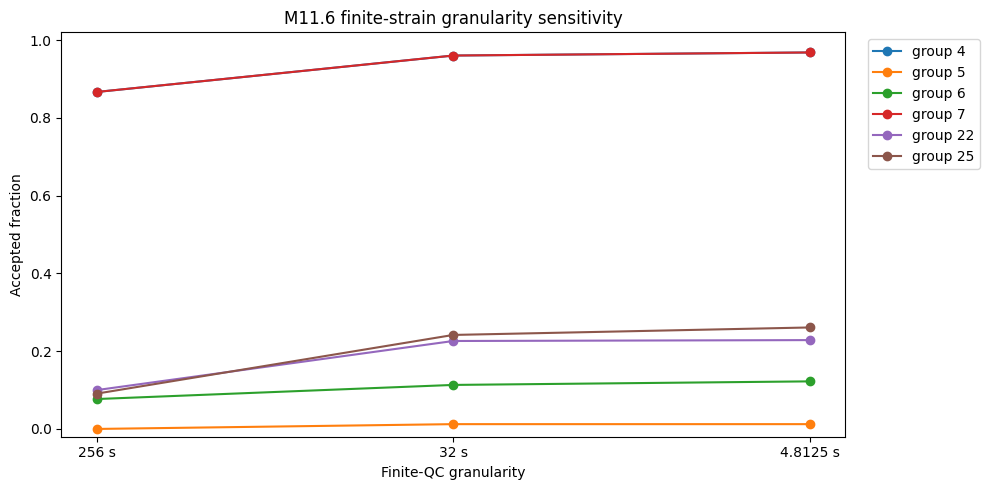

In [138]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

for group_id in (
    df_finite_granularity_audit_M116[
        "file_group_id"
    ]
    .astype(int)
):

    d = (
        df_audit_plot_M116[
            df_audit_plot_M116[
                "file_group_id"
            ]
            == group_id
        ]
    )

    ax.plot(
        d["granularity"],
        d["accepted_fraction"],
        marker="o",
        label=(
            f"group {group_id}"
        ),
    )

ax.set_ylabel(
    "Accepted fraction"
)

ax.set_xlabel(
    "Finite-QC granularity"
)

ax.set_title(
    "M11.6 finite-strain granularity sensitivity"
)

ax.set_ylim(
    -0.02,
    1.02,
)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

In [139]:
#Diagnostic per detector
per_ifo_rows_M116 = []

for group_id in (
    df_low_yield_groups_M116[
        "file_group_id"
    ]
    .astype(int)
):

    file_group_row = (
        df_unique_file_groups_M116[
            df_unique_file_groups_M116[
                "file_group_id"
            ]
            == group_id
        ]
        .iloc[0]
    )

    strains = (
        load_file_group_strains_M116(
            file_group_row
        )
    )

    try:

        common_start, common_end = (
            common_timeseries_interval(
                strains
            )
        )

        chunks = (
            build_fixed_chunks_M116(
                start=common_start,
                end=common_end,
                chunk_duration_s=(
                    M116_AUDIT_CHUNK_DURATION_S
                ),
                edge_margin_s=(
                    M116_AUDIT_EDGE_MARGIN_S
                ),
            )
        )

        for chunk in chunks:

            start = (
                chunk[
                    "chunk_start"
                ]
            )

            end = (
                chunk[
                    "chunk_end"
                ]
            )

            passes_gw = (
                interval_passes_gw_veto_M116(
                    start=start,
                    end=end,
                    catalog_times=(
                        catalog_gps_exclusion_M116
                    ),
                    margin_s=(
                        M116_AUDIT_GW_MARGIN_S
                    ),
                )
            )

            if not passes_gw:
                continue

            row_out = {
                "file_group_id":
                    int(group_id),

                "chunk_index":
                    int(
                        chunk[
                            "chunk_index"
                        ]
                    ),
            }

            for ifo in M116_DETECTORS:

                row_out[
                    f"{ifo}_finite"
                ] = (
                    time_slice_is_finite(
                        strains[ifo],
                        start,
                        end,
                    )
                )

            per_ifo_rows_M116.append(
                row_out
            )

    finally:

        del strains
        gc.collect()

Using cached file: H-H1_GWOSC_4KHZ_R1-1259068000-4096.hdf5
Using cached file: L-L1_GWOSC_4KHZ_R1-1259068000-4096.hdf5
Using cached file: V-V1_GWOSC_O3b_4KHZ_R1-1259069440-4096.hdf5
Using cached file: H-H1_GWOSC_4KHZ_R1-1259490700-4096.hdf5
Using cached file: L-L1_GWOSC_4KHZ_R1-1259490700-4096.hdf5
Using cached file: V-V1_GWOSC_O3b_4KHZ_R1-1259491328-4096.hdf5
Using cached file: H-H1_GWOSC_4KHZ_R1-1266236101-4096.hdf5
Using cached file: L-L1_GWOSC_4KHZ_R1-1266236101-4096.hdf5
Using cached file: V-V1_GWOSC_O3b_4KHZ_R1-1266237440-4096.hdf5
Using cached file: H-H1_GWOSC_4KHZ_R1-1267520605-4096.hdf5
Using cached file: L-L1_GWOSC_4KHZ_R1-1267520605-4096.hdf5
Using cached file: V-V1_GWOSC_O3b_4KHZ_R1-1267519488-4096.hdf5


In [140]:
df_audit_per_ifo_M116 = (
    pd.DataFrame(
        per_ifo_rows_M116
    )
)

display(
    df_audit_per_ifo_M116
)

,file_group_id,chunk_index,H1_finite,L1_finite,V1_finite
0,5,0,True,True,False
1,5,1,True,True,False
2,5,2,True,True,False
3,5,3,True,True,False
4,5,4,True,True,False
...,...,...,...,...,...
337,25,86,True,True,True
338,25,87,True,True,True
339,25,88,True,True,True
340,25,89,True,True,True


In [141]:
ifo_summary_rows_M116 = []

for group_id, group_df in (
    df_audit_per_ifo_M116
    .groupby(
        "file_group_id"
    )
):

    row = {
        "file_group_id":
            int(group_id),

        "n_gw_safe_chunks":
            len(group_df),
    }

    for ifo in M116_DETECTORS:

        row[
            f"{ifo}_finite_fraction"
        ] = (
            group_df[
                f"{ifo}_finite"
            ].mean()
        )

    ifo_summary_rows_M116.append(
        row
    )

df_audit_ifo_summary_M116 = (
    pd.DataFrame(
        ifo_summary_rows_M116
    )
)

display(
    df_audit_ifo_summary_M116
)

,file_group_id,n_gw_safe_chunks,H1_finite_fraction,L1_finite_fraction,V1_finite_fraction
0,5,76,0.947368,1.000000,0.065789
1,6,101,1.000000,0.960396,0.118812
2,22,79,1.000000,1.000000,0.240506
3,25,86,1.000000,1.000000,0.255814


In [142]:
#Sanities del audit
assert (
    set(
        df_finite_granularity_audit_M116[
            "file_group_id"
        ]
        .astype(int)
    )
    ==
    set(
        audit_group_ids_M116
    )
)

assert (
    df_finite_granularity_audit_M116[
        "accepted_fraction_32"
    ]
    .between(
        0.0,
        1.0,
    )
    .all()
)

assert (
    df_finite_granularity_audit_M116[
        "accepted_crop_fraction"
    ]
    .between(
        0.0,
        1.0,
    )
    .all()
)

print(
    "Finite-granularity audit contracts passed."
)

Finite-granularity audit contracts passed.


In [143]:
#Compact audit
print(
    "========== M11.6-B2.5 FINITE-QC AUDIT =========="
)

display(
    df_finite_granularity_audit_M116[
        [
            "file_group_id",
            "audit_role",

            "n_accepted_256",
            "accepted_fraction_256",

            "n_accepted_32",
            "accepted_fraction_32",

            "n_crop_accepted",
            "accepted_crop_fraction",

            "usable_seconds_256",
            "usable_seconds_32",
            "recovered_seconds_32_vs_256",
        ]
    ]
)

print(
    "\nPer-IFO low-yield diagnostics:"
)

display(
    df_audit_ifo_summary_M116
)

========== M11.6-B2.5 FINITE-QC AUDIT ==========


,file_group_id,audit_role,n_accepted_256,accepted_fraction_256,n_accepted_32,accepted_fraction_32,n_crop_accepted,accepted_crop_fraction,usable_seconds_256,usable_seconds_32,recovered_seconds_32_vs_256
0,4,high_yield_control,13,0.866667,121,0.960317,488,0.968254,3328.0,3872.0,544.0
1,5,low_yield,0,0.000000,1,0.012346,4,0.012346,0.0,32.0,32.0
2,6,low_yield,1,0.076923,12,0.113208,52,0.122353,256.0,384.0,128.0
3,7,high_yield_control,13,0.866667,121,0.960317,488,0.968254,3328.0,3872.0,544.0
4,22,low_yield,1,0.100000,19,0.226190,77,0.228487,256.0,608.0,352.0
5,25,low_yield,1,0.090909,22,0.241758,95,0.260989,256.0,704.0,448.0



Per-IFO low-yield diagnostics:


,file_group_id,n_gw_safe_chunks,H1_finite_fraction,L1_finite_fraction,V1_finite_fraction
0,5,76,0.947368,1.000000,0.065789
1,6,101,1.000000,0.960396,0.118812
2,22,79,1.000000,1.000000,0.240506
3,25,86,1.000000,1.000000,0.255814


> ### La baja disponibilidad en ciertos file groups está dominada por falta de strain HLV simultáneamente válido, principalmente por V1. La granularidad de 256 s introduce cierta pérdida adicional, pero no es la causa principal de los entornos low-yield.


> ### parte de la pérdida de real-noise diversity no proviene de corrupción del strain, sino del requisito de simultaneidad HLV.

## M11.6-B2.5 — Final conclusion

The finite-granularity audit shows that the low-yield detector environments are not primarily an artifact of the 256 s QC granularity.

For the most problematic groups, H1 and L1 are usually finite while V1 is available only for a small fraction of the GW-safe intervals. In particular, `file_group_id=5` remains almost entirely unusable even when the validity criterion is reduced from 256 s to 32 s or directly to the 4.8125 s processing-window scale.

Finer temporal QC recovers some additional usable strain in several environments, but the improvement is moderate and does not change the main cause of data loss: limited simultaneous H1/L1/V1 availability.

Therefore, the 256 s block policy is retained for M11.6-small because it provides a stable unit for noise-environment characterization, PSD-reference separation, and bookkeeping, while avoiding a substantial redesign of the real-noise bank for limited gain.

The resulting B2 bank contains:

- 29 usable HLV file groups;
- 292 accepted 256 s blocks;
- 4380 candidate processing-context crops;
- environment-disjoint train/validation/calibration/test splits.

The audit also exposes a broader limitation of the current HLV-only formulation: useful H1/L1 strain can be lost when Virgo is unavailable. Support for variable detector configurations should be treated as a separate future experiment rather than introduced into M11.6.

# M11.6-C1 — Controlled matched G0/G1/R dataset construction

M11.6-B established the real-noise bank and its leakage-safe
train/validation/calibration/test split.

M11.6-C constructs the controlled datasets used to answer the central
M11.6 question:

$$
\boxed{
\text{Does training on real detector noise close the }G1\rightarrow R
\text{ generalization gap?}
}
$$

Three noise domains are constructed:

$$
G0:
\text{ stationary Gaussian noise generated from the analytical baseline PSD},
$$

$$
G1:
\text{ stationary Gaussian noise generated from an empirical PSD estimated
from the real detector environment},
$$

and

$$
R:
\text{ the actual held-out off-source H1/L1/V1 detector strain}.
$$

The astrophysical population is matched across the three domains.

For source index $i$, the experiment fixes

$$
\theta_i =
\{
m_{1,i},
m_{2,i},
\chi_{1z,i},
\chi_{2z,i},
\iota_i,
\alpha_i,
\delta_i,
\psi_i
\},
$$

together with

$$
t_{{\rm geo},i}
$$

and a target optimal network SNR

$$
\rho_i^\star \in [10,25].
$$

The same source identity is used in G0, G1 and R.

The final luminosity distance is allowed to differ between noise domains,
because different PSDs imply different distances for the same target optimal
network SNR.

Thus the controlled quantity is

$$
\rho^\star,
$$

not physical distance.

The noise-domain split inherited from B2 is never modified in C.

In [144]:
# ============================================================
# M11.6-C1 experiment size
# ============================================================

M116_C_SPLIT_SIZES = {
    "train": 20_000,
    "val": 2_000,
    "cal": 2_000,
    "test": 2_000,
}

M116_C_TOTAL_SOURCES = sum(
    M116_C_SPLIT_SIZES.values()
)

M116_C_MASTER_SEED = 123

M116_C_TARGET_NETWORK_SNR_RANGE = (
    10.0,
    25.0,
)

print(
    "Total master sources:",
    M116_C_TOTAL_SOURCES,
)

print(
    "Split sizes:",
    M116_C_SPLIT_SIZES,
)

print(
    "Target optimal network SNR:",
    M116_C_TARGET_NETWORK_SNR_RANGE,
)

Total master sources: 26000
Split sizes: {'train': 20000, 'val': 2000, 'cal': 2000, 'test': 2000}
Target optimal network SNR: (10.0, 25.0)


In [145]:
required_noise_crop_columns_M116 = {
    "noise_crop_id",
    "block_id",
    "file_group_id",
    "split",
    "center_gps",
    "processing_start",
    "processing_end",
    "psd_start",
    "psd_end",
}

missing_columns_M116 = (
    required_noise_crop_columns_M116
    -
    set(df_noise_crops_M116.columns)
)

assert not missing_columns_M116, (
    "Missing B2 crop columns: "
    f"{sorted(missing_columns_M116)}"
)

assert not (
    df_noise_crops_M116[
        "noise_crop_id"
    ]
    .duplicated()
    .any()
)

assert set(
    df_noise_crops_M116[
        "split"
    ]
) == {
    "train",
    "val",
    "cal",
    "test",
}

print(
    "B2 noise-bank contract passed."
)

B2 noise-bank contract passed.


In [146]:
display(
    df_noise_crops_M116
    .groupby("split")
    .agg(
        n_file_groups=(
            "file_group_id",
            "nunique",
        ),
        n_blocks=(
            "block_id",
            "nunique",
        ),
        n_crops=(
            "noise_crop_id",
            "count",
        ),
    )
)

,n_file_groups,n_blocks,n_crops
split,,,
cal,3,39,585
test,3,25,375
train,20,200,3000
val,3,28,420


In [147]:
from src.sampling import (
    PriorConfig,
    ParameterSampler,
)

from src.parameters import (
    CBCParameters,
)

In [148]:
M116_C_PRIOR = (
    PriorConfig.bbh()
)

print(
    M116_C_PRIOR
)

PriorConfig(regime='BBH', component_mass_range=(5.0, 90.0), distance_range=(200.0, 5000.0), spin_1z_range=(-1.0, 1.0), spin_2z_range=(-1.0, 1.0), fixed_parameters={})


In [149]:
# Default value, luego el SNR opt lo rescalara
M116_C_REFERENCE_DISTANCE_MPC = 1000.0

In [150]:
M116_C_PRIOR = PriorConfig.bbh(
    fixed_parameters={
        "distance":
            M116_C_REFERENCE_DISTANCE_MPC,
    }
)

M116_C_PRIOR

PriorConfig(regime='BBH', component_mass_range=(5.0, 90.0), distance_range=(200.0, 5000.0), spin_1z_range=(-1.0, 1.0), spin_2z_range=(-1.0, 1.0), fixed_parameters={'distance': 1000.0})

In [151]:
#Build an astrophysic population
rng_sources_M116 = np.random.default_rng(
    M116_C_MASTER_SEED
)

sampler_M116 = ParameterSampler(
    prior_config=M116_C_PRIOR,
    rng=rng_sources_M116,
)

master_parameters_M116 = (
    sampler_M116.sample_many(
        M116_C_TOTAL_SOURCES
    )
)

print(
    "Master parameter objects:",
    len(master_parameters_M116),
)

Master parameter objects: 26000


In [152]:
assert (
    len(master_parameters_M116)
    ==
    M116_C_TOTAL_SOURCES
)

assert all(
    isinstance(
        p,
        CBCParameters,
    )
    for p in master_parameters_M116
)

print(
    "Master physical population generated."
)

Master physical population generated.


In [153]:
master_source_rows_M116 = []

for source_index, p in enumerate(
    master_parameters_M116
):

    master_source_rows_M116.append({
        "source_index":
            int(source_index),

        "mass_1":
            float(p.mass_1),

        "mass_2":
            float(p.mass_2),

        "spin_1z":
            float(p.spin_1z),

        "spin_2z":
            float(p.spin_2z),

        "inclination":
            float(p.inclination),

        "ra":
            float(p.ra),

        "dec":
            float(p.dec),

        "polarization_angle":
            float(
                p.polarization_angle
            ),

        "reference_distance_mpc":
            float(p.distance),

        "chirp_mass":
            float(p.chirp_mass),

        "total_mass":
            float(p.total_mass),

        "chi_eff":
            float(p.chi_eff),
    })

In [154]:
df_master_sources_M116 = (
    pd.DataFrame(
        master_source_rows_M116
    )
)

display(
    df_master_sources_M116.head()
)

,source_index,mass_1,mass_2,spin_1z,spin_2z,inclination,ra,dec,polarization_angle,reference_distance_mpc,chirp_mass,total_mass,chi_eff
0,0,62.999908,9.574787,0.846690,-0.446851,2.253968,1.105249,0.674093,5.150670,1000.0,19.775359,72.574695,0.676033
1,1,80.640879,48.602489,0.259880,0.854815,0.865206,1.343112,0.504002,1.457122,1000.0,54.156003,129.243368,0.483608
2,2,72.925636,49.044028,-0.631324,-0.970210,2.302572,3.127700,0.166214,2.960217,1000.0,51.859634,121.969664,-0.767590
3,3,83.081042,66.900683,0.461504,0.732255,0.584034,5.433009,-0.598876,1.745879,1000.0,64.826388,149.981725,0.582275
4,4,78.543846,72.748702,0.529927,-0.524187,1.516686,0.449165,0.167256,1.090960,1000.0,65.795916,151.292548,0.023059


In [155]:
split_labels_M116 = []

for split_name in (
    "train",
    "val",
    "cal",
    "test",
):

    split_labels_M116.extend(
        [split_name]
        * M116_C_SPLIT_SIZES[
            split_name
        ]
    )

assert (
    len(split_labels_M116)
    ==
    len(df_master_sources_M116)
)

df_master_sources_M116[
    "split"
] = split_labels_M116

In [156]:
assert (
    df_master_sources_M116[
        "split"
    ]
    .value_counts()
    .to_dict()
    ==
    M116_C_SPLIT_SIZES
)

print(
    df_master_sources_M116[
        "split"
    ].value_counts()
)

split
train    20000
val       2000
cal       2000
test      2000
Name: count, dtype: int64


In [157]:
#Sample once optimal SNR
rng_snr_M116 = np.random.default_rng(
    M116_C_MASTER_SEED + 1
)

snr_low_M116, snr_high_M116 = (
    M116_C_TARGET_NETWORK_SNR_RANGE
)

df_master_sources_M116[
    "target_network_snr"
] = (
    rng_snr_M116.uniform(
        snr_low_M116,
        snr_high_M116,
        size=len(
            df_master_sources_M116
        ),
    )
)

In [158]:
df_master_sources_M116[
    "source_id"
] = [
    f"M116_SRC_{i:06d}"
    for i in range(
        len(
            df_master_sources_M116
        )
    )
]

assert not (
    df_master_sources_M116[
        "source_id"
    ]
    .duplicated()
    .any()
)

assert (
    df_master_sources_M116[
        "source_id"
    ]
    .str.startswith(
        "M116_SRC_"
    )
    .all()
)

print(
    "source_id created:",
    len(
        df_master_sources_M116
    )
)

display(
    df_master_sources_M116[
        [
            "source_id",
            "source_index",
            "split",
            "target_network_snr",
        ]
    ].head()
)

source_id created: 26000


,source_id,source_index,split,target_network_snr
0,M116_SRC_000000,0,train,21.778797
1,M116_SRC_000001,1,train,21.787890
2,M116_SRC_000002,2,train,24.537040
3,M116_SRC_000003,3,train,21.220897
4,M116_SRC_000004,4,train,19.833262


In [159]:
assert (
    df_master_sources_M116[
        "target_network_snr"
    ]
    .between(
        snr_low_M116,
        snr_high_M116,
    )
    .all()
)

display(
    df_master_sources_M116[
        "target_network_snr"
    ].describe()
)

count    26000.000000
mean        17.503757
std          4.350999
min         10.000489
25%         13.728672
50%         17.508995
75%         21.317569
max         24.999967
Name: target_network_snr, dtype: float64

In [160]:
def sample_noise_assignments_hierarchical_M116(
    noise_crops_df,
    *,
    split,
    n_samples,
    rng,
):
    d = (
        noise_crops_df[
            noise_crops_df[
                "split"
            ] == split
        ]
        .copy()
    )

    if len(d) == 0:
        raise ValueError(
            f"No noise crops for split={split!r}"
        )

    file_groups = np.array(
        sorted(
            d[
                "file_group_id"
            ]
            .unique()
        ),
        dtype=int,
    )

    rows = []

    for sample_index in range(
        n_samples
    ):

        # --------------------------------------------
        # 1. Give environments approximately
        #    equal probability.
        # --------------------------------------------

        file_group_id = int(
            rng.choice(
                file_groups
            )
        )

        d_group = d[
            d[
                "file_group_id"
            ]
            == file_group_id
        ]

        # --------------------------------------------
        # 2. Uniform block within environment.
        # --------------------------------------------

        blocks = np.array(
            sorted(
                d_group[
                    "block_id"
                ]
                .unique()
            )
        )

        block_id = rng.choice(
            blocks
        )

        d_block = d_group[
            d_group[
                "block_id"
            ]
            == block_id
        ]

        # --------------------------------------------
        # 3. Uniform physical crop within block.
        # --------------------------------------------

        crop_row = (
            d_block.iloc[
                int(
                    rng.integers(
                        0,
                        len(d_block),
                    )
                )
            ]
        )

        rows.append({
            "file_group_id":
                int(
                    crop_row[
                        "file_group_id"
                    ]
                ),

            "block_id":
                crop_row[
                    "block_id"
                ],

            "noise_crop_id":
                crop_row[
                    "noise_crop_id"
                ],

            "center_gps":
                float(
                    crop_row[
                        "center_gps"
                    ]
                ),

            "processing_start":
                float(
                    crop_row[
                        "processing_start"
                    ]
                ),

            "processing_end":
                float(
                    crop_row[
                        "processing_end"
                    ]
                ),

            "psd_start":
                float(
                    crop_row[
                        "psd_start"
                    ]
                ),

            "psd_end":
                float(
                    crop_row[
                        "psd_end"
                    ]
                ),
        })

    return pd.DataFrame(
        rows
    )

In [161]:
# Pair G1-R: use the same file-group, block, PSD interval, crop GPS, geo time
rng_noise_assignment_M116 = (
    np.random.default_rng(
        M116_C_MASTER_SEED + 2
    )
)

assignment_parts_M116 = []

In [162]:
for split_name in (
    "train",
    "val",
    "cal",
    "test",
):

    n_samples = (
        M116_C_SPLIT_SIZES[
            split_name
        ]
    )

    d_assign = (
        sample_noise_assignments_hierarchical_M116(
            df_noise_crops_M116,
            split=split_name,
            n_samples=n_samples,
            rng=rng_noise_assignment_M116,
        )
    )

    d_assign[
        "split"
    ] = split_name

    assignment_parts_M116.append(
        d_assign
    )

In [163]:
df_noise_assignment_M116 = (
    pd.concat(
        assignment_parts_M116,
        ignore_index=True,
    )
)

assert (
    len(df_noise_assignment_M116)
    ==
    M116_C_TOTAL_SOURCES
)

display(
    df_noise_assignment_M116.head()
)

,file_group_id,block_id,noise_crop_id,center_gps,processing_start,processing_end,psd_start,psd_end,split
0,15,M116_RB_00142,M116_RC_002131,1.265204e+09,1.265204e+09,1.265204e+09,1.265203e+09,1.265204e+09,train
1,15,M116_RB_00135,M116_RC_002030,1.265201e+09,1.265201e+09,1.265201e+09,1.265201e+09,1.265201e+09,train
2,21,M116_RB_00211,M116_RC_003172,1.266213e+09,1.266213e+09,1.266213e+09,1.266213e+09,1.266213e+09,train
3,3,M116_RB_00023,M116_RC_000356,1.257664e+09,1.257664e+09,1.257664e+09,1.257664e+09,1.257664e+09,train
4,14,M116_RB_00128,M116_RC_001928,1.264695e+09,1.264695e+09,1.264695e+09,1.264694e+09,1.264695e+09,train


In [164]:
assert (
    df_master_sources_M116[
        "split"
    ].tolist()
    ==
    df_noise_assignment_M116[
        "split"
    ].tolist()
)

In [165]:
df_master_experiment_M116 = (
    pd.concat(
        [
            df_master_sources_M116
            .reset_index(drop=True),

            df_noise_assignment_M116[
                [
                    "file_group_id",
                    "block_id",
                    "noise_crop_id",
                    "center_gps",
                    "processing_start",
                    "processing_end",
                    "psd_start",
                    "psd_end",
                ]
            ]
            .reset_index(drop=True),
        ],
        axis=1,
    )
)

In [166]:
# GPS del crop sera el t_geo, en G1=G0=R
df_master_experiment_M116[
    "geocentric_time"
] = (
    df_master_experiment_M116[
        "center_gps"
    ]
)

In [167]:
df_assignment_group_counts_M116 = (
    df_master_experiment_M116
    .groupby(
        [
            "split",
            "file_group_id",
        ]
    )
    .size()
    .rename(
        "n_assigned_sources"
    )
    .reset_index()
)

display(
    df_assignment_group_counts_M116
)

,split,file_group_id,n_assigned_sources
0,cal,8,650
1,cal,13,679
2,cal,26,671
3,test,1,678
4,test,17,669
5,test,25,653
6,train,0,1018
7,train,2,970
8,train,3,1044
9,train,4,1003


In [168]:
display(
    df_assignment_group_counts_M116
    .groupby("split")[
        "n_assigned_sources"
    ]
    .agg(
        [
            "count",
            "min",
            "median",
            "max",
            "mean",
        ]
    )
)

,count,min,median,max,mean
split,,,,,
cal,3,650,671.0,679,666.666667
test,3,653,669.0,678,666.666667
train,20,956,999.0,1062,1000.000000
val,3,625,681.0,694,666.666667


In [169]:
df_crop_reuse_M116 = (
    df_master_experiment_M116
    .groupby(
        [
            "split",
            "noise_crop_id",
        ]
    )
    .size()
    .rename(
        "reuse_count"
    )
    .reset_index()
)

In [170]:
display(
    df_crop_reuse_M116
    .groupby("split")[
        "reuse_count"
    ]
    .agg(
        [
            "count",
            "min",
            "median",
            "mean",
            "max",
        ]
    )
)

,count,min,median,mean,max
split,,,,,
cal,568,1,3.0,3.521127,10
test,363,1,4.0,5.509642,55
train,2980,1,6.0,6.711409,85
val,414,1,4.0,4.830918,15


In [171]:
print(
    "Unique physical noise crops used:"
)

display(
    df_master_experiment_M116
    .groupby("split")
    .agg(
        n_sources=(
            "source_id",
            "count",
        ),
        n_unique_file_groups=(
            "file_group_id",
            "nunique",
        ),
        n_unique_blocks=(
            "block_id",
            "nunique",
        ),
        n_unique_noise_crops=(
            "noise_crop_id",
            "nunique",
        ),
    )
)

Unique physical noise crops used:


,n_sources,n_unique_file_groups,n_unique_blocks,n_unique_noise_crops
split,,,,
cal,2000,3,39,568
test,2000,3,25,363
train,20000,20,200,2980
val,2000,3,28,414


In [172]:
assert not (
    df_master_experiment_M116[
        "source_id"
    ]
    .duplicated()
    .any()
)

assert (
    df_master_experiment_M116[
        "mass_1"
    ]
    >=
    df_master_experiment_M116[
        "mass_2"
    ]
).all()

assert (
    df_master_experiment_M116[
        "geocentric_time"
    ]
    ==
    df_master_experiment_M116[
        "center_gps"
    ]
).all()

assert (
    df_master_experiment_M116[
        "target_network_snr"
    ]
    .between(
        10.0,
        25.0,
    )
    .all()
)

In [173]:
for split_name in (
    "train",
    "val",
    "cal",
    "test",
):

    source_groups = set(
        df_master_experiment_M116[
            df_master_experiment_M116[
                "split"
            ] == split_name
        ][
            "file_group_id"
        ]
    )

    allowed_groups = set(
        df_noise_crops_M116[
            df_noise_crops_M116[
                "split"
            ] == split_name
        ][
            "file_group_id"
        ]
    )

    assert (
        source_groups
        <= allowed_groups
    )

print(
    "C1 master-experiment contracts passed."
)

C1 master-experiment contracts passed.


In [174]:
display(
    df_master_experiment_M116[
        [
            "mass_1",
            "mass_2",
            "chirp_mass",
            "total_mass",
            "chi_eff",
            "target_network_snr",
        ]
    ]
    .describe()
)

,mass_1,mass_2,chirp_mass,total_mass,chi_eff,target_network_snr
count,26000.000000,26000.000000,26000.000000,26000.000000,26000.000000,26000.000000
mean,61.778012,33.501130,37.601951,95.279142,-0.002436,17.503757
std,20.004650,20.046562,16.515600,34.695886,0.443821,4.350999
min,5.418429,5.002775,4.566408,10.497437,-0.995925,10.000489
25%,47.470441,16.433257,23.978007,70.267961,-0.345517,13.728672
50%,65.238656,30.267963,36.330228,95.248028,0.001057,17.508995
75%,78.697984,47.652647,50.161304,120.389346,0.339580,21.317569
max,89.999670,89.955896,78.318257,179.928108,0.994783,24.999967


In [175]:
display(
    df_master_experiment_M116
    .groupby("split")[
        [
            "chirp_mass",
            "total_mass",
            "chi_eff",
            "target_network_snr",
        ]
    ]
    .agg(
        [
            "mean",
            "std",
            "min",
            "max",
        ]
    )
)

chirp_mass                                 total_mass             \
            mean        std       min        max       mean        std   
split                                                                    
cal    37.506891  15.982767  5.083075  77.849508  95.589560  33.289913   
test   37.248719  16.381792  5.685100  77.636288  94.792041  34.323493   
train  37.642331  16.586393  4.566408  78.318257  95.318413  34.873628   
val    37.646443  16.471062  5.204087  76.818702  95.063114  34.681313   

                               chi_eff                                \
             min         max      mean       std       min       max   
split                                                                  
cal    11.815559  178.851424 -0.007464  0.445537 -0.974950  0.971781   
test   13.172573  178.362178 -0.004011  0.448811 -0.984568  0.937068   
train  10.497437  179.928108 -0.002928  0.444309 -0.995925  0.994783   
val    12.053806  176.501111  0.009096  0.432202 -0.958769  0.991430   

      target_network_snr                                  
                    mean       std        min        max  
split                                                     
cal            17.569171  4.288245  10.010666  24.992527  
test           17.470052  4.288333  10.005015  24.995310  
train          17.510000  4.361834  10.000489  24.999967  
val            17.409626  4.368528  10.003547  24.999588

In [176]:
M116_C_MANIFEST_DIR = (
    DATA_ROOT_M116
    / "processed"
    / "m11_6_manifests"
)

M116_C_MANIFEST_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

path_master_experiment_M116 = (
    M116_C_MANIFEST_DIR
    / "m11_6_master_experiment_manifest.csv"
)

In [177]:
df_master_experiment_M116.to_csv(
    path_master_experiment_M116,
    index=False,
)

print(
    path_master_experiment_M116
)

print(
    "exists:",
    path_master_experiment_M116.exists()
)

print(
    "size:",
    path_master_experiment_M116.stat().st_size,
    "bytes",
)

/data/vserrano/cbc_pe_data/processed/m11_6_manifests/m11_6_master_experiment_manifest.csv
exists: True
size: 9921734 bytes


In [178]:
df_master_reload_M116 = (
    pd.read_csv(
        path_master_experiment_M116
    )
)

assert (
    len(df_master_reload_M116)
    ==
    M116_C_TOTAL_SOURCES
)

assert (
    df_master_reload_M116[
        "source_id"
    ].tolist()
    ==
    df_master_experiment_M116[
        "source_id"
    ].tolist()
)

print(
    "Master experiment manifest reload passed."
)

Master experiment manifest reload passed.


## M11.6-C1 — Master experiment manifest

C1 freezes the matched astrophysical experiment before any detector-domain
dataset is generated.

Each `source_id` now uniquely defines:

- intrinsic CBC parameters;
- sky location and orientation;
- target optimal network SNR;
- train/validation/calibration/test split;
- real detector environment;
- physical noise crop;
- empirical PSD-reference interval;
- geocentric GPS time.

The same `source_id` will subsequently generate

$$
G0_i,\qquad G1_i,\qquad R_i.
$$

Domain-specific quantities such as the final luminosity distance and achieved
detector/network optimal SNRs are intentionally not fixed yet.

They will be derived separately for each domain from the corresponding PSD
while preserving the common target

$$
\rho_i^\star.
$$

# M11.6-C2 — Domain-specific physical construction

C1 froze the source population and the real-noise assignments.

C2 now constructs the physical objects required by the three controlled domains:

$$
G0,\qquad G1,\qquad R.
$$

A critical distinction is made between two PSD roles.

For optimal-SNR control, the PSD must match the final 4 s signal segment:

$$
S_n^{\rm SNR}(f),
\qquad
\Delta f_{\rm SNR}
=
\frac{1}{4\,{\rm s}}.
$$

For Gaussian-noise generation and whitening, the PSD must instead match the
full processing-context duration:

$$
S_n^{\rm proc}(f),
\qquad
\Delta f_{\rm proc}
=
\frac{1}{T_{\rm proc}}.
$$

For G0 both PSDs are analytical.

For G1 and R both are derived from the same 128 s off-source real-noise
reference interval assigned in B2/C1.

This ensures that G1 and R share the same estimated second-order spectral
model while differing in the actual stochastic noise realization.

In [179]:
from src.config import SimulationConfig

from src.noise import NoiseModel

from src.waveform import WaveformGenerator

from src.detectors import DetectorProjector

from src.real_data.psd import (
    estimate_offsource_psd,
)

from src.snr import (
    compute_network_optimal_snr,
    rescale_distance_for_target_network_snr,
    validate_snr_rescaling,
)

from pycbc.types import FrequencySeries

/afs/ciemat.es/user/v/vserrano/miniconda3/envs/gw-env/lib/python3.10/site-packages/pycbc/waveform/plugin.py:99: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [180]:
M116_C2_CONFIG = SimulationConfig(
    simulation_regime="BBH",
    waveform_family="IMR",

    sampling_frequency=4096.0,
    duration=4.0,

    low_frequency_cutoff=30.0,
    waveform_approximant="SEOBNRv4_opt",

    # We control rho* explicitly from the C1 manifest.
    target_network_snr_range=None,

    snr_relative_tolerance=0.05,
    snr_on_truncated_signal=True,

    truncation_policy="keep_last_segment",
    required_final_duration=1.0,

    safe_margin_start=0.0,
    safe_margin_end=0.0,

    processing_context_start_samples=1664,
    processing_context_end_samples=1664,
)

In [181]:
print(
    "Final duration:",
    M116_C2_CONFIG.duration,
)

print(
    "Final length:",
    M116_C2_CONFIG.length,
)

print(
    "Final delta_f:",
    M116_C2_CONFIG.delta_f,
)

print(
    "Final flength:",
    M116_C2_CONFIG.flength,
)

print()

print(
    "Processing duration:",
    M116_C2_CONFIG.processing_duration,
)

print(
    "Processing length:",
    M116_C2_CONFIG.processing_length,
)

print(
    "Processing delta_f:",
    M116_C2_CONFIG.processing_delta_f,
)

print(
    "Processing flength:",
    M116_C2_CONFIG.processing_flength,
)

Final duration: 4.0
Final length: 16384
Final delta_f: 0.25
Final flength: 8193

Processing duration: 4.8125
Processing length: 19712
Processing delta_f: 0.2077922077922078
Processing flength: 9857


In [182]:
assert (
    M116_C2_CONFIG.length
    == 16384
)

assert (
    M116_C2_CONFIG.processing_length
    == 19712
)

assert np.isclose(
    M116_C2_CONFIG.processing_duration,
    4.8125,
)

assert np.isclose(
    M116_C2_CONFIG.delta_f,
    0.25,
)

print(
    "C2 numerical configuration contract passed."
)

C2 numerical configuration contract passed.


In [183]:
noise_model_G0_M116 = NoiseModel(
    config=M116_C2_CONFIG
)

waveform_generator_M116 = (
    WaveformGenerator(
        config=M116_C2_CONFIG
    )
)

detector_projector_M116 = (
    DetectorProjector(
        detector_names=list(
            M116_DETECTORS
        )
    )
)

In [184]:
print(
    noise_model_G0_M116.metadata()
)

{'psd_models': {'H1': 'aLIGOZeroDetHighPower', 'L1': 'aLIGOZeroDetHighPower', 'V1': 'AdvVirgo'}, 'psd_low_frequency_cutoff': 30.0, 'output_delta_f': 0.25, 'output_flength': 8193, 'output_noise_length': 16384, 'output_duration': 4.0, 'processing_delta_f': 0.2077922077922078, 'processing_flength': 9857, 'processing_noise_length': 19712, 'processing_duration': 4.8125, 'delta_t': 0.000244140625}


In [185]:
psds_G0_snr_M116 = {
    ifo:
        noise_model_G0_M116.get_psd(
            ifo,
            length=(
                M116_C2_CONFIG.length
            ),
        )

    for ifo in M116_DETECTORS
}

In [186]:
psds_G0_proc_M116 = {
    ifo:
        noise_model_G0_M116.get_psd(
            ifo,
            length=(
                M116_C2_CONFIG.processing_length
            ),
        )

    for ifo in M116_DETECTORS
}

In [187]:
for ifo in M116_DETECTORS:

    psd_snr = (
        psds_G0_snr_M116[ifo]
    )

    psd_proc = (
        psds_G0_proc_M116[ifo]
    )

    print(
        ifo,
        "| SNR:",
        len(psd_snr),
        psd_snr.delta_f,
        "| PROC:",
        len(psd_proc),
        psd_proc.delta_f,
    )

    assert (
        len(psd_snr)
        ==
        M116_C2_CONFIG.flength
    )

    assert np.isclose(
        psd_snr.delta_f,
        M116_C2_CONFIG.delta_f,
    )

    assert (
        len(psd_proc)
        ==
        M116_C2_CONFIG.processing_flength
    )

    assert np.isclose(
        psd_proc.delta_f,
        M116_C2_CONFIG.processing_delta_f,
    )

print(
    "G0 analytical PSD contracts passed."
)

H1 | SNR: 8193 0.25 | PROC: 9857 0.2077922077922078
L1 | SNR: 8193 0.25 | PROC: 9857 0.2077922077922078
V1 | SNR: 8193 0.25 | PROC: 9857 0.2077922077922078
G0 analytical PSD contracts passed.


In [188]:
df_psd_blocks_M116 = (
    df_master_experiment_M116[
        [
            "block_id",
            "file_group_id",
            "psd_start",
            "psd_end",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "file_group_id",
            "block_id",
        ]
    )
    .reset_index(drop=True)
)

display(
    df_psd_blocks_M116.head()
)

,block_id,file_group_id,psd_start,psd_end
0,M116_RB_00000,0,1.256778e+09,1.256778e+09
1,M116_RB_00001,0,1.256778e+09,1.256778e+09
2,M116_RB_00002,0,1.256778e+09,1.256778e+09
3,M116_RB_00003,0,1.256778e+09,1.256778e+09
4,M116_RB_00004,0,1.256779e+09,1.256779e+09


In [189]:
assert not (
    df_psd_blocks_M116[
        "block_id"
    ]
    .duplicated()
    .any()
)

print(
    "Unique PSD blocks used by C1:",
    len(
        df_psd_blocks_M116
    )
)

Unique PSD blocks used by C1: 292


In [190]:
df_psd_blocks_M116[
    "psd_duration_s"
] = (
    df_psd_blocks_M116[
        "psd_end"
    ]
    -
    df_psd_blocks_M116[
        "psd_start"
    ]
)

display(
    df_psd_blocks_M116[
        "psd_duration_s"
    ].describe()
)

count    292.0
mean     128.0
std        0.0
min      128.0
25%      128.0
50%      128.0
75%      128.0
max      128.0
Name: psd_duration_s, dtype: float64

In [191]:
assert np.allclose(
    df_psd_blocks_M116[
        "psd_duration_s"
    ],
    M116_PSD_REFERENCE_DURATION_S,
)

print(
    "PSD-reference duration contract passed."
)

PSD-reference duration contract passed.


In [192]:
M116_C2_PSD_SEGMENT_DURATION_S = 8.0

In [193]:
from pycbc.psd import interpolate

In [194]:
def estimate_raw_offsource_psd_M116(
    strain,
    *,
    psd_start,
    psd_end,
    delta_f,
    target_flength,
    psd_segment_duration=8.0,
):
    psd_data = strain.time_slice(
        float(psd_start),
        float(psd_end),
    )

    if len(psd_data) == 0:
        raise ValueError(
            "PSD reference window is empty."
        )

    if not np.all(
        np.isfinite(
            psd_data.numpy()
        )
    ):
        raise ValueError(
            "PSD reference contains non-finite values."
        )

    # Raw empirical PSD estimate:
    # strain -> Welch -> interpolation.
    #
    # No inverse-spectrum truncation is applied here.
    # Whitening conditioning is handled later inside SignalProcessor.
    psd = psd_data.psd(
        float(psd_segment_duration)
    )

    psd = interpolate(
        psd,
        float(delta_f),
    )

    target_flength = int(
        target_flength
    )

    if len(psd) > target_flength:
        psd = psd[
            :target_flength
        ]

    elif len(psd) < target_flength:
        raise ValueError(
            "Interpolated PSD is shorter than "
            f"target_flength: "
            f"{len(psd)} < {target_flength}"
        )

    if not np.all(
        np.isfinite(
            psd.numpy()
        )
    ):
        raise ValueError(
            "Raw empirical PSD contains "
            "non-finite values."
        )

    return psd

In [195]:
def estimate_block_psds_for_detector_M116(
    *,
    strain,
    psd_start,
    psd_end,
):
    psd_snr = (
        estimate_raw_offsource_psd_M116(
            strain,

            psd_start=psd_start,
            psd_end=psd_end,

            delta_f=(
                M116_C2_CONFIG.delta_f
            ),

            target_flength=(
                M116_C2_CONFIG.flength
            ),

            psd_segment_duration=(
                M116_C2_PSD_SEGMENT_DURATION_S
            ),
        )
    )

    psd_proc = (
        estimate_raw_offsource_psd_M116(
            strain,

            psd_start=psd_start,
            psd_end=psd_end,

            delta_f=(
                M116_C2_CONFIG.processing_delta_f
            ),

            target_flength=(
                M116_C2_CONFIG.processing_flength
            ),

            psd_segment_duration=(
                M116_C2_PSD_SEGMENT_DURATION_S
            ),
        )
    )

    return {
        "snr": psd_snr,
        "proc": psd_proc,
    }

> **Implementation note.**
> An earlier draft reused the inverse-spectrum-truncated PSD returned by the
> real-data whitening helper for Gaussian-noise synthesis. This produced
> artificial low-frequency power below 30 Hz and inflated G1 strain amplitudes
> by orders of magnitude.
>
> A PSD-to-noise consistency audit identified the issue. The final M11.6
> implementation therefore uses the raw Welch/interpolated PSD for Gaussian
> synthesis and SNR evaluation, while inverse-spectrum truncation is applied
> only inside the whitening processor.

In [196]:
#Test helper en UN SOLO bloque
test_psd_block_row_M116 = (
    df_psd_blocks_M116
    .iloc[0]
)

test_psd_block_row_M116

block_id          M116_RB_00000
file_group_id                 0
psd_start          1256777552.0
psd_end            1256777680.0
psd_duration_s            128.0
Name: 0, dtype: object

In [197]:
test_group_id_M116 = int(
    test_psd_block_row_M116[
        "file_group_id"
    ]
)

test_file_group_row_M116 = (
    df_unique_file_groups_M116[
        df_unique_file_groups_M116[
            "file_group_id"
        ]
        == test_group_id_M116
    ]
    .iloc[0]
)

In [198]:
test_strains_M116 = (
    load_file_group_strains_M116(
        test_file_group_row_M116
    )
)

Using cached file: H-H1_GWOSC_4KHZ_R1-1256777520-4096.hdf5
Using cached file: L-L1_GWOSC_4KHZ_R1-1256777520-4096.hdf5
Using cached file: V-V1_GWOSC_O3b_4KHZ_R1-1256775680-4096.hdf5


In [199]:
test_empirical_psds_M116 = {}

for ifo in M116_DETECTORS:

    test_empirical_psds_M116[
        ifo
    ] = (
        estimate_block_psds_for_detector_M116(
            strain=(
                test_strains_M116[
                    ifo
                ]
            ),

            psd_start=float(
                test_psd_block_row_M116[
                    "psd_start"
                ]
            ),

            psd_end=float(
                test_psd_block_row_M116[
                    "psd_end"
                ]
            ),
        )
    )

In [200]:
for ifo in M116_DETECTORS:

    psd_snr = (
        test_empirical_psds_M116[
            ifo
        ][
            "snr"
        ]
    )

    psd_proc = (
        test_empirical_psds_M116[
            ifo
        ][
            "proc"
        ]
    )

    print(
        ifo,
        "| SNR:",
        len(psd_snr),
        psd_snr.delta_f,
        "| PROC:",
        len(psd_proc),
        psd_proc.delta_f,
    )

    assert isinstance(
        psd_snr,
        FrequencySeries,
    )

    assert isinstance(
        psd_proc,
        FrequencySeries,
    )

    assert (
        len(psd_snr)
        ==
        M116_C2_CONFIG.flength
    )

    assert np.isclose(
        psd_snr.delta_f,
        M116_C2_CONFIG.delta_f,
    )

    assert (
        len(psd_proc)
        ==
        M116_C2_CONFIG.processing_flength
    )

    assert np.isclose(
        psd_proc.delta_f,
        M116_C2_CONFIG.processing_delta_f,
    )

    assert np.all(
        np.isfinite(
            psd_snr.numpy()
        )
    )

    assert np.all(
        np.isfinite(
            psd_proc.numpy()
        )
    )

print(
    "Empirical PSD geometry contracts passed."
)

H1 | SNR: 8193 0.25 | PROC: 9857 0.2077922077922078
L1 | SNR: 8193 0.25 | PROC: 9857 0.2077922077922078
V1 | SNR: 8193 0.25 | PROC: 9857 0.2077922077922078
Empirical PSD geometry contracts passed.


In [201]:
def positive_above_fmin_M116(
    psd,
    fmin,
):
    freqs = (
        np.arange(
            len(psd)
        )
        * float(
            psd.delta_f
        )
    )

    mask = (
        freqs >= float(fmin)
    )

    values = (
        psd.numpy()[
            mask
        ]
    )

    return bool(
        np.all(
            np.isfinite(values)
        )
        and
        np.all(
            values > 0
        )
    )

In [202]:
for ifo in M116_DETECTORS:

    for role in (
        "snr",
        "proc",
    ):

        psd = (
            test_empirical_psds_M116[
                ifo
            ][role]
        )

        ok = (
            positive_above_fmin_M116(
                psd,
                M116_C2_CONFIG.low_frequency_cutoff,
            )
        )

        print(
            ifo,
            role,
            "positive above fmin:",
            ok,
        )

        assert ok

H1 snr positive above fmin: True
H1 proc positive above fmin: True
L1 snr positive above fmin: True
L1 proc positive above fmin: True
V1 snr positive above fmin: True
V1 proc positive above fmin: True


In [203]:
def approximate_rms_from_psd_M116(
    psd,
    *,
    fmin=0.0,
):
    f = (
        np.arange(len(psd))
        * float(psd.delta_f)
    )

    values = np.asarray(
        psd,
        dtype=float,
    )

    mask = (
        np.isfinite(values)
        &
        (values >= 0.0)
        &
        (f >= float(fmin))
    )

    variance = (
        np.sum(
            values[mask]
        )
        *
        float(psd.delta_f)
    )

    return float(
        np.sqrt(variance)
    )

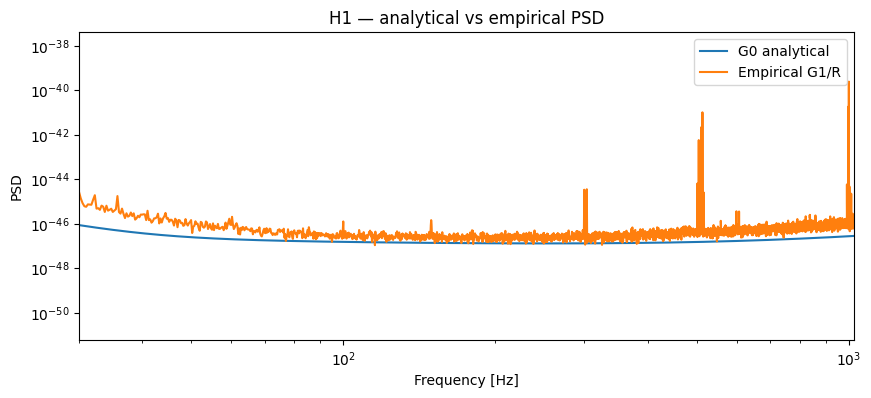

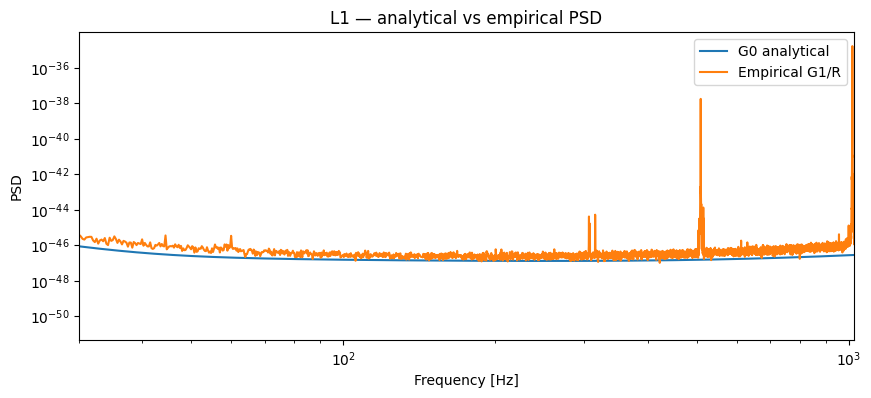

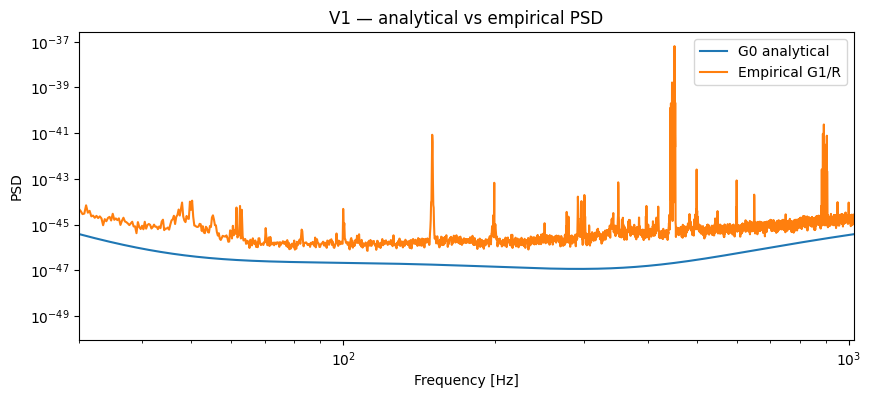

In [204]:
for ifo in M116_DETECTORS:

    psd_g0 = (
        psds_G0_snr_M116[
            ifo
        ]
    )

    psd_emp = (
        test_empirical_psds_M116[
            ifo
        ][
            "snr"
        ]
    )

    f_g0 = (
        np.arange(
            len(psd_g0)
        )
        * float(
            psd_g0.delta_f
        )
    )

    f_emp = (
        np.arange(
            len(psd_emp)
        )
        * float(
            psd_emp.delta_f
        )
    )

    fig, ax = plt.subplots(
        figsize=(10, 4)
    )

    ax.loglog(
        f_g0,
        psd_g0.numpy(),
        label="G0 analytical",
    )

    ax.loglog(
        f_emp,
        psd_emp.numpy(),
        label="Empirical G1/R",
    )

    ax.set_xlim(
        30,
        1024,
    )

    ax.set_xlabel(
        "Frequency [Hz]"
    )

    ax.set_ylabel(
        "PSD"
    )

    ax.set_title(
        f"{ifo} — analytical vs empirical PSD"
    )

    ax.legend()

    plt.show()

In [205]:
del test_strains_M116

gc.collect()

print(
    "Test real-strain environment released."
)

Test real-strain environment released.


In [206]:
def approximate_rms_from_psd_M116(
    psd,
    *,
    fmin=0.0,
):
    f = (
        np.arange(len(psd))
        * float(psd.delta_f)
    )

    values = np.asarray(
        psd,
        dtype=float,
    )

    mask = (
        np.isfinite(values)
        &
        (values >= 0.0)
        &
        (f >= float(fmin))
    )

    variance = (
        np.sum(
            values[mask]
        )
        *
        float(psd.delta_f)
    )

    return float(
        np.sqrt(variance)
    )

In [207]:
psd_scale_rows_M116 = []

for ifo in M116_DETECTORS:

    psd_rms = (
        approximate_rms_from_psd_M116(
            test_psds_emp_proc_M116[
                ifo
            ],
            fmin=0.0,
        )
    )

    real_std = float(
        np.std(
            test_noise_R_context_M116[
                ifo
            ]
        )
    )

    psd_scale_rows_M116.append({
        "detector":
            ifo,

        "real_crop_std":
            real_std,

        "psd_expected_rms":
            psd_rms,

        "ratio_psd_to_real":
            psd_rms
            /
            real_std,
    })

df_c2_psd_scale_sanity_M116 = (
    pd.DataFrame(
        psd_scale_rows_M116
    )
)

display(
    df_c2_psd_scale_sanity_M116
)

NameError: name 'test_psds_emp_proc_M116' is not defined

## M11.6-C2-B — Single-source paired geometry and SNR control

Before generating any dataset, one source is propagated through the
signal-generation pipeline and matched across G0, G1 and R.

The test verifies separately:

1. waveform generation;
2. physical H1/L1/V1 projection at the assigned real GPS epoch;
3. common network-window selection;
4. placement inside the assigned final 4 s detector segment;
5. domain-specific optimal-SNR rescaling.

The same source geometry and placement are used in all three domains.

The controlled target is

$$
\rho_i^\star,
$$

while luminosity distance is allowed to depend on the PSD domain.

Because G1 and R share exactly the same empirical PSD,

$$
d_{G1}=d_R
$$

up to numerical precision.

G0 uses the analytical detector PSDs and therefore generally requires a
different distance.

In [208]:
from src.windowing import (
    ProjectedNetworkWindowSelector,
)

from src.injection import (
    SignalInjector,
)

from src.parameters import (
    CBCParameters,
)

In [209]:
window_selector_M116 = (
    ProjectedNetworkWindowSelector(
        config=M116_C2_CONFIG
    )
)

injector_M116 = (
    SignalInjector(
        config=M116_C2_CONFIG,
        rng=np.random.default_rng(
            M116_C_MASTER_SEED + 100
        ),
    )
)

In [210]:
df_c2_test_candidates_M116 = (
    df_master_experiment_M116[
        (
            df_master_experiment_M116[
                "split"
            ] == "train"
        )
        &
        (
            df_master_experiment_M116[
                "chirp_mass"
            ].between(
                25.0,
                45.0,
            )
        )
        &
        (
            df_master_experiment_M116[
                "target_network_snr"
            ].between(
                14.0,
                20.0,
            )
        )
    ]
)

assert len(
    df_c2_test_candidates_M116
) > 0

test_source_row_M116 = (
    df_c2_test_candidates_M116
    .iloc[0]
)

display(
    test_source_row_M116[
        [
            "source_id",
            "mass_1",
            "mass_2",
            "spin_1z",
            "spin_2z",
            "chirp_mass",
            "chi_eff",
            "target_network_snr",
            "file_group_id",
            "block_id",
            "noise_crop_id",
            "center_gps",
            "processing_start",
            "processing_end",
        ]
    ]
)

source_id              M116_SRC_000007
mass_1                       42.182431
mass_2                       38.673128
spin_1z                      -0.129348
spin_2z                      -0.028717
chirp_mass                   35.154633
chi_eff                      -0.081216
target_network_snr           18.829708
file_group_id                       19
block_id                 M116_RB_00192
noise_crop_id           M116_RC_002891
center_gps            1265927129.40625
processing_start          1265927127.0
processing_end         1265927131.8125
Name: 7, dtype: object

In [211]:
test_params_ref_M116 = CBCParameters(
    mass_1=float(
        test_source_row_M116[
            "mass_1"
        ]
    ),

    mass_2=float(
        test_source_row_M116[
            "mass_2"
        ]
    ),

    distance=float(
        test_source_row_M116[
            "reference_distance_mpc"
        ]
    ),

    inclination=float(
        test_source_row_M116[
            "inclination"
        ]
    ),

    ra=float(
        test_source_row_M116[
            "ra"
        ]
    ),

    dec=float(
        test_source_row_M116[
            "dec"
        ]
    ),

    spin_1z=float(
        test_source_row_M116[
            "spin_1z"
        ]
    ),

    spin_2z=float(
        test_source_row_M116[
            "spin_2z"
        ]
    ),

    polarization_angle=float(
        test_source_row_M116[
            "polarization_angle"
        ]
    ),
)

In [212]:
assert np.isclose(
    test_params_ref_M116.chirp_mass,
    test_source_row_M116[
        "chirp_mass"
    ],
)

assert np.isclose(
    test_params_ref_M116.total_mass,
    test_source_row_M116[
        "total_mass"
    ],
)

assert np.isclose(
    test_params_ref_M116.chi_eff,
    test_source_row_M116[
        "chi_eff"
    ],
)

print(
    "Physical parameter reconstruction passed."
)

Physical parameter reconstruction passed.


In [213]:
#Real assigned segment
test_processing_start_M116 = float(
    test_source_row_M116[
        "processing_start"
    ]
)

test_processing_end_M116 = float(
    test_source_row_M116[
        "processing_end"
    ]
)

test_final_start_M116 = (
    test_processing_start_M116
    +
    M116_C2_CONFIG.processing_context_start_seconds
)

test_final_end_M116 = (
    test_final_start_M116
    +
    M116_C2_CONFIG.duration
)

test_final_center_M116 = (
    0.5
    * (
        test_final_start_M116
        +
        test_final_end_M116
    )
)

In [214]:
print(
    "Processing:",
    test_processing_start_M116,
    "->",
    test_processing_end_M116,
)

print(
    "Final 4 s:",
    test_final_start_M116,
    "->",
    test_final_end_M116,
)

print(
    "Final center:",
    test_final_center_M116,
)

print(
    "C1 center_gps:",
    float(
        test_source_row_M116[
            "center_gps"
        ]
    ),
)

Processing: 1265927127.0 -> 1265927131.8125
Final 4 s: 1265927127.40625 -> 1265927131.40625
Final center: 1265927129.40625
C1 center_gps: 1265927129.40625


In [215]:
assert np.isclose(
    (
        test_processing_end_M116
        -
        test_processing_start_M116
    ),
    M116_C2_CONFIG.processing_duration,
)

assert np.isclose(
    test_final_center_M116,
    float(
        test_source_row_M116[
            "center_gps"
        ]
    ),
)

print(
    "Assigned crop geometry passed."
)

Assigned crop geometry passed.


In [216]:
#Build ref GW
test_tgeo_provisional_M116 = (
    test_final_center_M116
)

test_waveform_ref_M116 = (
    waveform_generator_M116.generate(
        test_params_ref_M116
    )
)

In [217]:
print(
    "Waveform duration:",
    test_waveform_ref_M116.metadata.duration,
    "s",
)

print(
    "Waveform samples:",
    test_waveform_ref_M116.metadata.n_samples,
)

Waveform duration: 0.29248046875 s
Waveform samples: 1198


In [218]:
test_projection_ref_M116 = (
    detector_projector_M116.project(
        h_plus=(
            test_waveform_ref_M116.h_plus
        ),
        h_cross=(
            test_waveform_ref_M116.h_cross
        ),
        parameters=(
            test_params_ref_M116
        ),
        geocentric_coalescence_time=(
            test_tgeo_provisional_M116
        ),
    )
)

In [219]:
print(
    "Detector delays:"
)

for ifo in M116_DETECTORS:

    print(
        ifo,
        test_projection_ref_M116
        .metadata
        .expected_detector_time_delays[
            ifo
        ],
    )

Detector delays:
H1 -0.008702552306148416
L1 -0.0015143430544475702
V1 -0.012874318796042634


In [220]:
test_windowed_ref_M116 = (
    window_selector_M116.select(
        projected_strains=(
            test_projection_ref_M116.strains
        ),
        max_duration=(
            M116_C2_CONFIG.duration
        ),
    )
)

In [221]:
print(
    "Full network duration:",
    test_windowed_ref_M116
    .metadata
    .full_network_duration,
)

print(
    "Used duration:",
    test_windowed_ref_M116
    .metadata
    .used_window_duration,
)

print(
    "Truncated:",
    test_windowed_ref_M116
    .metadata
    .is_truncated,
)

Full network duration: 0.31982421875
Used duration: 0.31982421875
Truncated: False


In [222]:
test_abstract_placement_M116 = (
    injector_M116
    .choose_segment_placement_containing_network(
        signals=(
            test_windowed_ref_M116.strains
        ),

        placement_policy=(
            "random_contained"
        ),

        safe_margin_start=float(
            M116_C2_CONFIG.safe_margin_start
        ),

        safe_margin_end=float(
            M116_C2_CONFIG.safe_margin_end
        ),

        enforce_safe_margins=True,
    )
)

In [223]:
print(
    "Abstract segment:",
    test_abstract_placement_M116
    .segment_start_time,
    "->",
    test_abstract_placement_M116
    .segment_end_time,
)

print(
    "Signal network:",
    test_abstract_placement_M116
    .earliest_signal_start_time,
    "->",
    test_abstract_placement_M116
    .latest_signal_end_time,
)

print(
    "Margin before:",
    test_abstract_placement_M116
    .margin_before_signal,
)

print(
    "Margin after:",
    test_abstract_placement_M116
    .margin_after_signal,
)

Abstract segment: 1265927128.8290236 -> 1265927132.8290236
Signal network: 1265927129.2458496 -> 1265927129.5656738
Margin before: 0.4168260097503662
Margin after: 3.263349771499634


In [224]:
test_segment_shift_M116 = (
    test_final_start_M116
    -
    float(
        test_abstract_placement_M116
        .segment_start_time
    )
)

In [225]:
test_tgeo_final_M116 = (
    test_tgeo_provisional_M116
    +
    test_segment_shift_M116
)

In [226]:
print(
    "Provisional t_geo:",
    test_tgeo_provisional_M116,
)

print(
    "Placement shift:",
    test_segment_shift_M116,
)

print(
    "Final t_geo:",
    test_tgeo_final_M116,
)

print(
    "Offset from final center:",
    (
        test_tgeo_final_M116
        -
        test_final_center_M116
    ),
    "s",
)

Provisional t_geo: 1265927129.40625
Placement shift: -1.4227735996246338
Final t_geo: 1265927127.9834764
Offset from final center: -1.4227735996246338 s


In [227]:
test_projection_final_M116 = (
    detector_projector_M116.project(
        h_plus=(
            test_waveform_ref_M116.h_plus
        ),
        h_cross=(
            test_waveform_ref_M116.h_cross
        ),
        parameters=(
            test_params_ref_M116
        ),
        geocentric_coalescence_time=(
            test_tgeo_final_M116
        ),
    )
)

In [228]:
test_windowed_final_M116 = (
    window_selector_M116.select(
        projected_strains=(
            test_projection_final_M116.strains
        ),
        max_duration=(
            M116_C2_CONFIG.duration
        ),
    )
)

In [229]:
tol_M116 = (
    2.0
    * M116_C2_CONFIG.delta_t
)

network_start_M116 = (
    test_windowed_final_M116
    .metadata
    .used_window_start_time
)

network_end_M116 = (
    test_windowed_final_M116
    .metadata
    .used_window_end_time
)

In [230]:
print(
    "Final segment:",
    test_final_start_M116,
    "->",
    test_final_end_M116,
)

print(
    "Windowed signal:",
    network_start_M116,
    "->",
    network_end_M116,
)

Final segment: 1265927127.40625 -> 1265927131.40625
Windowed signal: 1265927127.822998 -> 1265927128.1430664


In [231]:
assert (
    network_start_M116
    >=
    test_final_start_M116
    -
    tol_M116
)

assert (
    network_end_M116
    <=
    test_final_end_M116
    +
    tol_M116
)

print(
    "Random-contained placement mapped "
    "onto physical crop successfully."
)

Random-contained placement mapped onto physical crop successfully.


In [232]:
#Zero segment for SNR
test_zero_final_M116 = {
    ifo:
        injector_M116.build_zero_strain(
            start_time=(
                test_final_start_M116
            ),
            length=(
                M116_C2_CONFIG.length
            ),
        )

    for ifo in M116_DETECTORS
}

In [233]:
test_signal_only_results_M116 = (
    injector_M116.inject_network(
        noises=(
            test_zero_final_M116
        ),
        signals=(
            test_windowed_final_M116
            .strains
        ),
    )
)

test_signal_segments_ref_M116 = {
    ifo:
        test_signal_only_results_M116[
            ifo
        ].strain

    for ifo in M116_DETECTORS
}

In [234]:
for ifo in M116_DETECTORS:

    assert (
        len(
            test_signal_segments_ref_M116[
                ifo
            ]
        )
        ==
        M116_C2_CONFIG.length
    )

    assert np.isclose(
        float(
            test_signal_segments_ref_M116[
                ifo
            ].start_time
        ),
        test_final_start_M116,
    )

print(
    "Reference signal-only network built."
)

Reference signal-only network built.


In [235]:
#Get back empirical PSD from THIS block
test_block_id_M116 = (
    test_source_row_M116[
        "block_id"
    ]
)

test_block_row_M116 = (
    df_psd_blocks_M116[
        df_psd_blocks_M116[
            "block_id"
        ]
        == test_block_id_M116
    ]
    .iloc[0]
)

test_group_id_M116 = int(
    test_block_row_M116[
        "file_group_id"
    ]
)

In [236]:
test_group_row_M116 = (
    df_unique_file_groups_M116[
        df_unique_file_groups_M116[
            "file_group_id"
        ]
        == test_group_id_M116
    ]
    .iloc[0]
)

test_real_long_strains_M116 = (
    load_file_group_strains_M116(
        test_group_row_M116
    )
)

Using cached file: H-H1_GWOSC_4KHZ_R1-1265924055-4096.hdf5
Using cached file: L-L1_GWOSC_4KHZ_R1-1265924055-4096.hdf5
Using cached file: V-V1_GWOSC_4KHZ_R1-1265924055-4096.hdf5


In [237]:
test_psds_emp_M116 = {}

for ifo in M116_DETECTORS:

    test_psds_emp_M116[
        ifo
    ] = (
        estimate_block_psds_for_detector_M116(
            strain=(
                test_real_long_strains_M116[
                    ifo
                ]
            ),

            psd_start=float(
                test_block_row_M116[
                    "psd_start"
                ]
            ),

            psd_end=float(
                test_block_row_M116[
                    "psd_end"
                ]
            ),
        )
    )

In [238]:
test_psds_emp_snr_M116 = {
    ifo:
        test_psds_emp_M116[ifo]["snr"]
    for ifo in M116_DETECTORS
}

test_psds_emp_proc_M116 = {
    ifo:
        test_psds_emp_M116[ifo]["proc"]
    for ifo in M116_DETECTORS
}

In [239]:
#Calcular SNR inicial bajo G0 y empirical
test_snrs_G0_det_ref_M116, \
test_snr_G0_net_ref_M116 = (
    compute_network_optimal_snr(
        signal_segments=(
            test_signal_segments_ref_M116
        ),
        psds=(
            psds_G0_snr_M116
        ),
        config=(
            M116_C2_CONFIG
        ),
    )
)

In [240]:
test_snrs_emp_det_ref_M116, \
test_snr_emp_net_ref_M116 = (
    compute_network_optimal_snr(
        signal_segments=(
            test_signal_segments_ref_M116
        ),
        psds=(
            test_psds_emp_snr_M116
        ),
        config=(
            M116_C2_CONFIG
        ),
    )
)

In [241]:
print(
    "Reference distance:",
    test_params_ref_M116.distance,
    "Mpc",
)

print(
    "G0 network SNR:",
    test_snr_G0_net_ref_M116,
)

print(
    "Empirical network SNR:",
    test_snr_emp_net_ref_M116,
)

print(
    "Target:",
    float(
        test_source_row_M116[
            "target_network_snr"
        ]
    ),
)

Reference distance: 1000.0 Mpc
G0 network SNR: 18.99483618856231
Empirical network SNR: 11.441201419656691
Target: 18.82970814701761


In [242]:
test_target_snr_M116 = float(
    test_source_row_M116[
        "target_network_snr"
    ]
)

In [243]:
test_distance_G0_M116 = (
    rescale_distance_for_target_network_snr(
        current_distance=(
            test_params_ref_M116.distance
        ),

        current_network_snr=(
            test_snr_G0_net_ref_M116
        ),

        target_network_snr=(
            test_target_snr_M116
        ),
    )
)

test_distance_emp_M116 = (
    rescale_distance_for_target_network_snr(
        current_distance=(
            test_params_ref_M116.distance
        ),

        current_network_snr=(
            test_snr_emp_net_ref_M116
        ),

        target_network_snr=(
            test_target_snr_M116
        ),
    )
)

In [244]:
print(
    "d_G0:",
    test_distance_G0_M116,
    "Mpc",
)

print(
    "d_G1:",
    test_distance_emp_M116,
    "Mpc",
)

print(
    "d_R :",
    test_distance_emp_M116,
    "Mpc",
)

d_G0: 1008.7695486438463 Mpc
d_G1: 607.6143788489273 Mpc
d_R : 607.6143788489273 Mpc


In [245]:
test_distance_G1_M116 = (
    test_distance_emp_M116
)

test_distance_R_M116 = (
    test_distance_emp_M116
)

assert np.isclose(
    test_distance_G1_M116,
    test_distance_R_M116,
)

In [246]:
#Regeneramos las dos señales: una para G0  y otra para G1/R
test_params_G0_M116 = (
    test_params_ref_M116.with_distance(
        test_distance_G0_M116
    )
)

test_params_emp_M116 = (
    test_params_ref_M116.with_distance(
        test_distance_emp_M116
    )
)

In [247]:
def build_final_signal_segments_M116( #Para evitar duplicacion :)
    params,
    *,
    geocentric_time,
    final_start,
):
    waveform = (
        waveform_generator_M116.generate(
            params
        )
    )

    projection = (
        detector_projector_M116.project(
            h_plus=waveform.h_plus,
            h_cross=waveform.h_cross,
            parameters=params,
            geocentric_coalescence_time=(
                geocentric_time
            ),
        )
    )

    windowed = (
        window_selector_M116.select(
            projected_strains=(
                projection.strains
            ),
            max_duration=(
                M116_C2_CONFIG.duration
            ),
        )
    )

    zeros = {
        ifo:
            injector_M116.build_zero_strain(
                start_time=final_start,
                length=(
                    M116_C2_CONFIG.length
                ),
            )

        for ifo in M116_DETECTORS
    }

    injected = (
        injector_M116.inject_network(
            noises=zeros,
            signals=windowed.strains,
        )
    )

    segments = {
        ifo:
            injected[ifo].strain

        for ifo in M116_DETECTORS
    }

    return {
        "waveform":
            waveform,

        "projection":
            projection,

        "windowed":
            windowed,

        "segments":
            segments,
    }

In [248]:
test_signal_G0_M116 = (
    build_final_signal_segments_M116(
        test_params_G0_M116,

        geocentric_time=(
            test_tgeo_final_M116
        ),

        final_start=(
            test_final_start_M116
        ),
    )
)

In [249]:
test_signal_emp_M116 = (
    build_final_signal_segments_M116(
        test_params_emp_M116,

        geocentric_time=(
            test_tgeo_final_M116
        ),

        final_start=(
            test_final_start_M116
        ),
    )
)

In [250]:
#Check final SNR
test_snrs_G0_det_final_M116, \
test_snr_G0_net_final_M116 = (
    compute_network_optimal_snr(
        signal_segments=(
            test_signal_G0_M116[
                "segments"
            ]
        ),

        psds=(
            psds_G0_snr_M116
        ),

        config=(
            M116_C2_CONFIG
        ),
    )
)

In [251]:
test_snrs_emp_det_final_M116, \
test_snr_emp_net_final_M116 = (
    compute_network_optimal_snr(
        signal_segments=(
            test_signal_emp_M116[
                "segments"
            ]
        ),

        psds=(
            test_psds_emp_snr_M116
        ),

        config=(
            M116_C2_CONFIG
        ),
    )
)

In [252]:
print(
    "Target:",
    test_target_snr_M116,
)

print(
    "G0 final:",
    test_snr_G0_net_final_M116,
)

print(
    "G1 final:",
    test_snr_emp_net_final_M116,
)

print(
    "R  final:",
    test_snr_emp_net_final_M116,
)

Target: 18.82970814701761
G0 final: 18.82970814701762
G1 final: 18.82970814701761
R  final: 18.82970814701761


In [253]:
validate_snr_rescaling(
    final_network_snr=(
        test_snr_G0_net_final_M116
    ),

    target_network_snr=(
        test_target_snr_M116
    ),

    relative_tolerance=(
        M116_C2_CONFIG.snr_relative_tolerance
    ),
)

validate_snr_rescaling(
    final_network_snr=(
        test_snr_emp_net_final_M116
    ),

    target_network_snr=(
        test_target_snr_M116
    ),

    relative_tolerance=(
        M116_C2_CONFIG.snr_relative_tolerance
    ),
)

print(
    "Single-source SNR matching passed."
)

Single-source SNR matching passed.


In [254]:
assert np.isclose(
    test_distance_G1_M116,
    test_distance_R_M116,
)

assert np.isclose(
    test_snr_emp_net_final_M116,
    test_target_snr_M116,
    rtol=(
        M116_C2_CONFIG
        .snr_relative_tolerance
    ),
)

print(
    "G1/R signal-control identity passed."
)

G1/R signal-control identity passed.


In [255]:
#Summary
df_c2_single_source_snr_M116 = (
    pd.DataFrame([
        {
            "domain":
                "G0",

            "distance_mpc":
                test_distance_G0_M116,

            "network_snr":
                test_snr_G0_net_final_M116,

            "H1_snr":
                test_snrs_G0_det_final_M116[
                    "H1"
                ],

            "L1_snr":
                test_snrs_G0_det_final_M116[
                    "L1"
                ],

            "V1_snr":
                test_snrs_G0_det_final_M116[
                    "V1"
                ],
        },

        {
            "domain":
                "G1",

            "distance_mpc":
                test_distance_G1_M116,

            "network_snr":
                test_snr_emp_net_final_M116,

            "H1_snr":
                test_snrs_emp_det_final_M116[
                    "H1"
                ],

            "L1_snr":
                test_snrs_emp_det_final_M116[
                    "L1"
                ],

            "V1_snr":
                test_snrs_emp_det_final_M116[
                    "V1"
                ],
        },

        {
            "domain":
                "R",

            "distance_mpc":
                test_distance_R_M116,

            "network_snr":
                test_snr_emp_net_final_M116,

            "H1_snr":
                test_snrs_emp_det_final_M116[
                    "H1"
                ],

            "L1_snr":
                test_snrs_emp_det_final_M116[
                    "L1"
                ],

            "V1_snr":
                test_snrs_emp_det_final_M116[
                    "V1"
                ],
        },
    ])
)

display(
    df_c2_single_source_snr_M116
)

,domain,distance_mpc,network_snr,H1_snr,L1_snr,V1_snr
0,G0,1008.769549,18.829708,10.919470,9.944679,11.680173
1,G1,607.614379,18.829708,12.222393,12.161621,7.567429
2,R,607.614379,18.829708,12.222393,12.161621,7.567429


## M11.6-C2-C — Single-source full G0/G1/R construction

The signal-only geometry and optimal-SNR control were validated in C2-B.

C2-C now adds the three noise domains and propagates the same source through
the complete model-input pipeline.

The domains are

$$
G0 = h_{G0} + n_{\rm Gaussian}(S_n^{\rm analytical}),
$$

$$
G1 = h_{\rm emp} + n_{\rm Gaussian}(S_n^{\rm empirical}),
$$

and

$$
R = h_{\rm emp} + n_{\rm real}.
$$

G0 and G1 use common Gaussian random seeds detector by detector, so their
difference is driven primarily by the PSD model rather than unrelated random
noise phases.

G1 and R use the same empirical PSD estimated from the same off-source
reference interval.

All three domains use:

- the same astrophysical source identity;
- the same sky geometry;
- the same physical GPS epoch;
- the same random-contained placement;
- the same target network optimal SNR;
- full projected GW injection into the processing context;
- the same whitening/filtering pipeline;
- the same final 4 s crop;
- the same M10 per-sample/per-detector z-score normalization.

In [256]:
from pycbc.noise import gaussian
from pycbc.types import TimeSeries

from src.processing import SignalProcessor

from src.models.dataset import (
    normalize_input_per_sample_per_detector_zscore,
)

In [257]:
processor_M116 = SignalProcessor(
    config=M116_C2_CONFIG,

    whitening_method="psd",

    apply_highpass=True,
    apply_lowpass=True,
    apply_standardization=False,

    output_mode="crop_to_config",

    whitening_low_frequency_cutoff=30.0,
    whitening_max_filter_duration=0.5,
    whitening_trunc_method="hann",

    highpass_frequency=30.0,
    lowpass_frequency=512.0,

    fir_order=256,
    fir_beta=5.0,

    remove_corrupted=True,

    rng=np.random.default_rng(
        M116_C_MASTER_SEED + 300
    ),
)

In [258]:
display(
    pd.Series(
        processor_M116.metadata()
    )
)

whitening_method                                                                        psd
apply_lowpass                                                                          True
apply_highpass                                                                         True
apply_standardization                                                                 False
lowpass_frequency                                                                     512.0
highpass_frequency                                                                     30.0
whitening_low_frequency_cutoff                                                         30.0
whitening_max_filter_duration                                                           0.5
whitening_trunc_method                                                                 hann
fir_order                                                                               256
fir_beta                                                                        

In [259]:
assert (
    processor_M116.whitening_method
    == "psd"
)

assert (
    processor_M116.output_mode
    == "crop_to_config"
)

assert processor_M116.apply_highpass
assert processor_M116.apply_lowpass

assert np.isclose(
    processor_M116.highpass_frequency,
    30.0,
)

assert np.isclose(
    processor_M116.lowpass_frequency,
    512.0,
)

print(
    "M10 processing configuration reproduced."
)

M10 processing configuration reproduced.


In [260]:
def extract_exact_processing_context_M116(
    strain,
    *,
    start_time,
    expected_length,
):
    dt = float(
        strain.delta_t
    )

    source_start = float(
        strain.start_time
    )

    start_index_float = (
        (
            float(start_time)
            -
            source_start
        )
        /
        dt
    )

    start_index = int(
        round(
            start_index_float
        )
    )

    reconstructed_start = (
        source_start
        +
        start_index
        * dt
    )

    if not np.isclose(
        reconstructed_start,
        float(start_time),
        atol=0.51 * dt,
        rtol=0.0,
    ):
        raise ValueError(
            "Requested processing start is not "
            "aligned with strain sampling grid. "
            f"requested={start_time}, "
            f"reconstructed={reconstructed_start}"
        )

    end_index = (
        start_index
        +
        int(expected_length)
    )

    if (
        start_index < 0
        or
        end_index > len(strain)
    ):
        raise ValueError(
            "Requested processing interval "
            "outside available strain."
        )

    out = (
        strain[
            start_index:end_index
        ]
        .copy()
    )

    out.start_time = (
        reconstructed_start
    )

    return out

In [261]:
test_noise_R_context_M116 = {
    ifo:
        extract_exact_processing_context_M116(
            test_real_long_strains_M116[
                ifo
            ],

            start_time=(
                test_processing_start_M116
            ),

            expected_length=(
                M116_C2_CONFIG.processing_length
            ),
        )

    for ifo in M116_DETECTORS
}

In [262]:
for ifo in M116_DETECTORS:

    ts = (
        test_noise_R_context_M116[
            ifo
        ]
    )

    print(
        ifo,
        "len=",
        len(ts),
        "start=",
        float(ts.start_time),
        "std=",
        float(
            np.std(
                ts.numpy()
            )
        ),
    )

    assert (
        len(ts)
        ==
        M116_C2_CONFIG.processing_length
    )

    assert np.isclose(
        float(
            ts.start_time
        ),
        test_processing_start_M116,
        atol=(
            0.51
            *
            M116_C2_CONFIG.delta_t
        ),
        rtol=0.0,
    )

    assert np.all(
        np.isfinite(
            ts.numpy()
        )
    )

print(
    "Real R processing context extracted."
)

H1 len= 19712 start= 1265927127.0 std= 4.541657883405538e-20
L1 len= 19712 start= 1265927127.0 std= 7.818825657544616e-19
V1 len= 19712 start= 1265927127.0 std= 1.308587655323984e-19
Real R processing context extracted.


In [263]:
rng_common_gaussian_M116 = (
    np.random.default_rng(
        M116_C_MASTER_SEED + 400
    )
)

test_gaussian_seeds_M116 = {
    ifo:
        int(
            rng_common_gaussian_M116.integers(
                0,
                2**32 - 1,
            )
        )

    for ifo in M116_DETECTORS
}

test_gaussian_seeds_M116

{'H1': 1207670483, 'L1': 34288475, 'V1': 3002532292}

In [264]:
test_noise_G0_context_M116 = {}

for ifo in M116_DETECTORS:

    noise = (
        gaussian.noise_from_psd(
            psd=(
                psds_G0_proc_M116[
                    ifo
                ]
            ),

            length=(
                M116_C2_CONFIG.processing_length
            ),

            delta_t=(
                M116_C2_CONFIG.delta_t
            ),

            seed=(
                test_gaussian_seeds_M116[
                    ifo
                ]
            ),
        )
    )

    noise = (
        injector_M116
        .set_strain_start_time(
            strain=noise,

            start_time=(
                test_processing_start_M116
            ),

            expected_length=(
                M116_C2_CONFIG.processing_length
            ),
        )
    )

    test_noise_G0_context_M116[
        ifo
    ] = noise

In [265]:
test_noise_G1_context_M116 = {}

for ifo in M116_DETECTORS:

    noise = (
        gaussian.noise_from_psd(
            psd=(
                test_psds_emp_proc_M116[
                    ifo
                ]
            ),

            length=(
                M116_C2_CONFIG.processing_length
            ),

            delta_t=(
                M116_C2_CONFIG.delta_t
            ),

            seed=(
                test_gaussian_seeds_M116[
                    ifo
                ]
            ),
        )
    )

    noise = (
        injector_M116
        .set_strain_start_time(
            strain=noise,

            start_time=(
                test_processing_start_M116
            ),

            expected_length=(
                M116_C2_CONFIG.processing_length
            ),
        )
    )

    test_noise_G1_context_M116[
        ifo
    ] = noise

In [266]:
raw_noise_scale_rows_M116 = []

for domain, network in [
    (
        "G0",
        test_noise_G0_context_M116,
    ),
    (
        "G1",
        test_noise_G1_context_M116,
    ),
    (
        "R",
        test_noise_R_context_M116,
    ),
]:

    for ifo in M116_DETECTORS:

        arr = np.asarray(
            network[ifo]
        )

        raw_noise_scale_rows_M116.append({
            "domain":
                domain,

            "detector":
                ifo,

            "mean":
                float(
                    np.mean(arr)
                ),

            "std":
                float(
                    np.std(arr)
                ),

            "max_abs":
                float(
                    np.max(
                        np.abs(arr)
                    )
                ),
        })

df_c2_raw_noise_scales_M116 = (
    pd.DataFrame(
        raw_noise_scale_rows_M116
    )
)

display(
    df_c2_raw_noise_scales_M116
)

,domain,detector,mean,std,max_abs
0,G0,H1,-2.658392e-26,2.669422e-22,1.119301e-21
1,G0,L1,6.028995e-26,2.650713e-22,1.129132e-21
2,G0,V1,-2.451264e-26,1.190133e-21,4.612265e-21
3,G1,H1,3.479468e-22,4.885268e-20,1.220293e-19
4,G1,L1,-1.305667e-21,7.201749e-19,1.709533e-18
5,G1,V1,5.662717e-22,1.794310e-19,4.240998e-19
6,R,H1,3.553214e-23,4.541658e-20,1.130935e-19
7,R,L1,-5.379626e-21,7.818826e-19,2.142273e-18
8,R,V1,1.594950e-22,1.308588e-19,3.121698e-19


In [267]:
for ifo in M116_DETECTORS:

    x = np.asarray(
        test_noise_G0_context_M116[
            ifo
        ]
    )

    y = np.asarray(
        test_noise_G1_context_M116[
            ifo
        ]
    )

    corr = np.corrcoef(
        x,
        y,
    )[0, 1]

    print(
        ifo,
        "G0/G1 raw correlation:",
        corr,
    )

H1 G0/G1 raw correlation: 0.01353593417962622
L1 G0/G1 raw correlation: 0.0004400027838136176
V1 G0/G1 raw correlation: 0.007476549051562363


In [268]:
#G0
test_injected_G0_results_M116 = (
    injector_M116.inject_network(
        noises=(
            test_noise_G0_context_M116
        ),

        signals=(
            test_signal_G0_M116[
                "projection"
            ].strains
        ),
    )
)

In [269]:
#G1
test_injected_G1_results_M116 = (
    injector_M116.inject_network(
        noises=(
            test_noise_G1_context_M116
        ),

        signals=(
            test_signal_emp_M116[
                "projection"
            ].strains
        ),
    )
)

In [270]:
#R
test_injected_R_results_M116 = (
    injector_M116.inject_network(
        noises=(
            test_noise_R_context_M116
        ),

        signals=(
            test_signal_emp_M116[
                "projection"
            ].strains
        ),
    )
)

In [271]:
injection_audit_rows_M116 = []

for domain, results in [
    (
        "G0",
        test_injected_G0_results_M116,
    ),
    (
        "G1",
        test_injected_G1_results_M116,
    ),
    (
        "R",
        test_injected_R_results_M116,
    ),
]:

    for ifo in M116_DETECTORS:

        r = results[ifo]

        injection_audit_rows_M116.append({
            "domain":
                domain,

            "detector":
                ifo,

            "n_signal_samples":
                int(
                    r.n_signal_samples
                ),

            "n_injected_samples":
                int(
                    r.n_injected_samples
                ),

            "n_clipped_before":
                int(
                    r.n_clipped_before
                ),

            "n_clipped_after":
                int(
                    r.n_clipped_after
                ),

            "is_partially_clipped":
                bool(
                    r.is_partially_clipped
                ),
        })

df_c2_injection_audit_M116 = (
    pd.DataFrame(
        injection_audit_rows_M116
    )
)

display(
    df_c2_injection_audit_M116
)

,domain,detector,n_signal_samples,n_injected_samples,n_clipped_before,n_clipped_after,is_partially_clipped
0,G0,H1,1264,1264,0,0,False
1,G0,L1,1264,1264,0,0,False
2,G0,V1,1265,1265,0,0,False
3,G1,H1,1264,1264,0,0,False
4,G1,L1,1264,1264,0,0,False
5,G1,V1,1265,1265,0,0,False
6,R,H1,1264,1264,0,0,False
7,R,L1,1264,1264,0,0,False
8,R,V1,1265,1265,0,0,False


In [272]:
test_injected_G0_M116 = {
    ifo:
        test_injected_G0_results_M116[
            ifo
        ].strain

    for ifo in M116_DETECTORS
}

test_injected_G1_M116 = {
    ifo:
        test_injected_G1_results_M116[
            ifo
        ].strain

    for ifo in M116_DETECTORS
}

test_injected_R_M116 = {
    ifo:
        test_injected_R_results_M116[
            ifo
        ].strain

    for ifo in M116_DETECTORS
}

Processing

In [273]:
test_processed_G0_M116 = (
    processor_M116.process_network(
        strains=(
            test_injected_G0_M116
        ),

        psds=(
            psds_G0_proc_M116
        ),
    )
)

In [274]:
test_processed_G1_M116 = (
    processor_M116.process_network(
        strains=(
            test_injected_G1_M116
        ),

        psds=(
            test_psds_emp_proc_M116
        ),
    )
)

In [275]:
test_processed_R_M116 = (
    processor_M116.process_network(
        strains=(
            test_injected_R_M116
        ),

        psds=(
            test_psds_emp_proc_M116
        ),
    )
)

In [276]:
for domain, network in [
    (
        "G0",
        test_processed_G0_M116,
    ),
    (
        "G1",
        test_processed_G1_M116,
    ),
    (
        "R",
        test_processed_R_M116,
    ),
]:

    for ifo in M116_DETECTORS:

        ts = network[ifo]

        assert (
            len(ts)
            ==
            M116_C2_CONFIG.length
        )

        assert np.isclose(
            float(
                ts.start_time
            ),
            test_final_start_M116,
            atol=(
                2
                *
                M116_C2_CONFIG.delta_t
            ),
            rtol=0.0,
        )

        assert np.all(
            np.isfinite(
                ts.numpy()
            )
        )

print(
    "Processed G0/G1/R output contracts passed."
)

Processed G0/G1/R output contracts passed.


In [277]:
def stack_detector_network_M116(
    network,
):
    return np.stack(
        [
            np.asarray(
                network[ifo]
            )
            for ifo
            in M116_DETECTORS
        ],
        axis=0,
    )

In [278]:
test_X_G0_raw_M116 = (
    stack_detector_network_M116(
        test_processed_G0_M116
    )
)

test_X_G1_raw_M116 = (
    stack_detector_network_M116(
        test_processed_G1_M116
    )
)

test_X_R_raw_M116 = (
    stack_detector_network_M116(
        test_processed_R_M116
    )
)

In [279]:
for name, X in [
    (
        "G0",
        test_X_G0_raw_M116,
    ),
    (
        "G1",
        test_X_G1_raw_M116,
    ),
    (
        "R",
        test_X_R_raw_M116,
    ),
]:

    print(
        name,
        X.shape,
        X.dtype,
    )

    assert (
        X.shape
        ==
        (
            3,
            16384,
        )
    )

    assert np.all(
        np.isfinite(X)
    )

print(
    "CNN raw-input geometry passed."
)

G0 (3, 16384) float64
G1 (3, 16384) float64
R (3, 16384) float64
CNN raw-input geometry passed.


Mirar escalas DESPUÉS del processing pero ANTES del z-score

In [280]:
processed_scale_rows_M116 = []

for domain, X in [
    (
        "G0",
        test_X_G0_raw_M116,
    ),
    (
        "G1",
        test_X_G1_raw_M116,
    ),
    (
        "R",
        test_X_R_raw_M116,
    ),
]:

    for i, ifo in enumerate(
        M116_DETECTORS
    ):

        processed_scale_rows_M116.append({
            "domain":
                domain,

            "detector":
                ifo,

            "mean":
                float(
                    X[i].mean()
                ),

            "std":
                float(
                    X[i].std()
                ),

            "rms":
                float(
                    np.sqrt(
                        np.mean(
                            X[i]**2
                        )
                    )
                ),

            "max_abs":
                float(
                    np.max(
                        np.abs(
                            X[i]
                        )
                    )
                ),
        })

df_c2_processed_scales_M116 = (
    pd.DataFrame(
        processed_scale_rows_M116
    )
)

display(
    df_c2_processed_scales_M116
)

,domain,detector,mean,std,rms,max_abs
0,G0,H1,-0.011712,21.945474,21.945477,93.127677
1,G0,L1,-0.001150,21.897454,21.897454,100.868602
2,G0,V1,-0.002489,21.715420,21.715420,90.774010
3,G1,H1,-0.029766,85.697442,85.697447,264.133416
4,G1,L1,-0.001676,25.688153,25.688153,186.308173
5,G1,V1,-0.007605,62.117904,62.117904,226.545011
6,R,H1,0.017790,58.609478,58.609481,189.016137
7,R,L1,-0.015938,23.438700,23.438705,101.759625
8,R,V1,0.010604,59.682648,59.682649,229.403080


Aplicar EXACTAMENTE el z-score M10

In [281]:
M116_M10_INPUT_ZSCORE_EPS = 1e-6

In [282]:
test_X_G0_M116 = (
    normalize_input_per_sample_per_detector_zscore(
        test_X_G0_raw_M116,
        eps=(
            M116_M10_INPUT_ZSCORE_EPS
        ),
    )
)

test_X_G1_M116 = (
    normalize_input_per_sample_per_detector_zscore(
        test_X_G1_raw_M116,
        eps=(
            M116_M10_INPUT_ZSCORE_EPS
        ),
    )
)

test_X_R_M116 = (
    normalize_input_per_sample_per_detector_zscore(
        test_X_R_raw_M116,
        eps=(
            M116_M10_INPUT_ZSCORE_EPS
        ),
    )
)

In [283]:
for domain, X in [
    (
        "G0",
        test_X_G0_M116,
    ),
    (
        "G1",
        test_X_G1_M116,
    ),
    (
        "R",
        test_X_R_M116,
    ),
]:

    print(
        "\n",
        domain,
    )

    print(
        "means:",
        X.mean(
            axis=1
        ),
    )

    print(
        "stds:",
        X.std(
            axis=1
        ),
    )

    assert (
        X.dtype
        ==
        np.float32
    )

    assert np.all(
        np.isfinite(X)
    )

    assert np.allclose(
        X.mean(axis=1),
        0.0,
        atol=1e-5,
    )

print(
    "\nM10 input-normalization contracts passed."
)


 G0
means: [3.7834980e-10 1.4551915e-10 2.6193447e-10]
stds: [0.99999994 0.99999994 0.99999994]

 G1
means: [-2.8230716e-09  1.5133992e-09  6.2573235e-10]
stds: [1.         0.99999994 1.        ]

 R
means: [8.7311491e-10 1.2514647e-09 4.3655746e-10]
stds: [1.         0.99999994 0.99999994]

M10 input-normalization contracts passed.


In [284]:
paired_input_rows_M116 = []

for domain, X, distance in [
    (
        "G0",
        test_X_G0_M116,
        test_distance_G0_M116,
    ),
    (
        "G1",
        test_X_G1_M116,
        test_distance_G1_M116,
    ),
    (
        "R",
        test_X_R_M116,
        test_distance_R_M116,
    ),
]:

    row = {
        "source_id":
            test_source_row_M116[
                "source_id"
            ],

        "domain":
            domain,

        "distance_mpc":
            float(
                distance
            ),

        "target_network_snr":
            float(
                test_target_snr_M116
            ),
    }

    for i, ifo in enumerate(
        M116_DETECTORS
    ):

        row[
            f"{ifo}_mean"
        ] = float(
            X[i].mean()
        )

        row[
            f"{ifo}_std"
        ] = float(
            X[i].std()
        )

        row[
            f"{ifo}_max_abs"
        ] = float(
            np.max(
                np.abs(
                    X[i]
                )
            )
        )

    paired_input_rows_M116.append(
        row
    )

df_c2_paired_input_M116 = (
    pd.DataFrame(
        paired_input_rows_M116
    )
)

display(
    df_c2_paired_input_M116
)

,source_id,domain,distance_mpc,target_network_snr,H1_mean,H1_std,H1_max_abs,L1_mean,L1_std,L1_max_abs,V1_mean,V1_std,V1_max_abs
0,M116_SRC_000007,G0,1008.769549,18.829708,3.783498e-10,1.0,4.244127,1.455192e-10,1.0,4.606355,2.619345e-10,1.0,4.180049
1,M116_SRC_000007,G1,607.614379,18.829708,-2.823072e-09,1.0,3.081815,1.513399e-09,1.0,7.252623,6.257324e-10,1.0,3.647139
2,M116_SRC_000007,R,607.614379,18.829708,8.731149e-10,1.0,3.224706,1.251465e-09,1.0,4.342202,4.365575e-10,1.0,3.843892


Comparación directa entre dominios

$$
​\frac{∥X_A​−X_B​∥_2}{∥X_A​∥_2}​​
$$

In [285]:
def relative_input_distance_M116(
    Xa,
    Xb,
):
    return float(
        np.linalg.norm(
            Xa - Xb
        )
        /
        np.linalg.norm(
            Xa
        )
    )

In [286]:
print(
    "G0 -> G1 relative distance:",
    relative_input_distance_M116(
        test_X_G0_M116,
        test_X_G1_M116,
    )
)

print(
    "G1 -> R relative distance:",
    relative_input_distance_M116(
        test_X_G1_M116,
        test_X_R_M116,
    )
)

print(
    "G0 -> R relative distance:",
    relative_input_distance_M116(
        test_X_G0_M116,
        test_X_R_M116,
    )
)

G0 -> G1 relative distance: 0.9554653763771057
G1 -> R relative distance: 1.3938391208648682
G0 -> R relative distance: 1.4063266515731812


In [287]:
domain_pairs_M116 = [
    (
        "G0",
        test_X_G0_M116,
        "G1",
        test_X_G1_M116,
    ),
    (
        "G1",
        test_X_G1_M116,
        "R",
        test_X_R_M116,
    ),
    (
        "G0",
        test_X_G0_M116,
        "R",
        test_X_R_M116,
    ),
]

In [288]:
corr_rows_M116 = []

for (
    name_a,
    Xa,
    name_b,
    Xb,
) in domain_pairs_M116:

    for i, ifo in enumerate(
        M116_DETECTORS
    ):

        corr = float(
            np.corrcoef(
                Xa[i],
                Xb[i],
            )[0, 1]
        )

        corr_rows_M116.append({
            "pair":
                f"{name_a}-{name_b}",

            "detector":
                ifo,

            "correlation":
                corr,
        })

df_c2_domain_correlations_M116 = (
    pd.DataFrame(
        corr_rows_M116
    )
)

display(
    df_c2_domain_correlations_M116
)

,pair,detector,correlation
0,G0-G1,H1,0.289009
1,G0-G1,L1,0.885140
2,G0-G1,V1,0.456480
3,G1-R,H1,0.019885
4,G1-R,L1,0.029805
5,G1-R,V1,0.036128
6,G0-R,H1,0.003271
7,G0-R,L1,0.016119
8,G0-R,V1,0.013977


In [289]:
time_axis_M116 = (
    np.arange(
        M116_C2_CONFIG.length
    )
    /
    M116_C2_CONFIG.sampling_frequency
)

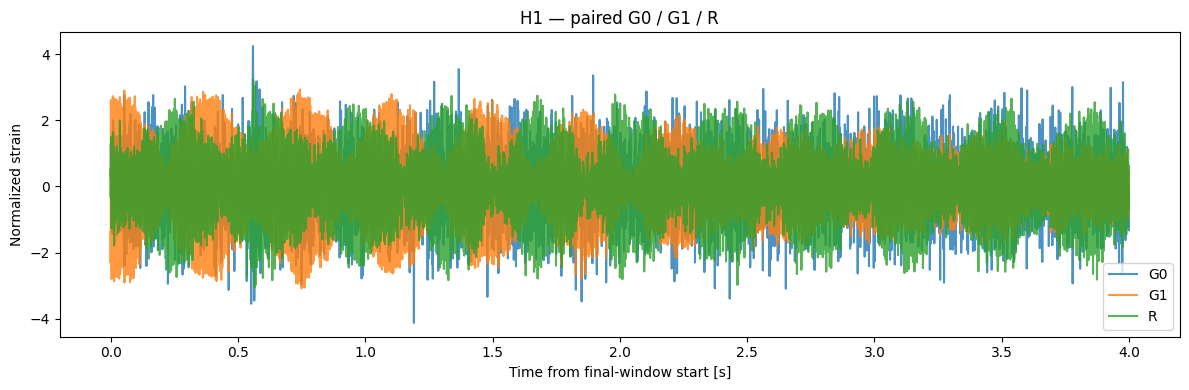

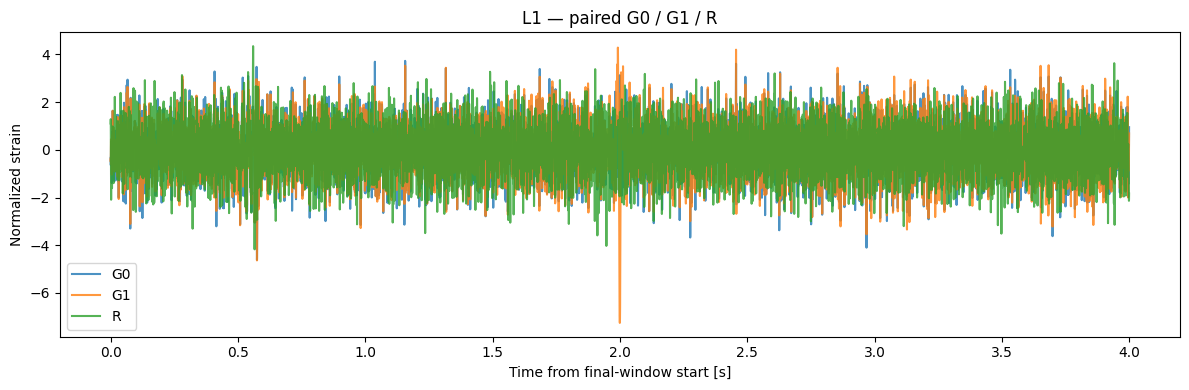

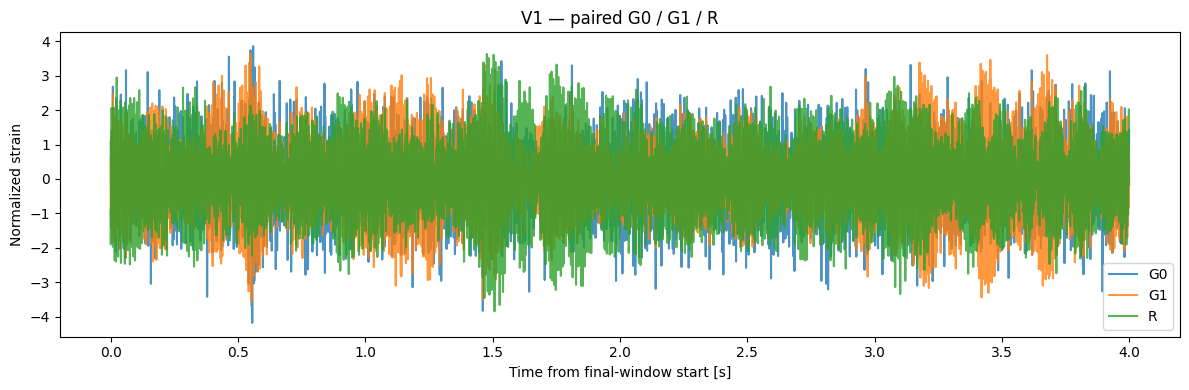

In [290]:
for i, ifo in enumerate(
    M116_DETECTORS
):

    fig, ax = plt.subplots(
        figsize=(12, 4)
    )

    ax.plot(
        time_axis_M116,
        test_X_G0_M116[i],
        label="G0",
        alpha=0.8,
    )

    ax.plot(
        time_axis_M116,
        test_X_G1_M116[i],
        label="G1",
        alpha=0.8,
    )

    ax.plot(
        time_axis_M116,
        test_X_R_M116[i],
        label="R",
        alpha=0.8,
    )

    ax.set_xlabel(
        "Time from final-window start [s]"
    )

    ax.set_ylabel(
        "Normalized strain"
    )

    ax.set_title(
        f"{ifo} — paired G0 / G1 / R"
    )

    ax.legend()

    plt.tight_layout()
    plt.show()

In [291]:
#Zoom around signal
gw_start_relative_M116 = (
    network_start_M116
    -
    test_final_start_M116
)

gw_end_relative_M116 = (
    network_end_M116
    -
    test_final_start_M116
)

In [292]:
plot_start_M116 = max(
    0.0,
    gw_start_relative_M116
    - 0.25,
)

plot_end_M116 = min(
    4.0,
    gw_end_relative_M116
    + 0.25,
)

mask_zoom_M116 = (
    (time_axis_M116 >= plot_start_M116)
    &
    (time_axis_M116 <= plot_end_M116)
)

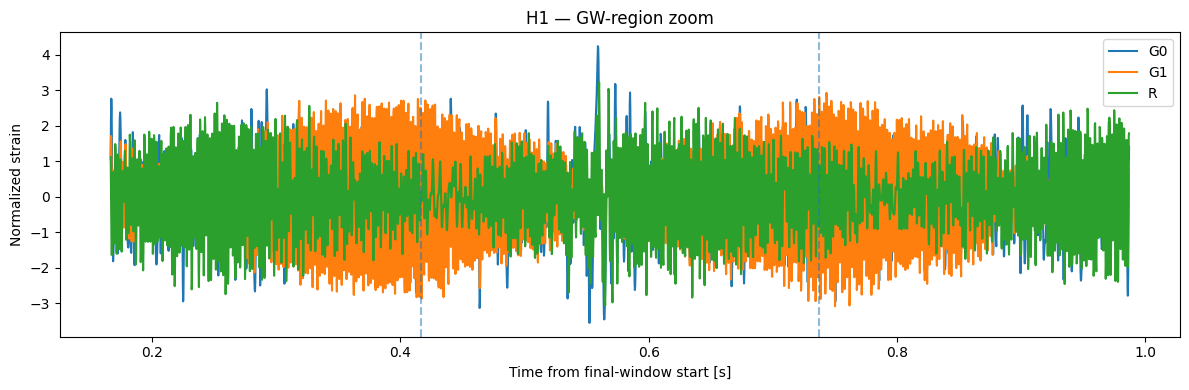

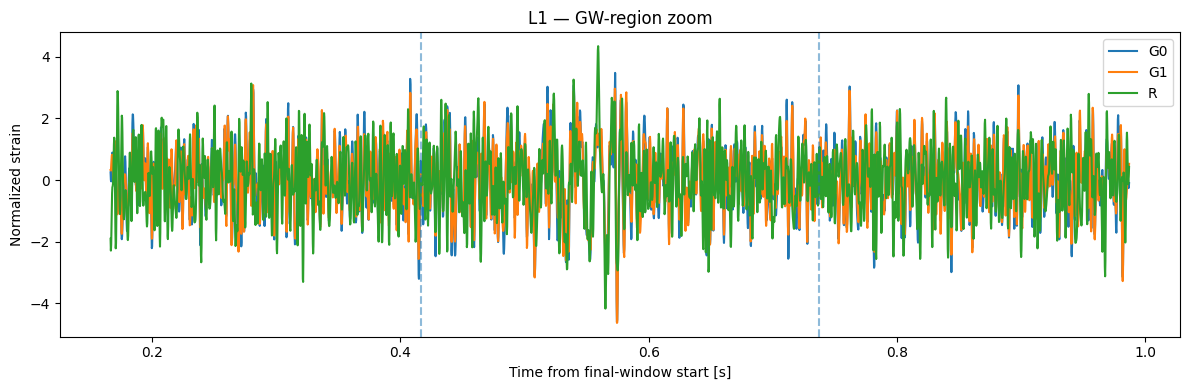

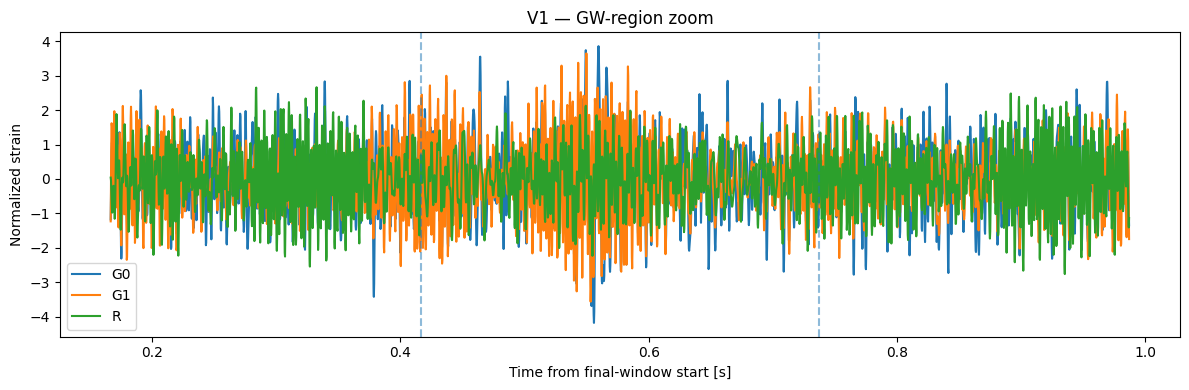

In [293]:
for i, ifo in enumerate(
    M116_DETECTORS
):

    fig, ax = plt.subplots(
        figsize=(12, 4)
    )

    ax.plot(
        time_axis_M116[
            mask_zoom_M116
        ],
        test_X_G0_M116[
            i,
            mask_zoom_M116
        ],
        label="G0",
    )

    ax.plot(
        time_axis_M116[
            mask_zoom_M116
        ],
        test_X_G1_M116[
            i,
            mask_zoom_M116
        ],
        label="G1",
    )

    ax.plot(
        time_axis_M116[
            mask_zoom_M116
        ],
        test_X_R_M116[
            i,
            mask_zoom_M116
        ],
        label="R",
    )

    ax.axvline(
        gw_start_relative_M116,
        linestyle="--",
        alpha=0.5,
    )

    ax.axvline(
        gw_end_relative_M116,
        linestyle="--",
        alpha=0.5,
    )

    ax.set_xlabel(
        "Time from final-window start [s]"
    )

    ax.set_ylabel(
        "Normalized strain"
    )

    ax.set_title(
        f"{ifo} — GW-region zoom"
    )

    ax.legend()

    plt.tight_layout()
    plt.show()

In [294]:
assert (
    test_X_G0_M116.shape
    ==
    test_X_G1_M116.shape
    ==
    test_X_R_M116.shape
    ==
    (
        3,
        16384,
    )
)

assert np.isclose(
    test_distance_G1_M116,
    test_distance_R_M116,
)

assert np.isclose(
    test_snr_emp_net_final_M116,
    test_target_snr_M116,
    rtol=(
        M116_C2_CONFIG
        .snr_relative_tolerance
    ),
)

assert np.all(
    np.isfinite(
        test_X_G0_M116
    )
)

assert np.all(
    np.isfinite(
        test_X_G1_M116
    )
)

assert np.all(
    np.isfinite(
        test_X_R_M116
    )
)

print(
    "Single-source full paired G0/G1/R contract passed."
)

Single-source full paired G0/G1/R contract passed.


## M11.6-C2 — Closure

C2 validated the complete physical construction of the three controlled
noise domains for a paired source.

The final definitions are:

$$
G0:
\quad
h(\theta, d_{G0})
+
n_{\rm Gaussian}
\left[
S_n^{\rm analytical}
\right],
$$

$$
G1:
\quad
h(\theta, d_{G1})
+
n_{\rm Gaussian}
\left[
S_n^{\rm empirical}
\right],
$$

$$
R:
\quad
h(\theta, d_R)
+
n_{\rm real}.
$$

The empirical detector PSD is defined as

$$
\text{off-source strain}
\rightarrow
\text{Welch}
\rightarrow
\text{frequency interpolation},
$$

without inverse-spectrum truncation at the PSD-estimation stage.

The raw/interpolated empirical PSD is used for:

1. G1 Gaussian-noise synthesis;
2. optimal-SNR control above the 30 Hz analysis cutoff;
3. input to the common whitening processor.

Inverse-spectrum truncation is applied only inside `SignalProcessor`,
preventing whitening-specific low-frequency conditioning from entering the
generative noise PSD.

The following contracts have been validated:

- final model input duration: 4 s;
- processing-context duration: 4.8125 s;
- detector order: H1, L1, V1;
- detector projection uses the physical GPS epoch and detector delays;
- the projected network is windowed after detector projection;
- `random_contained` placement is retained;
- the required final GW content is preserved;
- `full_projection` is injected into the processing context;
- G0, G1 and R share source parameters, geometry, placement and target
  network optimal SNR;
- G1 and R share the same empirical PSD and therefore the same
  distance rescaling;
- detector-specific SNR partition is allowed to differ between G0 and
  empirical domains;
- empirical Gaussian-noise amplitudes are consistent in scale with the
  real strain from which the PSD is estimated;
- all three domains pass the same whitening/filtering/cropping pipeline;
- final inputs have shape `(3, 16384)`;
- the M10 per-sample/per-detector z-score is reproduced.

C2 therefore establishes the domain definitions used by the remainder of
M11.6.

Remaining data-bank issues such as temporal overlap between distinct
`file_group_id` values and full GWOSC data-quality/science-mode auditing are
not part of C2 and remain separate pre-production checks.

In [295]:
# Final C2 closure contract.

assert (
    test_X_G0_M116.shape
    ==
    test_X_G1_M116.shape
    ==
    test_X_R_M116.shape
    ==
    (3, 16384)
)

assert np.all(np.isfinite(test_X_G0_M116))
assert np.all(np.isfinite(test_X_G1_M116))
assert np.all(np.isfinite(test_X_R_M116))

assert np.isclose(
    test_distance_G1_M116,
    test_distance_R_M116,
)

assert np.isclose(
    test_snr_G0_net_final_M116,
    test_target_snr_M116,
    rtol=M116_C2_CONFIG.snr_relative_tolerance,
)

assert np.isclose(
    test_snr_emp_net_final_M116,
    test_target_snr_M116,
    rtol=M116_C2_CONFIG.snr_relative_tolerance,
)

for X in [
    test_X_G0_M116,
    test_X_G1_M116,
    test_X_R_M116,
]:
    assert np.allclose(
        X.mean(axis=1),
        0.0,
        atol=1e-5,
    )

print("=" * 72)
print("M11.6-C2 PASS")
print("=" * 72)
print("Single-source G0/G1/R physical construction validated.")

M11.6-C2 PASS
Single-source G0/G1/R physical construction validated.


# M11.6-C3 — Mini-batch paired validation

C2 validated the complete G0/G1/R construction for one paired source.

C3 tests whether the same construction remains valid over a small but
heterogeneous population before implementing large-scale streaming dataset
generation.

This is a validation batch, not a training dataset.

The mini-batch is drawn only from the training split and is designed to cover:

- multiple real-noise environments (`file_group_id`);
- multiple physical noise blocks;
- a broad BBH mass range;
- the full target-SNR range;
- different sky locations and detector responses;
- short and long in-band waveform durations;
- truncated and non-truncated projected signals;
- different random-contained placements.

For every selected `source_id`, the three domains remain paired in source
parameters, GPS environment, placement and target network optimal SNR.

The objective is to identify rare construction failures before producing the
full M11.6-small datasets.

In [296]:
M116_C3_N_SOURCES = 64
M116_C3_SEED = 12345

rng_c3_M116 = np.random.default_rng(
    M116_C3_SEED
)

print(
    "C3 mini-batch size:",
    M116_C3_N_SOURCES,
)

C3 mini-batch size: 64


In [297]:
df_c3_pool_M116 = (
    df_master_experiment_M116[
        df_master_experiment_M116[
            "split"
        ] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    "Train candidate sources:",
    len(df_c3_pool_M116)
)

print(
    "Train file groups:",
    df_c3_pool_M116[
        "file_group_id"
    ].nunique()
)

print(
    "Train blocks:",
    df_c3_pool_M116[
        "block_id"
    ].nunique()
)

Train candidate sources: 20000
Train file groups: 20
Train blocks: 200


In [298]:
assert len(df_c3_pool_M116) > M116_C3_N_SOURCES

assert (
    df_c3_pool_M116[
        "split"
    ]
    == "train"
).all()

assert not (
    df_c3_pool_M116[
        "source_id"
    ]
    .duplicated()
    .any()
)

print(
    "C3 train-only source pool passed."
)

C3 train-only source pool passed.


In [299]:
df_c3_pool_M116[
    "c3_mass_bin"
] = pd.qcut(
    df_c3_pool_M116[
        "chirp_mass"
    ],
    q=4,
    labels=False,
    duplicates="drop",
)

df_c3_pool_M116[
    "c3_snr_bin"
] = pd.qcut(
    df_c3_pool_M116[
        "target_network_snr"
    ],
    q=4,
    labels=False,
    duplicates="drop",
)

In [300]:
df_c3_pool_M116[
    "c3_stratum"
] = (
    df_c3_pool_M116[
        "c3_mass_bin"
    ].astype(str)
    +
    "_"
    +
    df_c3_pool_M116[
        "c3_snr_bin"
    ].astype(str)
)

In [301]:
display(
    pd.crosstab(
        df_c3_pool_M116[
            "c3_mass_bin"
        ],
        df_c3_pool_M116[
            "c3_snr_bin"
        ],
    )
)

c3_snr_bin,0,1,2,3
c3_mass_bin,,,,
0,1213,1294,1211,1282
1,1244,1224,1252,1280
2,1286,1230,1220,1264
3,1257,1252,1317,1174


In [302]:
selected_rows_c3_M116 = []

for stratum, df_group in (
    df_c3_pool_M116
    .groupby(
        "c3_stratum",
        sort=True,
    )
):

    n_take = min(
        4,
        len(df_group),
    )

    chosen_idx = (
        rng_c3_M116.choice(
            df_group.index.to_numpy(),
            size=n_take,
            replace=False,
        )
    )

    selected_rows_c3_M116.extend(
        chosen_idx.tolist()
    )

In [303]:
df_c3_sources_M116 = (
    df_c3_pool_M116
    .loc[
        selected_rows_c3_M116
    ]
    .copy()
)

In [304]:
if (
    len(df_c3_sources_M116)
    <
    M116_C3_N_SOURCES
):
    n_missing = (
        M116_C3_N_SOURCES
        -
        len(df_c3_sources_M116)
    )

    remaining_pool = (
        df_c3_pool_M116[
            ~df_c3_pool_M116[
                "source_id"
            ].isin(
                df_c3_sources_M116[
                    "source_id"
                ]
            )
        ]
    )

    extra_idx = (
        rng_c3_M116.choice(
            remaining_pool.index.to_numpy(),
            size=n_missing,
            replace=False,
        )
    )

    df_c3_sources_M116 = (
        pd.concat(
            [
                df_c3_sources_M116,
                remaining_pool.loc[
                    extra_idx
                ],
            ],
            ignore_index=True,
        )
    )

In [305]:
df_c3_sources_M116 = (
    df_c3_sources_M116
    .sample(
        frac=1.0,
        random_state=M116_C3_SEED,
    )
    .reset_index(drop=True)
)

In [306]:
assert (
    len(df_c3_sources_M116)
    ==
    M116_C3_N_SOURCES
)

assert not (
    df_c3_sources_M116[
        "source_id"
    ]
    .duplicated()
    .any()
)

assert (
    df_c3_sources_M116[
        "split"
    ]
    == "train"
).all()

print(
    "C3 source-selection contracts passed."
)

C3 source-selection contracts passed.


In [307]:
display(
    df_c3_sources_M116[
        [
            "chirp_mass",
            "total_mass",
            "chi_eff",
            "target_network_snr",
        ]
    ]
    .describe()
)

,chirp_mass,total_mass,chi_eff,target_network_snr
count,64.000000,64.000000,64.000000,64.000000
mean,37.450487,96.495021,-0.008475,17.543423
std,16.547217,33.478899,0.407013,4.402085
min,6.254426,15.196025,-0.745523,10.484888
25%,24.015832,77.131588,-0.303721,13.824913
50%,36.476783,94.269723,0.000183,17.566626
75%,50.129200,121.857173,0.233786,21.309956
max,71.013974,163.292601,0.898544,24.826082


In [308]:
print(
    "Unique file groups:",
    df_c3_sources_M116[
        "file_group_id"
    ].nunique(),
)

print(
    "Unique blocks:",
    df_c3_sources_M116[
        "block_id"
    ].nunique(),
)

print(
    "Unique physical noise crops:",
    df_c3_sources_M116[
        "noise_crop_id"
    ].nunique(),
)

Unique file groups: 19
Unique blocks: 48
Unique physical noise crops: 63


In [309]:
display(
    df_c3_sources_M116[
        "file_group_id"
    ]
    .value_counts()
    .sort_index()
    .rename(
        "n_sources"
    )
    .to_frame()
)

,n_sources
file_group_id,
0,3
2,9
3,4
4,4
6,6
9,4
11,3
14,3
15,4


In [310]:
cols_c3_preview_M116 = [
    "source_id",
    "mass_1",
    "mass_2",
    "chirp_mass",
    "total_mass",
    "chi_eff",
    "target_network_snr",
    "file_group_id",
    "block_id",
    "noise_crop_id",
]

In [311]:
display(
    df_c3_sources_M116
    .nsmallest(
        5,
        "chirp_mass",
    )[
        cols_c3_preview_M116
    ]
)

,source_id,mass_1,mass_2,chirp_mass,total_mass,chi_eff,target_network_snr,file_group_id,block_id,noise_crop_id
33,M116_SRC_006273,9.865499,5.330526,6.254426,15.196025,-0.391382,11.059141,16,M116_RB_00152,M116_RC_002288
9,M116_SRC_016665,19.671270,6.266690,9.369906,25.937961,-0.463557,15.224493,2,M116_RB_00017,M116_RC_000263
46,M116_SRC_014715,12.289478,11.266523,10.241739,23.556001,-0.138430,21.426630,19,M116_RB_00191,M116_RC_002873
32,M116_SRC_013473,15.423351,10.966467,11.289118,26.389818,0.207374,11.248848,24,M116_RB_00240,M116_RC_003613
28,M116_SRC_019120,54.264517,5.212505,13.063742,59.477021,0.138374,23.707718,18,M116_RB_00176,M116_RC_002646


In [312]:
display(
    df_c3_sources_M116
    .nlargest(
        5,
        "chirp_mass",
    )[
        cols_c3_preview_M116
    ]
)

,source_id,mass_1,mass_2,chirp_mass,total_mass,chi_eff,target_network_snr,file_group_id,block_id,noise_crop_id
3,M116_SRC_007023,84.790371,78.502230,71.013974,163.292601,-0.028224,13.336589,22,M116_RB_00222,M116_RC_003335
30,M116_SRC_012858,88.882615,70.754327,68.946975,159.636942,-0.724127,18.009233,20,M116_RB_00208,M116_RC_003134
10,M116_SRC_007079,80.952924,74.676406,67.675470,155.629330,0.158634,20.437296,6,M116_RB_00043,M116_RC_000647
25,M116_SRC_016659,86.803849,66.283114,65.913973,153.086964,-0.273503,15.933234,6,M116_RB_00043,M116_RC_000650
54,M116_SRC_007682,79.576339,58.794933,59.410763,138.371272,0.186256,24.727671,9,M116_RB_00075,M116_RC_001132


In [313]:
display(
    pd.concat(
        [
            df_c3_sources_M116
            .nsmallest(
                3,
                "target_network_snr",
            ),

            df_c3_sources_M116
            .nlargest(
                3,
                "target_network_snr",
            ),
        ]
    )[
        cols_c3_preview_M116
    ]
)

,source_id,mass_1,mass_2,chirp_mass,total_mass,chi_eff,target_network_snr,file_group_id,block_id,noise_crop_id
12,M116_SRC_001731,47.861731,38.218439,37.185719,86.080170,-0.515582,10.484888,11,M116_RB_00096,M116_RC_001442
1,M116_SRC_017795,71.968028,62.081323,58.157723,134.049351,0.372396,10.513365,6,M116_RB_00043,M116_RC_000645
63,M116_SRC_002521,59.766923,49.146885,47.136523,108.913808,-0.081747,10.823111,19,M116_RB_00189,M116_RC_002843
11,M116_SRC_012931,49.670678,44.911960,41.106923,94.582638,0.300369,24.826082,2,M116_RB_00021,M116_RC_000322
23,M116_SRC_010178,75.514688,36.295726,44.981683,111.810414,-0.633426,24.740572,4,M116_RB_00039,M116_RC_000598
54,M116_SRC_007682,79.576339,58.794933,59.410763,138.371272,0.186256,24.727671,9,M116_RB_00075,M116_RC_001132


## M11.6-C3-B1 — Reusable paired-domain builder

C2 validated the complete G0/G1/R construction for one source.

C3-B1 now encapsulates that validated construction into a reusable
per-source function. No physical assumption is changed relative to C2.

The builder must preserve, for every `source_id`:

- identical intrinsic and extrinsic source parameters across domains;
- identical physical GPS environment;
- identical random-contained placement;
- identical target network optimal SNR;
- domain-specific distance rescaling;
- identical empirical PSD for G1 and R;
- full projected-signal injection into the processing context;
- identical processing and M10 input normalization.

The first validation uses only three sources selected from the C3 mini-batch:
one low-, one intermediate-, and one high-chirp-mass system.

The objective is software and physics equivalence with C2, not yet
population-level validation.

In [314]:
M116_C3_BUILD_SEED = 24680

M116_C3_PLACEMENT_SEED_OFFSET = 100_000
M116_C3_GAUSSIAN_SEED_OFFSET = 200_000

print(
    "C3 builder base seed:",
    M116_C3_BUILD_SEED,
)

C3 builder base seed: 24680


In [315]:
psd_cache_c3_M116 = {}
strain_cache_c3_M116 = {}

In [316]:
print(
    "PSD cache entries:",
    len(psd_cache_c3_M116),
)

print(
    "Strain cache entries:",
    len(strain_cache_c3_M116),
)

PSD cache entries: 0
Strain cache entries: 0


In [317]:
def get_file_group_strains_c3_M116(
    file_group_id,
    *,
    strain_cache,
):
    file_group_id = int(
        file_group_id
    )

    if file_group_id in strain_cache:
        return strain_cache[
            file_group_id
        ]

    matches = (
        df_unique_file_groups_M116[
            df_unique_file_groups_M116[
                "file_group_id"
            ]
            == file_group_id
        ]
    )

    if len(matches) != 1:
        raise ValueError(
            "Expected exactly one file-group row for "
            f"file_group_id={file_group_id}, "
            f"found {len(matches)}."
        )

    group_row = (
        matches.iloc[0]
    )

    strains = (
        load_file_group_strains_M116(
            group_row
        )
    )

    strain_cache[
        file_group_id
    ] = strains

    return strains

In [318]:
def get_block_psds_c3_M116(
    row,
    *,
    long_strains,
    psd_cache,
):
    block_id = str(
        row["block_id"]
    )

    if block_id in psd_cache:
        return psd_cache[
            block_id
        ]

    psd_start = float(
        row["psd_start"]
    )

    psd_end = float(
        row["psd_end"]
    )

    psds = {
        "snr": {},
        "proc": {},
    }

    for ifo in M116_DETECTORS:

        result = (
            estimate_block_psds_for_detector_M116(
                strain=(
                    long_strains[
                        ifo
                    ]
                ),
                psd_start=psd_start,
                psd_end=psd_end,
            )
        )

        psds["snr"][ifo] = (
            result["snr"]
        )

        psds["proc"][ifo] = (
            result["proc"]
        )

    psd_cache[
        block_id
    ] = psds

    return psds

In [319]:
def build_signal_network_for_params_c3_M116(
    params,
    *,
    geocentric_time,
    final_start,
    injector,
):
    waveform = (
        waveform_generator_M116.generate(
            params
        )
    )

    projection = (
        detector_projector_M116.project(
            h_plus=waveform.h_plus,
            h_cross=waveform.h_cross,
            parameters=params,
            geocentric_coalescence_time=(
                geocentric_time
            ),
        )
    )

    windowed = (
        window_selector_M116.select(
            projected_strains=(
                projection.strains
            ),
            max_duration=(
                M116_C2_CONFIG.duration
            ),
        )
    )

    zeros = {
        ifo:
            injector.build_zero_strain(
                start_time=final_start,
                length=(
                    M116_C2_CONFIG.length
                ),
            )

        for ifo in M116_DETECTORS
    }

    injected = (
        injector.inject_network(
            noises=zeros,
            signals=(
                windowed.strains
            ),
        )
    )

    segments = {
        ifo:
            injected[ifo].strain

        for ifo in M116_DETECTORS
    }

    return {
        "waveform":
            waveform,

        "projection":
            projection,

        "windowed":
            windowed,

        "segments":
            segments,
    }

In [320]:
def build_gaussian_processing_noise_c3_M116(
    *,
    psds_proc,
    processing_start,
    detector_seeds,
    injector,
):
    noises = {}

    for ifo in M116_DETECTORS:

        noise = (
            gaussian.noise_from_psd(
                psd=(
                    psds_proc[
                        ifo
                    ]
                ),
                length=(
                    M116_C2_CONFIG
                    .processing_length
                ),
                delta_t=(
                    M116_C2_CONFIG
                    .delta_t
                ),
                seed=int(
                    detector_seeds[
                        ifo
                    ]
                ),
            )
        )

        noises[ifo] = (
            injector.set_strain_start_time(
                strain=noise,
                start_time=(
                    processing_start
                ),
                expected_length=(
                    M116_C2_CONFIG
                    .processing_length
                ),
            )
        )

    return noises

In [321]:
def stack_and_normalize_network_c3_M116(
    network,
):
    X_raw = np.stack(
        [
            np.asarray(
                network[
                    ifo
                ]
            )
            for ifo
            in M116_DETECTORS
        ],
        axis=0,
    )

    if (
        X_raw.shape
        !=
        (
            3,
            M116_C2_CONFIG.length,
        )
    ):
        raise ValueError(
            "Unexpected processed network shape: "
            f"{X_raw.shape}"
        )

    if not np.all(
        np.isfinite(
            X_raw
        )
    ):
        raise ValueError(
            "Processed network contains "
            "non-finite values."
        )

    X = (
        normalize_input_per_sample_per_detector_zscore(
            X_raw,
            eps=(
                M116_M10_INPUT_ZSCORE_EPS
            ),
        )
    )

    return X_raw, X

In [322]:
def build_paired_domains_for_manifest_row_M116(
    row,
    *,
    psd_cache,
    strain_cache,
):
    # -------------------------------------------------
    # 1. Source identity and deterministic RNGs
    # -------------------------------------------------

    source_id = str(
        row["source_id"]
    )

    source_index = int(
        row["source_index"]
    )

    placement_rng = np.random.default_rng(
        M116_C3_BUILD_SEED
        +
        M116_C3_PLACEMENT_SEED_OFFSET
        +
        source_index
    )

    gaussian_rng = np.random.default_rng(
        M116_C3_BUILD_SEED
        +
        M116_C3_GAUSSIAN_SEED_OFFSET
        +
        source_index
    )

    injector = SignalInjector(
        config=M116_C2_CONFIG,
        rng=placement_rng,
    )

    gaussian_seeds = {
        ifo:
            int(
                gaussian_rng.integers(
                    0,
                    2**32 - 1,
                )
            )
        for ifo
        in M116_DETECTORS
    }

    # -------------------------------------------------
    # 2. Physical source parameters
    # -------------------------------------------------

    params_ref = CBCParameters(
        mass_1=float(
            row["mass_1"]
        ),
        mass_2=float(
            row["mass_2"]
        ),
        distance=float(
            row[
                "reference_distance_mpc"
            ]
        ),
        inclination=float(
            row["inclination"]
        ),
        ra=float(
            row["ra"]
        ),
        dec=float(
            row["dec"]
        ),
        spin_1z=float(
            row["spin_1z"]
        ),
        spin_2z=float(
            row["spin_2z"]
        ),
        polarization_angle=float(
            row[
                "polarization_angle"
            ]
        ),
    )

    target_snr = float(
        row["target_network_snr"]
    )

    # -------------------------------------------------
    # 3. Assigned physical real-noise window
    # -------------------------------------------------

    processing_start = float(
        row["processing_start"]
    )

    processing_end = float(
        row["processing_end"]
    )

    final_start = (
        processing_start
        +
        M116_C2_CONFIG
        .processing_context_start_seconds
    )

    final_end = (
        final_start
        +
        M116_C2_CONFIG.duration
    )

    final_center = (
        0.5
        *
        (
            final_start
            +
            final_end
        )
    )

    if not np.isclose(
        processing_end
        -
        processing_start,
        M116_C2_CONFIG
        .processing_duration,
    ):
        raise ValueError(
            f"{source_id}: invalid processing duration."
        )

    # -------------------------------------------------
    # 4. Reference waveform and provisional projection
    # -------------------------------------------------

    waveform_ref = (
        waveform_generator_M116.generate(
            params_ref
        )
    )

    projection_provisional = (
        detector_projector_M116.project(
            h_plus=(
                waveform_ref.h_plus
            ),
            h_cross=(
                waveform_ref.h_cross
            ),
            parameters=params_ref,
            geocentric_coalescence_time=(
                final_center
            ),
        )
    )

    windowed_provisional = (
        window_selector_M116.select(
            projected_strains=(
                projection_provisional
                .strains
            ),
            max_duration=(
                M116_C2_CONFIG.duration
            ),
        )
    )

    # -------------------------------------------------
    # 5. Random-contained placement
    # -------------------------------------------------

    abstract_placement = (
        injector
        .choose_segment_placement_containing_network(
            signals=(
                windowed_provisional
                .strains
            ),
            placement_policy=(
                "random_contained"
            ),
            safe_margin_start=float(
                M116_C2_CONFIG
                .safe_margin_start
            ),
            safe_margin_end=float(
                M116_C2_CONFIG
                .safe_margin_end
            ),
            enforce_safe_margins=True,
        )
    )

    placement_shift = (
        final_start
        -
        float(
            abstract_placement
            .segment_start_time
        )
    )

    geocentric_time = (
        final_center
        +
        placement_shift
    )

    placement_offset_s = (
        geocentric_time
        -
        final_center
    )

    # -------------------------------------------------
    # 6. Final reference projection
    # -------------------------------------------------

    projection_ref = (
        detector_projector_M116.project(
            h_plus=(
                waveform_ref.h_plus
            ),
            h_cross=(
                waveform_ref.h_cross
            ),
            parameters=params_ref,
            geocentric_coalescence_time=(
                geocentric_time
            ),
        )
    )

    windowed_ref = (
        window_selector_M116.select(
            projected_strains=(
                projection_ref.strains
            ),
            max_duration=(
                M116_C2_CONFIG.duration
            ),
        )
    )

    tol = (
        2.0
        *
        M116_C2_CONFIG.delta_t
    )

    if (
        windowed_ref
        .metadata
        .used_window_start_time
        <
        final_start - tol
    ):
        raise ValueError(
            f"{source_id}: signal starts outside final segment."
        )

    if (
        windowed_ref
        .metadata
        .used_window_end_time
        >
        final_end + tol
    ):
        raise ValueError(
            f"{source_id}: signal ends outside final segment."
        )

    # -------------------------------------------------
    # 7. Reference signal-only final 4 s
    # -------------------------------------------------

    zero_final = {
        ifo:
            injector.build_zero_strain(
                start_time=final_start,
                length=(
                    M116_C2_CONFIG.length
                ),
            )
        for ifo
        in M116_DETECTORS
    }

    signal_only_ref_results = (
        injector.inject_network(
            noises=zero_final,
            signals=(
                windowed_ref.strains
            ),
        )
    )

    signal_segments_ref = {
        ifo:
            signal_only_ref_results[
                ifo
            ].strain
        for ifo
        in M116_DETECTORS
    }

    # -------------------------------------------------
    # 8. Load real environment and empirical PSDs
    # -------------------------------------------------

    file_group_id = int(
        row["file_group_id"]
    )

    long_strains = (
        get_file_group_strains_c3_M116(
            file_group_id,
            strain_cache=(
                strain_cache
            ),
        )
    )

    empirical_psds = (
        get_block_psds_c3_M116(
            row,
            long_strains=(
                long_strains
            ),
            psd_cache=(
                psd_cache
            ),
        )
    )

    psds_emp_snr = (
        empirical_psds["snr"]
    )

    psds_emp_proc = (
        empirical_psds["proc"]
    )

    # -------------------------------------------------
    # 9. Reference SNR under each PSD domain
    # -------------------------------------------------

    snrs_G0_ref, snr_G0_ref = (
        compute_network_optimal_snr(
            signal_segments=(
                signal_segments_ref
            ),
            psds=(
                psds_G0_snr_M116
            ),
            config=(
                M116_C2_CONFIG
            ),
        )
    )

    snrs_emp_ref, snr_emp_ref = (
        compute_network_optimal_snr(
            signal_segments=(
                signal_segments_ref
            ),
            psds=(
                psds_emp_snr
            ),
            config=(
                M116_C2_CONFIG
            ),
        )
    )

    # -------------------------------------------------
    # 10. Domain-specific distance rescaling
    # -------------------------------------------------

    distance_G0 = (
        rescale_distance_for_target_network_snr(
            current_distance=(
                params_ref.distance
            ),
            current_network_snr=(
                snr_G0_ref
            ),
            target_network_snr=(
                target_snr
            ),
        )
    )

    distance_emp = (
        rescale_distance_for_target_network_snr(
            current_distance=(
                params_ref.distance
            ),
            current_network_snr=(
                snr_emp_ref
            ),
            target_network_snr=(
                target_snr
            ),
        )
    )

    params_G0 = (
        params_ref.with_distance(
            distance_G0
        )
    )

    params_emp = (
        params_ref.with_distance(
            distance_emp
        )
    )

    # -------------------------------------------------
    # 11. Build final domain-specific signals
    # -------------------------------------------------

    signal_G0 = (
        build_signal_network_for_params_c3_M116(
            params_G0,
            geocentric_time=(
                geocentric_time
            ),
            final_start=(
                final_start
            ),
            injector=injector,
        )
    )

    signal_emp = (
        build_signal_network_for_params_c3_M116(
            params_emp,
            geocentric_time=(
                geocentric_time
            ),
            final_start=(
                final_start
            ),
            injector=injector,
        )
    )

    # -------------------------------------------------
    # 12. Final optimal-SNR validation
    # -------------------------------------------------

    snrs_G0_final, snr_G0_final = (
        compute_network_optimal_snr(
            signal_segments=(
                signal_G0[
                    "segments"
                ]
            ),
            psds=(
                psds_G0_snr_M116
            ),
            config=(
                M116_C2_CONFIG
            ),
        )
    )

    snrs_emp_final, snr_emp_final = (
        compute_network_optimal_snr(
            signal_segments=(
                signal_emp[
                    "segments"
                ]
            ),
            psds=(
                psds_emp_snr
            ),
            config=(
                M116_C2_CONFIG
            ),
        )
    )

    validate_snr_rescaling(
        final_network_snr=(
            snr_G0_final
        ),
        target_network_snr=(
            target_snr
        ),
        relative_tolerance=(
            M116_C2_CONFIG
            .snr_relative_tolerance
        ),
    )

    validate_snr_rescaling(
        final_network_snr=(
            snr_emp_final
        ),
        target_network_snr=(
            target_snr
        ),
        relative_tolerance=(
            M116_C2_CONFIG
            .snr_relative_tolerance
        ),
    )

    # -------------------------------------------------
    # 13. G0 and G1 Gaussian processing noise
    # -------------------------------------------------

    noise_G0 = (
        build_gaussian_processing_noise_c3_M116(
            psds_proc=(
                psds_G0_proc_M116
            ),
            processing_start=(
                processing_start
            ),
            detector_seeds=(
                gaussian_seeds
            ),
            injector=injector,
        )
    )

    noise_G1 = (
        build_gaussian_processing_noise_c3_M116(
            psds_proc=(
                psds_emp_proc
            ),
            processing_start=(
                processing_start
            ),
            detector_seeds=(
                gaussian_seeds
            ),
            injector=injector,
        )
    )

    # -------------------------------------------------
    # 14. Exact R processing context
    # -------------------------------------------------

    noise_R = {
        ifo:
            extract_exact_processing_context_M116(
                long_strains[
                    ifo
                ],
                start_time=(
                    processing_start
                ),
                expected_length=(
                    M116_C2_CONFIG
                    .processing_length
                ),
            )
        for ifo
        in M116_DETECTORS
    }

    # -------------------------------------------------
    # 15. Full-projection signal injection
    # -------------------------------------------------

    injected_G0_results = (
        injector.inject_network(
            noises=noise_G0,
            signals=(
                signal_G0[
                    "projection"
                ].strains
            ),
        )
    )

    injected_G1_results = (
        injector.inject_network(
            noises=noise_G1,
            signals=(
                signal_emp[
                    "projection"
                ].strains
            ),
        )
    )

    injected_R_results = (
        injector.inject_network(
            noises=noise_R,
            signals=(
                signal_emp[
                    "projection"
                ].strains
            ),
        )
    )

    injected_G0 = {
        ifo:
            injected_G0_results[
                ifo
            ].strain
        for ifo
        in M116_DETECTORS
    }

    injected_G1 = {
        ifo:
            injected_G1_results[
                ifo
            ].strain
        for ifo
        in M116_DETECTORS
    }

    injected_R = {
        ifo:
            injected_R_results[
                ifo
            ].strain
        for ifo
        in M116_DETECTORS
    }

    # -------------------------------------------------
    # 16. Common processing
    # -------------------------------------------------

    processed_G0 = (
        processor_M116.process_network(
            strains=injected_G0,
            psds=(
                psds_G0_proc_M116
            ),
        )
    )

    processed_G1 = (
        processor_M116.process_network(
            strains=injected_G1,
            psds=(
                psds_emp_proc
            ),
        )
    )

    processed_R = (
        processor_M116.process_network(
            strains=injected_R,
            psds=(
                psds_emp_proc
            ),
        )
    )

    # -------------------------------------------------
    # 17. Stack + M10 z-score
    # -------------------------------------------------

    X_G0_raw, X_G0 = (
        stack_and_normalize_network_c3_M116(
            processed_G0
        )
    )

    X_G1_raw, X_G1 = (
        stack_and_normalize_network_c3_M116(
            processed_G1
        )
    )

    X_R_raw, X_R = (
        stack_and_normalize_network_c3_M116(
            processed_R
        )
    )

    # -------------------------------------------------
    # 18. Final hard contracts
    # -------------------------------------------------

    expected_shape = (
        len(M116_DETECTORS),
        M116_C2_CONFIG.length,
    )

    for domain_name, X in [
        ("G0", X_G0),
        ("G1", X_G1),
        ("R", X_R),
    ]:
        if X.shape != expected_shape:
            raise ValueError(
                f"{source_id} {domain_name}: "
                f"shape={X.shape}, "
                f"expected={expected_shape}."
            )

        if not np.all(
            np.isfinite(X)
        ):
            raise ValueError(
                f"{source_id} {domain_name}: "
                "non-finite final input."
            )

    if not np.isfinite(
        distance_emp
    ):
        raise RuntimeError(
            f"{source_id}: invalid empirical distance."
        )

    # -------------------------------------------------
    # 19. Diagnostics
    # -------------------------------------------------

    raw_noise_std = {}

    for domain_name, network in [
        ("G0", noise_G0),
        ("G1", noise_G1),
        ("R", noise_R),
    ]:
        raw_noise_std[
            domain_name
        ] = {
            ifo:
                float(
                    np.std(
                        np.asarray(
                            network[ifo]
                        )
                    )
                )
            for ifo
            in M116_DETECTORS
        }

    processed_std = {}

    for domain_name, X_raw in [
        ("G0", X_G0_raw),
        ("G1", X_G1_raw),
        ("R", X_R_raw),
    ]:
        processed_std[
            domain_name
        ] = {
            ifo:
                float(
                    X_raw[i].std()
                )
            for i, ifo
            in enumerate(
                M116_DETECTORS
            )
        }

    diagnostics = {
        "source_id":
            source_id,

        "source_index":
            source_index,

        "file_group_id":
            file_group_id,

        "block_id":
            str(
                row["block_id"]
            ),

        "noise_crop_id":
            str(
                row["noise_crop_id"]
            ),

        "chirp_mass":
            float(
                params_ref.chirp_mass
            ),

        "total_mass":
            float(
                params_ref.total_mass
            ),

        "chi_eff":
            float(
                params_ref.chi_eff
            ),

        "target_network_snr":
            target_snr,

        "geocentric_time":
            float(
                geocentric_time
            ),

        "placement_offset_s":
            float(
                placement_offset_s
            ),

        "full_network_duration":
            float(
                windowed_ref
                .metadata
                .full_network_duration
            ),

        "required_final_duration":
            float(
                windowed_ref
                .metadata
                .required_available_final_duration
            ),

        "is_truncated":
            bool(
                windowed_ref
                .metadata
                .is_truncated
            ),

        "distance_G0":
            float(
                distance_G0
            ),

        "distance_G1":
            float(
                distance_emp
            ),

        "distance_R":
            float(
                distance_emp
            ),

        "snr_G0":
            float(
                snr_G0_final
            ),

        "snr_G1":
            float(
                snr_emp_final
            ),

        "snr_R":
            float(
                snr_emp_final
            ),

        "snrs_G0_det":
            dict(
                snrs_G0_final
            ),

        "snrs_G1_det":
            dict(
                snrs_emp_final
            ),

        "snrs_R_det":
            dict(
                snrs_emp_final
            ),

        "raw_noise_std":
            raw_noise_std,

        "processed_std":
            processed_std,

        "all_finite":
            True,
    }

    return {
        "source_id":
            source_id,

        "G0": {
            "X":
                X_G0,
            "X_raw":
                X_G0_raw,
            "distance_mpc":
                float(
                    distance_G0
                ),
            "network_snr":
                float(
                    snr_G0_final
                ),
            "detector_snrs":
                dict(
                    snrs_G0_final
                ),
        },

        "G1": {
            "X":
                X_G1,
            "X_raw":
                X_G1_raw,
            "distance_mpc":
                float(
                    distance_emp
                ),
            "network_snr":
                float(
                    snr_emp_final
                ),
            "detector_snrs":
                dict(
                    snrs_emp_final
                ),
        },

        "R": {
            "X":
                X_R,
            "X_raw":
                X_R_raw,
            "distance_mpc":
                float(
                    distance_emp
                ),
            "network_snr":
                float(
                    snr_emp_final
                ),
            "detector_snrs":
                dict(
                    snrs_emp_final
                ),
        },

        "diagnostics":
            diagnostics,
    }

In [323]:
df_c3_sources_sorted_M116 = (
    df_c3_sources_M116
    .sort_values(
        "chirp_mass"
    )
    .reset_index(drop=True)
)

idx_low_M116 = 0

idx_mid_M116 = (
    len(
        df_c3_sources_sorted_M116
    )
    // 2
)

idx_high_M116 = (
    len(
        df_c3_sources_sorted_M116
    )
    - 1
)

df_c3_b1_sources_M116 = (
    df_c3_sources_sorted_M116
    .iloc[
        [
            idx_low_M116,
            idx_mid_M116,
            idx_high_M116,
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

In [324]:
display(
    df_c3_b1_sources_M116[
        [
            "source_id",
            "mass_1",
            "mass_2",
            "chirp_mass",
            "total_mass",
            "chi_eff",
            "target_network_snr",
            "file_group_id",
            "block_id",
            "noise_crop_id",
        ]
    ]
)

,source_id,mass_1,mass_2,chirp_mass,total_mass,chi_eff,target_network_snr,file_group_id,block_id,noise_crop_id
0,M116_SRC_006273,9.865499,5.330526,6.254426,15.196025,-0.391382,11.059141,16,M116_RB_00152,M116_RC_002288
1,M116_SRC_001731,47.861731,38.218439,37.185719,86.080170,-0.515582,10.484888,11,M116_RB_00096,M116_RC_001442
2,M116_SRC_007023,84.790371,78.502230,71.013974,163.292601,-0.028224,13.336589,22,M116_RB_00222,M116_RC_003335


In [325]:
c3_b1_results_M116 = []

c3_b1_failures_M116 = []

In [326]:
for i, row in (
    df_c3_b1_sources_M116
    .iterrows()
):

    source_id = str(
        row["source_id"]
    )

    print(
        "\n",
        "=" * 72,
    )

    print(
        f"[{i + 1}/"
        f"{len(df_c3_b1_sources_M116)}] "
        f"{source_id}"
    )

    print(
        "=" * 72
    )

    try:

        result = (
            build_paired_domains_for_manifest_row_M116(
                row,
                psd_cache=(
                    psd_cache_c3_M116
                ),
                strain_cache=(
                    strain_cache_c3_M116
                ),
            )
        )

        c3_b1_results_M116.append(
            result
        )

        print(
            "PASS"
        )

        print(
            "chirp_mass:",
            result[
                "diagnostics"
            ][
                "chirp_mass"
            ],
        )

        print(
            "target SNR:",
            result[
                "diagnostics"
            ][
                "target_network_snr"
            ],
        )

        print(
            "distances:",
            {
                domain:
                    result[
                        domain
                    ][
                        "distance_mpc"
                    ]
                for domain
                in [
                    "G0",
                    "G1",
                    "R",
                ]
            },
        )

        print(
            "network SNRs:",
            {
                domain:
                    result[
                        domain
                    ][
                        "network_snr"
                    ]
                for domain
                in [
                    "G0",
                    "G1",
                    "R",
                ]
            },
        )

    except Exception as exc:

        c3_b1_failures_M116.append({
            "source_id":
                source_id,

            "exception_type":
                type(exc).__name__,

            "message":
                str(exc),
        })

        print(
            "FAIL:",
            type(exc).__name__,
            str(exc),
        )


[1/3] M116_SRC_006273
Using cached file: H-H1_GWOSC_4KHZ_R1-1265233948-4096.hdf5
Using cached file: L-L1_GWOSC_4KHZ_R1-1265233948-4096.hdf5
Using cached file: V-V1_GWOSC_4KHZ_R1-1265233948-4096.hdf5
PASS
chirp_mass: 6.2544262364667125
target SNR: 11.0591410778028
distances: {'G0': 361.11582079506286, 'G1': 221.48196685951285, 'R': 221.48196685951285}
network SNRs: {'G0': 11.05914107780278, 'G1': 11.059141077802774, 'R': 11.059141077802774}

[2/3] M116_SRC_001731
Using cached file: H-H1_GWOSC_4KHZ_R1-1263095360-4096.hdf5
Using cached file: L-L1_GWOSC_4KHZ_R1-1263095360-4096.hdf5
Using cached file: V-V1_GWOSC_4KHZ_R1-1263095360-4096.hdf5
PASS
chirp_mass: 37.185719063671094
target SNR: 10.484887780736285
distances: {'G0': 1767.3470442598718, 'G1': 650.854610638249, 'R': 650.854610638249}
network SNRs: {'G0': 10.484887780736285, 'G1': 10.484887780735953, 'R': 10.484887780735953}

[3/3] M116_SRC_007023
Using cached file: H-H1_GWOSC_4KHZ_R1-1266236101-4096.hdf5
Using cached file: L-L1_GWOSC

In [327]:
print(
    "Successful sources:",
    len(
        c3_b1_results_M116
    ),
)

print(
    "Failed sources:",
    len(
        c3_b1_failures_M116
    ),
)

if len(
    c3_b1_failures_M116
) > 0:

    display(
        pd.DataFrame(
            c3_b1_failures_M116
        )
    )

Successful sources: 3
Failed sources: 0


In [328]:
assert (
    len(
        c3_b1_results_M116
    )
    ==
    3
)

assert (
    len(
        c3_b1_failures_M116
    )
    ==
    0
)

print(
    "C3-B1 three-source execution passed."
)

C3-B1 three-source execution passed.


In [329]:
c3_b1_diag_rows_M116 = []

for result in (
    c3_b1_results_M116
):

    d = result[
        "diagnostics"
    ]

    row = {
        "source_id":
            d["source_id"],

        "chirp_mass":
            d["chirp_mass"],

        "total_mass":
            d["total_mass"],

        "chi_eff":
            d["chi_eff"],

        "target_snr":
            d[
                "target_network_snr"
            ],

        "file_group_id":
            d["file_group_id"],

        "block_id":
            d["block_id"],

        "placement_offset_s":
            d[
                "placement_offset_s"
            ],

        "full_network_duration":
            d[
                "full_network_duration"
            ],

        "required_final_duration":
            d[
                "required_final_duration"
            ],

        "is_truncated":
            d[
                "is_truncated"
            ],

        "distance_G0":
            d["distance_G0"],

        "distance_G1":
            d["distance_G1"],

        "distance_R":
            d["distance_R"],

        "snr_G0":
            d["snr_G0"],

        "snr_G1":
            d["snr_G1"],

        "snr_R":
            d["snr_R"],
    }

    for domain in [
        "G0",
        "G1",
        "R",
    ]:

        for ifo in (
            M116_DETECTORS
        ):

            row[
                f"{domain}_raw_std_{ifo}"
            ] = (
                d[
                    "raw_noise_std"
                ][
                    domain
                ][
                    ifo
                ]
            )

            row[
                f"{domain}_proc_std_{ifo}"
            ] = (
                d[
                    "processed_std"
                ][
                    domain
                ][
                    ifo
                ]
            )

    c3_b1_diag_rows_M116.append(
        row
    )

df_c3_b1_diagnostics_M116 = (
    pd.DataFrame(
        c3_b1_diag_rows_M116
    )
)

display(
    df_c3_b1_diagnostics_M116
)

,source_id,chirp_mass,total_mass,chi_eff,target_snr,file_group_id,block_id,placement_offset_s,full_network_duration,required_final_duration,...,G1_raw_std_L1,G1_proc_std_L1,G1_raw_std_V1,G1_proc_std_V1,R_raw_std_H1,R_proc_std_H1,R_raw_std_L1,R_proc_std_L1,R_raw_std_V1,R_proc_std_V1
0,M116_SRC_006273,6.254426,15.196025,-0.391382,11.059141,16,M116_RB_00152,1.807743,3.359375,1.000000,...,1.463522e-18,26.977548,9.564295e-20,95.908531,4.963918e-20,69.963906,4.848405e-19,23.273905,8.738338e-20,87.885699
1,M116_SRC_001731,37.185719,86.080170,-0.515582,10.484888,11,M116_RB_00096,-0.001388,0.291260,0.291260,...,1.035306e-18,45.507062,1.279663e-19,250.273379,4.661699e-20,28.329587,8.138995e-19,30.285863,1.852597e-19,285.877118
2,M116_SRC_007023,71.013974,163.292601,-0.028224,13.336589,22,M116_RB_00222,-1.921580,0.379883,0.379883,...,9.656606e-19,23.765589,1.412503e-19,403.220580,4.796578e-20,53.630407,9.482421e-19,24.053420,1.344779e-19,277.278017


In [330]:
for result in (
    c3_b1_results_M116
):

    d = (
        result[
            "diagnostics"
        ]
    )

    target = float(
        d[
            "target_network_snr"
        ]
    )

    assert np.isclose(
        d["distance_G1"],
        d["distance_R"],
        rtol=0.0,
        atol=1e-10,
    )

    for key in [
        "snr_G0",
        "snr_G1",
        "snr_R",
    ]:

        assert np.isclose(
            d[key],
            target,
            rtol=(
                M116_C2_CONFIG
                .snr_relative_tolerance
            ),
        )

    for domain in [
        "G0",
        "G1",
        "R",
    ]:

        X = (
            result[
                domain
            ][
                "X"
            ]
        )

        assert (
            X.shape
            ==
            (
                3,
                16384,
            )
        )

        assert np.all(
            np.isfinite(X)
        )

        assert np.allclose(
            X.mean(axis=1),
            0.0,
            atol=1e-5,
        )

print(
    "C3-B1 paired physics contracts passed."
)

C3-B1 paired physics contracts passed.


In [331]:
display(
    df_c3_b1_diagnostics_M116[
        [
            "source_id",
            "chirp_mass",
            "total_mass",
            "full_network_duration",
            "required_final_duration",
            "is_truncated",
            "placement_offset_s",
        ]
    ]
)

,source_id,chirp_mass,total_mass,full_network_duration,required_final_duration,is_truncated,placement_offset_s
0,M116_SRC_006273,6.254426,15.196025,3.359375,1.000000,False,1.807743
1,M116_SRC_001731,37.185719,86.080170,0.291260,0.291260,False,-0.001388
2,M116_SRC_007023,71.013974,163.292601,0.379883,0.379883,False,-1.921580


In [332]:
scale_rows_c3_b1_M116 = []

for result in (
    c3_b1_results_M116
):

    d = (
        result[
            "diagnostics"
        ]
    )

    for ifo in (
        M116_DETECTORS
    ):

        g1_std = (
            d[
                "raw_noise_std"
            ][
                "G1"
            ][
                ifo
            ]
        )

        r_std = (
            d[
                "raw_noise_std"
            ][
                "R"
            ][
                ifo
            ]
        )

        scale_rows_c3_b1_M116.append({
            "source_id":
                d["source_id"],

            "detector":
                ifo,

            "G1_raw_std":
                g1_std,

            "R_raw_std":
                r_std,

            "G1_over_R":
                (
                    g1_std
                    /
                    r_std
                ),
        })

df_c3_b1_scale_check_M116 = (
    pd.DataFrame(
        scale_rows_c3_b1_M116
    )
)

display(
    df_c3_b1_scale_check_M116
)

,source_id,detector,G1_raw_std,R_raw_std,G1_over_R
0,M116_SRC_006273,H1,5.296638e-20,4.963918e-20,1.067028
1,M116_SRC_006273,L1,1.463522e-18,4.848405e-19,3.018563
2,M116_SRC_006273,V1,9.564295e-20,8.738338e-20,1.094521
3,M116_SRC_001731,H1,4.009888e-20,4.661699e-20,0.860177
4,M116_SRC_001731,L1,1.035306e-18,8.138995e-19,1.272031
5,M116_SRC_001731,V1,1.279663e-19,1.852597e-19,0.690740
6,M116_SRC_007023,H1,5.778903e-20,4.796578e-20,1.204797
7,M116_SRC_007023,L1,9.656606e-19,9.482421e-19,1.018369
8,M116_SRC_007023,V1,1.412503e-19,1.344779e-19,1.050360


In [333]:
print(
    "=" * 72
)

print(
    "M11.6-C3-B1 SUMMARY"
)

print(
    "=" * 72
)

print(
    "Sources tested:",
    len(
        c3_b1_results_M116
    )
)

print(
    "Failures:",
    len(
        c3_b1_failures_M116
    )
)

print(
    "PSD cache blocks:",
    len(
        psd_cache_c3_M116
    )
)

print(
    "Loaded file groups:",
    len(
        strain_cache_c3_M116
    )
)

print(
    "All three sources passed paired construction:",
    len(
        c3_b1_failures_M116
    ) == 0,
)

M11.6-C3-B1 SUMMARY
Sources tested: 3
Failures: 0
PSD cache blocks: 3
Loaded file groups: 3
All three sources passed paired construction: True


## M11.6-C3-B2 — 64-source paired validation

C3-B1 validated the reusable paired-domain builder on three deliberately
different sources spanning low, intermediate and high chirp mass.

C3-B2 now executes the same validated builder over the full 64-source C3
mini-batch.

No new physical logic is introduced.

The objectives are:

- detect rare construction failures;
- quantify truncation and placement behaviour across the mini-batch;
- verify target-SNR control across all three domains;
- check the G1/R empirical-noise scale consistency across multiple
  environments;
- inspect domain-specific distance rescaling;
- confirm final input geometry and finiteness for every source.

This remains a validation batch, not a training dataset.

In [334]:
psd_cache_c3b2_M116 = {}
strain_cache_c3b2_M116 = {}

print(
    "Initial PSD cache entries:",
    len(psd_cache_c3b2_M116),
)

print(
    "Initial strain cache entries:",
    len(strain_cache_c3b2_M116),
)

Initial PSD cache entries: 0
Initial strain cache entries: 0


In [335]:
c3_b2_results_M116 = []
c3_b2_failures_M116 = []

In [336]:
n_c3_b2_M116 = len(
    df_c3_sources_M116
)

for i, row in (
    df_c3_sources_M116
    .iterrows()
):

    source_id = str(
        row["source_id"]
    )

    print(
        f"[{i + 1:02d}/{n_c3_b2_M116:02d}] "
        f"{source_id}",
        end="  ",
        flush=True,
    )

    try:

        result = (
            build_paired_domains_for_manifest_row_M116(
                row,
                psd_cache=(
                    psd_cache_c3b2_M116
                ),
                strain_cache=(
                    strain_cache_c3b2_M116
                ),
            )
        )

        c3_b2_results_M116.append(
            result
        )

        print("PASS")

    except Exception as exc:

        failure = {
            "source_id":
                source_id,

            "source_index":
                int(
                    row["source_index"]
                ),

            "file_group_id":
                int(
                    row["file_group_id"]
                ),

            "block_id":
                str(
                    row["block_id"]
                ),

            "noise_crop_id":
                str(
                    row["noise_crop_id"]
                ),

            "chirp_mass":
                float(
                    row["chirp_mass"]
                ),

            "target_network_snr":
                float(
                    row[
                        "target_network_snr"
                    ]
                ),

            "exception_type":
                type(exc).__name__,

            "message":
                str(exc),
        }

        c3_b2_failures_M116.append(
            failure
        )

        print(
            "FAIL:",
            type(exc).__name__,
            str(exc),
        )

[01/64] M116_SRC_006509  Using cached file: H-H1_GWOSC_4KHZ_R1-1257662644-4096.hdf5
Using cached file: L-L1_GWOSC_4KHZ_R1-1257662644-4096.hdf5
Using cached file: V-V1_GWOSC_4KHZ_R1-1257662644-4096.hdf5
PASS
[02/64] M116_SRC_017795  Using cached file: H-H1_GWOSC_4KHZ_R1-1259490700-4096.hdf5
Using cached file: L-L1_GWOSC_4KHZ_R1-1259490700-4096.hdf5
Using cached file: V-V1_GWOSC_O3b_4KHZ_R1-1259491328-4096.hdf5
PASS
[03/64] M116_SRC_013183  PASS
[04/64] M116_SRC_007023  Using cached file: H-H1_GWOSC_4KHZ_R1-1266236101-4096.hdf5
Using cached file: L-L1_GWOSC_4KHZ_R1-1266236101-4096.hdf5
Using cached file: V-V1_GWOSC_O3b_4KHZ_R1-1266237440-4096.hdf5
PASS
[05/64] M116_SRC_005172  Using cached file: H-H1_GWOSC_4KHZ_R1-1257294808-4096.hdf5
Using cached file: L-L1_GWOSC_4KHZ_R1-1257294808-4096.hdf5
Using cached file: V-V1_GWOSC_O3b_4KHZ_R1-1257295872-4096.hdf5
PASS
[06/64] M116_SRC_007977  PASS
[07/64] M116_SRC_010011  Using cached file: H-H1_GWOSC_4KHZ_R1-1265200048-4096.hdf5
Using cached fil

In [337]:
print(
    "Successful sources:",
    len(
        c3_b2_results_M116
    ),
)

print(
    "Failed sources:",
    len(
        c3_b2_failures_M116
    ),
)

print(
    "PSD cache blocks:",
    len(
        psd_cache_c3b2_M116
    ),
)

print(
    "Loaded file groups:",
    len(
        strain_cache_c3b2_M116
    ),
)

Successful sources: 64
Failed sources: 0
PSD cache blocks: 48
Loaded file groups: 19


In [338]:
c3_b2_diag_rows_M116 = []

for result in (
    c3_b2_results_M116
):

    d = (
        result[
            "diagnostics"
        ]
    )

    row = {
        "source_id":
            d["source_id"],

        "source_index":
            d["source_index"],

        "file_group_id":
            d["file_group_id"],

        "block_id":
            d["block_id"],

        "noise_crop_id":
            d["noise_crop_id"],

        "chirp_mass":
            d["chirp_mass"],

        "total_mass":
            d["total_mass"],

        "chi_eff":
            d["chi_eff"],

        "target_snr":
            d[
                "target_network_snr"
            ],

        "geocentric_time":
            d[
                "geocentric_time"
            ],

        "placement_offset_s":
            d[
                "placement_offset_s"
            ],

        "full_network_duration":
            d[
                "full_network_duration"
            ],

        "required_final_duration":
            d[
                "required_final_duration"
            ],

        "is_truncated":
            d[
                "is_truncated"
            ],

        "distance_G0":
            d["distance_G0"],

        "distance_G1":
            d["distance_G1"],

        "distance_R":
            d["distance_R"],

        "snr_G0":
            d["snr_G0"],

        "snr_G1":
            d["snr_G1"],

        "snr_R":
            d["snr_R"],

        "all_finite":
            d["all_finite"],
    }

    for domain in [
        "G0",
        "G1",
        "R",
    ]:

        for ifo in (
            M116_DETECTORS
        ):

            row[
                f"{domain}_raw_std_{ifo}"
            ] = (
                d[
                    "raw_noise_std"
                ][
                    domain
                ][
                    ifo
                ]
            )

            row[
                f"{domain}_proc_std_{ifo}"
            ] = (
                d[
                    "processed_std"
                ][
                    domain
                ][
                    ifo
                ]
            )

    c3_b2_diag_rows_M116.append(
        row
    )

df_c3_b2_diagnostics_M116 = (
    pd.DataFrame(
        c3_b2_diag_rows_M116
    )
)

display(
    df_c3_b2_diagnostics_M116.head()
)

,source_id,source_index,file_group_id,block_id,noise_crop_id,chirp_mass,total_mass,chi_eff,target_snr,geocentric_time,...,G1_raw_std_L1,G1_proc_std_L1,G1_raw_std_V1,G1_proc_std_V1,R_raw_std_H1,R_proc_std_H1,R_raw_std_L1,R_proc_std_L1,R_raw_std_V1,R_proc_std_V1
0,M116_SRC_006509,6509,3,M116_RB_00029,M116_RC_000440,58.251062,135.880755,-0.037453,13.987688,1.257666e+09,...,1.182608e-18,75.090520,1.605469e-19,282.445042,9.071362e-20,37.131588,1.191088e-18,57.528520,1.027667e-19,273.244027
1,M116_SRC_017795,17795,6,M116_RB_00043,M116_RC_000645,58.157723,134.049351,0.372396,10.513365,1.259493e+09,...,2.400734e-19,24.289979,1.716029e-19,362.567256,8.147210e-20,37.996204,2.101967e-19,24.445200,1.860835e-19,388.238877
2,M116_SRC_013183,13183,3,M116_RB_00027,M116_RC_000414,23.458080,72.663347,0.729692,14.869850,1.257666e+09,...,2.110916e-18,62.764736,1.099641e-19,295.150230,6.553466e-20,33.322298,1.385550e-18,57.805121,1.312429e-19,296.087777
3,M116_SRC_007023,7023,22,M116_RB_00222,M116_RC_003335,71.013974,163.292601,-0.028224,13.336589,1.266239e+09,...,9.656606e-19,23.765589,1.412503e-19,403.220580,4.796578e-20,53.630407,9.482421e-19,24.053420,1.344779e-19,277.278017
4,M116_SRC_005172,5172,2,M116_RB_00020,M116_RC_000306,56.554705,130.018074,0.196128,16.989885,1.257298e+09,...,4.238639e-19,31.966059,1.226117e-19,265.101822,1.270364e-19,739.931349,3.785749e-19,31.156047,1.608083e-19,291.347661


In [339]:
contract_rows_c3_b2_M116 = []

for result in (
    c3_b2_results_M116
):

    d = (
        result[
            "diagnostics"
        ]
    )

    target = float(
        d[
            "target_network_snr"
        ]
    )

    row = {
        "source_id":
            d["source_id"],

        "distance_G1_equals_R":
            bool(
                np.isclose(
                    d["distance_G1"],
                    d["distance_R"],
                    rtol=0.0,
                    atol=1e-10,
                )
            ),

        "snr_G0_match":
            bool(
                np.isclose(
                    d["snr_G0"],
                    target,
                    rtol=(
                        M116_C2_CONFIG
                        .snr_relative_tolerance
                    ),
                )
            ),

        "snr_G1_match":
            bool(
                np.isclose(
                    d["snr_G1"],
                    target,
                    rtol=(
                        M116_C2_CONFIG
                        .snr_relative_tolerance
                    ),
                )
            ),

        "snr_R_match":
            bool(
                np.isclose(
                    d["snr_R"],
                    target,
                    rtol=(
                        M116_C2_CONFIG
                        .snr_relative_tolerance
                    ),
                )
            ),

        "all_finite":
            bool(
                d["all_finite"]
            ),
    }

    for domain in [
        "G0",
        "G1",
        "R",
    ]:

        X = (
            result[
                domain
            ][
                "X"
            ]
        )

        row[
            f"{domain}_shape_match"
        ] = bool(
            X.shape
            ==
            (
                3,
                16384,
            )
        )

        row[
            f"{domain}_finite"
        ] = bool(
            np.all(
                np.isfinite(X)
            )
        )

    contract_rows_c3_b2_M116.append(
        row
    )

df_c3_b2_contracts_M116 = (
    pd.DataFrame(
        contract_rows_c3_b2_M116
    )
)

display(
    df_c3_b2_contracts_M116
    .drop(
        columns=[
            "source_id"
        ]
    )
    .all()
    .rename(
        "all_sources_pass"
    )
    .to_frame()
)

,all_sources_pass
distance_G1_equals_R,True
snr_G0_match,True
snr_G1_match,True
snr_R_match,True
all_finite,True
G0_shape_match,True
G0_finite,True
G1_shape_match,True
G1_finite,True
R_shape_match,True


In [340]:
all_contracts_pass_c3_b2_M116 = bool(
    df_c3_b2_contracts_M116
    .drop(
        columns=[
            "source_id"
        ]
    )
    .to_numpy()
    .all()
)

print(
    "All C3-B2 hard contracts pass:",
    all_contracts_pass_c3_b2_M116,
)

All C3-B2 hard contracts pass: True


In [341]:
for domain in [
    "G0",
    "G1",
    "R",
]:

    df_c3_b2_diagnostics_M116[
        f"snr_rel_error_{domain}"
    ] = (
        np.abs(
            df_c3_b2_diagnostics_M116[
                f"snr_{domain}"
            ]
            -
            df_c3_b2_diagnostics_M116[
                "target_snr"
            ]
        )
        /
        df_c3_b2_diagnostics_M116[
            "target_snr"
        ]
    )

In [342]:
display(
    df_c3_b2_diagnostics_M116[
        [
            "snr_rel_error_G0",
            "snr_rel_error_G1",
            "snr_rel_error_R",
        ]
    ]
    .describe()
)

,snr_rel_error_G0,snr_rel_error_G1,snr_rel_error_R
count,6.400000e+01,6.400000e+01,6.400000e+01
mean,1.801055e-15,1.292125e-15,1.292125e-15
std,5.000519e-15,4.032393e-15,4.032393e-15
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.453351e-16,1.483765e-16,1.483765e-16
50%,3.038733e-16,4.594055e-16,4.594055e-16
75%,9.234447e-16,1.019144e-15,1.019144e-15
max,2.989276e-14,3.168167e-14,3.168167e-14


In [343]:
df_c3_b2_diagnostics_M116[
    "distance_G1_over_G0"
] = (
    df_c3_b2_diagnostics_M116[
        "distance_G1"
    ]
    /
    df_c3_b2_diagnostics_M116[
        "distance_G0"
    ]
)

In [344]:
display(
    df_c3_b2_diagnostics_M116[
        [
            "distance_G0",
            "distance_G1",
            "distance_R",
            "distance_G1_over_G0",
        ]
    ]
    .describe()
)

,distance_G0,distance_G1,distance_R,distance_G1_over_G0
count,64.000000,64.000000,64.000000,64.000000
mean,1544.482789,923.115849,923.115849,0.585853
std,1180.870235,761.119915,761.119915,0.083837
min,259.522306,155.957770,155.957770,0.368266
25%,658.173195,346.875148,346.875148,0.530377
50%,1321.079560,752.288585,752.288585,0.592211
75%,1940.488821,1247.818354,1247.818354,0.654713
max,7153.678113,4775.457228,4775.457228,0.725234


In [345]:
#Placement audit
display(
    df_c3_b2_diagnostics_M116[
        [
            "placement_offset_s",
            "full_network_duration",
            "required_final_duration",
        ]
    ]
    .describe()
)

,placement_offset_s,full_network_duration,required_final_duration
count,64.000000,64.000000,64.000000
mean,0.160918,0.498665,0.438957
std,0.957664,0.451177,0.197931
min,-1.921580,0.268799,0.268799
25%,-0.524361,0.330383,0.330383
50%,0.203028,0.366577,0.366577
75%,0.978909,0.433960,0.433960
max,1.807743,3.359375,1.000000


In [346]:
print(
    "Truncated sources:",
    int(
        df_c3_b2_diagnostics_M116[
            "is_truncated"
        ]
        .sum()
    ),
    "/",
    len(
        df_c3_b2_diagnostics_M116
    ),
)

Truncated sources: 0 / 64


In [347]:
display(
    df_c3_b2_diagnostics_M116[
        [
            "chirp_mass",
            "total_mass",
            "full_network_duration",
            "is_truncated",
            "placement_offset_s",
        ]
    ]
    .sort_values(
        "chirp_mass"
    )
)

,chirp_mass,total_mass,full_network_duration,is_truncated,placement_offset_s
33,6.254426,15.196025,3.359375,False,1.807743
9,9.369906,25.937961,1.562256,False,0.831299
46,10.241739,23.556001,1.517090,False,0.328258
32,11.289118,26.389818,1.382568,False,1.061370
28,13.063742,59.477021,0.852295,False,-1.005400
...,...,...,...,...,...
54,59.410763,138.371272,0.370117,False,-0.663876
25,65.913973,153.086964,0.356689,False,0.732369
10,67.675470,155.629330,0.394775,False,0.439370
30,68.946975,159.636942,0.362793,False,1.391446


In [348]:
#G1/R raw-scale audit
scale_rows_c3_b2_M116 = []

for _, row in (
    df_c3_b2_diagnostics_M116
    .iterrows()
):

    for ifo in (
        M116_DETECTORS
    ):

        g1_std = float(
            row[
                f"G1_raw_std_{ifo}"
            ]
        )

        r_std = float(
            row[
                f"R_raw_std_{ifo}"
            ]
        )

        scale_rows_c3_b2_M116.append({
            "source_id":
                row["source_id"],

            "file_group_id":
                row["file_group_id"],

            "block_id":
                row["block_id"],

            "detector":
                ifo,

            "G1_raw_std":
                g1_std,

            "R_raw_std":
                r_std,

            "G1_over_R":
                (
                    g1_std
                    /
                    r_std
                ),
        })

df_c3_b2_scale_M116 = (
    pd.DataFrame(
        scale_rows_c3_b2_M116
    )
)

In [349]:
display(
    df_c3_b2_scale_M116[
        [
            "G1_raw_std",
            "R_raw_std",
            "G1_over_R",
        ]
    ]
    .describe(
        percentiles=[
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
        ]
    )
)

,G1_raw_std,R_raw_std,G1_over_R
count,1.920000e+02,1.920000e+02,192.000000
mean,3.610735e-19,3.541489e-19,1.078932
std,4.361151e-19,4.213757e-19,0.370917
min,3.170804e-20,3.325365e-20,0.418828
5%,4.237527e-20,4.404594e-20,0.621080
25%,8.100053e-20,7.742908e-20,0.841792
50%,1.444229e-19,1.445659e-19,1.047414
75%,5.258176e-19,5.443312e-19,1.210340
95%,1.208576e-18,1.374366e-18,1.697188
max,2.110916e-18,1.789461e-18,3.101283


In [350]:
display(
    df_c3_b2_scale_M116
    .groupby(
        "detector"
    )[
        "G1_over_R"
    ]
    .describe(
        percentiles=[
            0.05,
            0.50,
            0.95,
        ]
    )
)

,count,mean,std,min,5%,50%,95%,max
detector,,,,,,,,
H1,64.0,1.037209,0.232693,0.643541,0.660023,1.061149,1.384966,1.724828
L1,64.0,1.115359,0.436942,0.478791,0.587339,1.047314,1.834897,3.018563
V1,64.0,1.084229,0.410969,0.418828,0.664996,1.034928,1.731623,3.101283


In [351]:
display(
    df_c3_b2_scale_M116
    .sort_values(
        "G1_over_R"
    )
    .head(10)
)

,source_id,file_group_id,block_id,detector,G1_raw_std,R_raw_std,G1_over_R
68,M116_SRC_006877,19,M116_RB_00187,V1,1.072523e-19,2.560770e-19,0.418828
43,M116_SRC_011852,29,M116_RB_00290,L1,8.567779e-19,1.789461e-18,0.478791
158,M116_SRC_005282,23,M116_RB_00228,V1,7.656606e-20,1.490607e-19,0.513657
152,M116_SRC_003308,24,M116_RB_00239,V1,8.056508e-20,1.460214e-19,0.551735
58,M116_SRC_014784,4,M116_RB_00041,L1,3.069748e-19,5.522437e-19,0.555868
130,M116_SRC_001480,15,M116_RB_00141,L1,9.656181e-19,1.669451e-18,0.578405
160,M116_SRC_013716,22,M116_RB_00222,L1,1.000292e-18,1.711586e-18,0.584424
148,M116_SRC_017528,11,M116_RB_00090,L1,5.641315e-19,9.342166e-19,0.603855
133,M116_SRC_005456,20,M116_RB_00201,L1,4.340873e-19,7.157513e-19,0.606478
22,M116_SRC_005479,2,M116_RB_00020,L1,3.590362e-19,5.894273e-19,0.609127


In [352]:
display(
    df_c3_b2_scale_M116
    .sort_values(
        "G1_over_R",
        ascending=False,
    )
    .head(10)
)

,source_id,file_group_id,block_id,detector,G1_raw_std,R_raw_std,G1_over_R
146,M116_SRC_003874,16,M116_RB_00156,V1,1.283310e-19,4.137997e-20,3.101283
100,M116_SRC_006273,16,M116_RB_00152,L1,1.463522e-18,4.848405e-19,3.018563
34,M116_SRC_012931,2,M116_RB_00021,L1,5.238029e-19,2.481727e-19,2.110639
109,M116_SRC_001949,4,M116_RB_00039,L1,4.057666e-19,2.062095e-19,1.967739
35,M116_SRC_012931,2,M116_RB_00021,V1,1.918375e-19,9.971974e-20,1.923767
85,M116_SRC_019120,18,M116_RB_00176,L1,2.068073e-18,1.123124e-18,1.841358
143,M116_SRC_004876,0,M116_RB_00003,V1,2.665105e-19,1.480624e-19,1.799988
25,M116_SRC_018686,6,M116_RB_00043,L1,2.479120e-19,1.378602e-19,1.798285
191,M116_SRC_002521,19,M116_RB_00189,V1,1.300055e-19,7.459341e-20,1.742855
186,M116_SRC_006511,18,M116_RB_00178,H1,1.014759e-19,5.883251e-20,1.724828


In [353]:
#Processed-scale audit
processed_scale_rows_c3_b2_M116 = []

for _, row in (
    df_c3_b2_diagnostics_M116
    .iterrows()
):

    for domain in [
        "G0",
        "G1",
        "R",
    ]:

        for ifo in (
            M116_DETECTORS
        ):

            processed_scale_rows_c3_b2_M116.append({
                "source_id":
                    row["source_id"],

                "domain":
                    domain,

                "detector":
                    ifo,

                "processed_std":
                    float(
                        row[
                            f"{domain}_proc_std_{ifo}"
                        ]
                    ),
            })

df_c3_b2_processed_scales_M116 = (
    pd.DataFrame(
        processed_scale_rows_c3_b2_M116
    )
)

In [354]:
display(
    df_c3_b2_processed_scales_M116
    .groupby(
        [
            "domain",
            "detector",
        ]
    )[
        "processed_std"
    ]
    .describe(
        percentiles=[
            0.05,
            0.50,
            0.95,
        ]
    )
)

count        mean         std        min         5%  \
domain detector                                                        
G0     H1         64.0   22.097126    0.309380  21.475452  21.598699   
       L1         64.0   22.101124    0.313163  21.516116  21.656437   
       V1         64.0   22.121926    0.373591  21.522032  21.635507   
G1     H1         64.0  180.560816  306.083184  26.866544  32.117301   
       L1         64.0   53.437757   81.770795  23.406362  23.920291   
       V1         64.0  264.516823  186.482406  54.440383  66.696328   
R      H1         64.0  156.240846  241.127971  28.329587  33.806215   
       L1         64.0   49.290995   81.287425  22.098763  23.071671   
       V1         64.0  243.648449  149.172821  55.347825  65.033298   

                        50%         95%          max  
domain detector                                       
G0     H1         22.123448   22.570665    23.032955  
       L1         22.095565   22.581746    23.042616  
       V1         22.038741   22.767560    23.035987  
G1     H1         66.841249  946.330600  1319.898077  
       L1         26.516133  186.457239   459.659747  
       V1        236.965265  630.948184   925.213771  
R      H1         57.071801  745.484374   781.331452  
       L1         24.888570   85.829133   422.374633  
       V1        273.068136  530.245443   667.149651

In [355]:
print(
    "Successful unique file groups:",
    df_c3_b2_diagnostics_M116[
        "file_group_id"
    ].nunique(),
)

print(
    "Successful unique blocks:",
    df_c3_b2_diagnostics_M116[
        "block_id"
    ].nunique(),
)

print(
    "Successful unique noise crops:",
    df_c3_b2_diagnostics_M116[
        "noise_crop_id"
    ].nunique(),
)

Successful unique file groups: 19
Successful unique blocks: 48
Successful unique noise crops: 63


In [356]:
display(
    df_c3_b2_diagnostics_M116[
        "file_group_id"
    ]
    .value_counts()
    .sort_index()
    .rename(
        "n_sources"
    )
    .to_frame()
)

,n_sources
file_group_id,
0,3
2,9
3,4
4,4
6,6
9,4
11,3
14,3
15,4


In [357]:
#Strangest cases
display(
    df_c3_b2_diagnostics_M116
    .assign(
        abs_placement_offset=lambda x:
            np.abs(
                x[
                    "placement_offset_s"
                ]
            )
    )
    .nlargest(
        10,
        "abs_placement_offset"
    )[
        [
            "source_id",
            "chirp_mass",
            "target_snr",
            "placement_offset_s",
            "full_network_duration",
            "is_truncated",
            "file_group_id",
            "block_id",
        ]
    ]
)

,source_id,chirp_mass,target_snr,placement_offset_s,full_network_duration,is_truncated,file_group_id,block_id
3,M116_SRC_007023,71.013974,13.336589,-1.921580,0.379883,False,22,M116_RB_00222
33,M116_SRC_006273,6.254426,11.059141,1.807743,3.359375,False,16,M116_RB_00152
50,M116_SRC_003308,34.743567,20.376848,1.775267,0.443115,False,24,M116_RB_00239
16,M116_SRC_002400,30.114823,16.837556,1.582426,0.480713,False,9,M116_RB_00073
31,M116_SRC_011306,32.655297,23.013754,1.523646,0.368896,False,6,M116_RB_00043
27,M116_SRC_005785,53.738292,21.271064,-1.506417,0.339600,False,3,M116_RB_00026
52,M116_SRC_005282,18.337888,23.330742,-1.489567,0.472900,False,23,M116_RB_00228
59,M116_SRC_011946,47.329869,17.470748,1.462463,0.296631,False,20,M116_RB_00196
8,M116_SRC_018686,47.904785,18.022526,-1.449887,0.326172,False,6,M116_RB_00043
29,M116_SRC_007445,18.153737,14.166502,1.423624,0.409912,False,14,M116_RB_00122


In [358]:
display(
    pd.concat(
        [
            df_c3_b2_diagnostics_M116
            .nsmallest(
                5,
                "distance_G1",
            ),

            df_c3_b2_diagnostics_M116
            .nlargest(
                5,
                "distance_G1",
            ),
        ]
    )[
        [
            "source_id",
            "chirp_mass",
            "target_snr",
            "distance_G0",
            "distance_G1",
            "distance_G1_over_G0",
            "file_group_id",
            "block_id",
        ]
    ]
)

,source_id,chirp_mass,target_snr,distance_G0,distance_G1,distance_G1_over_G0,file_group_id,block_id
47,M116_SRC_004876,18.533485,21.017340,259.522306,155.957770,0.600942,0,M116_RB_00003
52,M116_SRC_005282,18.337888,23.330742,360.912690,191.512313,0.530633,23,M116_RB_00228
33,M116_SRC_006273,6.254426,11.059141,361.115821,221.481967,0.613327,16,M116_RB_00152
55,M116_SRC_012225,54.041027,21.740667,389.188570,228.178158,0.586292,18,M116_RB_00182
46,M116_SRC_014715,10.241739,21.426630,379.000095,236.690262,0.624512,19,M116_RB_00191
35,M116_SRC_017691,50.579865,12.802700,7153.678113,4775.457228,0.667553,2,M116_RB_00020
1,M116_SRC_017795,58.157723,10.513365,4874.976933,2603.467131,0.534047,6,M116_RB_00043
54,M116_SRC_007682,59.410763,24.727671,3507.214120,2334.751519,0.665700,9,M116_RB_00075
38,M116_SRC_012481,59.258786,15.248497,3321.659923,2198.444545,0.661851,15,M116_RB_00133
3,M116_SRC_007023,71.013974,13.336589,3170.026980,1929.863759,0.608785,22,M116_RB_00222


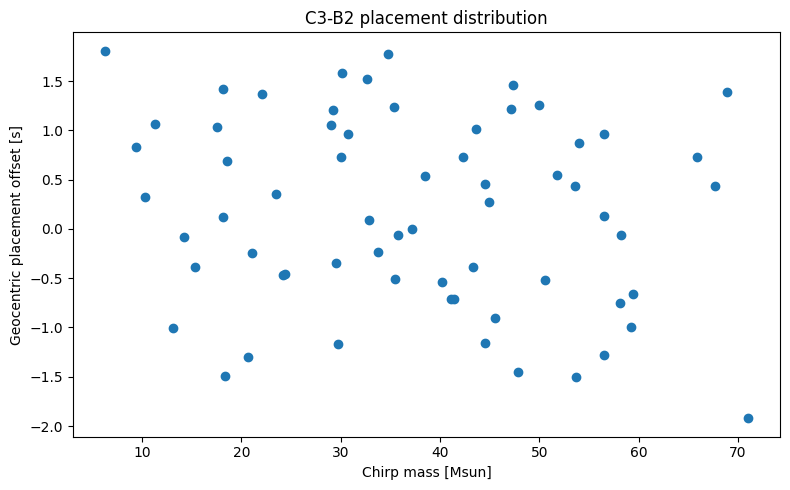

In [359]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.scatter(
    df_c3_b2_diagnostics_M116[
        "chirp_mass"
    ],
    df_c3_b2_diagnostics_M116[
        "placement_offset_s"
    ],
)

ax.set_xlabel(
    "Chirp mass [Msun]"
)

ax.set_ylabel(
    "Geocentric placement offset [s]"
)

ax.set_title(
    "C3-B2 placement distribution"
)

plt.tight_layout()
plt.show()

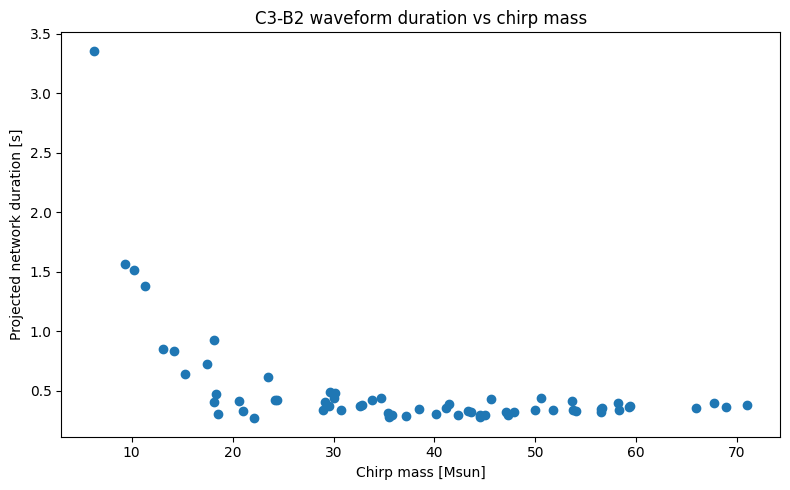

In [360]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.scatter(
    df_c3_b2_diagnostics_M116[
        "chirp_mass"
    ],
    df_c3_b2_diagnostics_M116[
        "full_network_duration"
    ],
)

ax.set_xlabel(
    "Chirp mass [Msun]"
)

ax.set_ylabel(
    "Projected network duration [s]"
)

ax.set_title(
    "C3-B2 waveform duration vs chirp mass"
)

plt.tight_layout()
plt.show()

In [361]:
assert (
    len(
        c3_b2_results_M116
    )
    ==
    M116_C3_N_SOURCES
)

assert (
    len(
        c3_b2_failures_M116
    )
    ==
    0
)

assert (
    all_contracts_pass_c3_b2_M116
)

In [362]:
print(
    "=" * 72
)

print(
    "M11.6-C3-B2 PASS"
)

print(
    "=" * 72
)

print(
    "64-source paired G0/G1/R validation completed."
)

print(
    "Successful sources:",
    len(
        c3_b2_results_M116
    )
)

print(
    "Failures:",
    len(
        c3_b2_failures_M116
    )
)

print(
    "Unique file groups:",
    df_c3_b2_diagnostics_M116[
        "file_group_id"
    ].nunique(),
)

print(
    "Unique blocks:",
    df_c3_b2_diagnostics_M116[
        "block_id"
    ].nunique(),
)

M11.6-C3-B2 PASS
64-source paired G0/G1/R validation completed.
Successful sources: 64
Failures: 0
Unique file groups: 19
Unique blocks: 48
